In [41]:
# Install Dependencies
!pip install -q earthengine-api xee xarray matplotlib seaborn pandas geopandas pymannkendall

# Import Libraries
import ee
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
import geopandas as gpd
import xee

# Authenticate and Initialize Earth Engine
ee.Authenticate()

PROJECT_ID = "ee-satyamshah444"
ee.Initialize(
    project=PROJECT_ID,
    opt_url="https://earthengine-highvolume.googleapis.com",
)

print("Earth Engine initialized successfully")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Earth Engine initialized successfully


In [42]:
# Load the Bellandur Lake shapefile
SHAPEFILE_PATH = "/Users/satyamshah/Downloads/Paper13/Lake.shp"

gdf = gpd.read_file(SHAPEFILE_PATH)
gdf = gdf.to_crs("EPSG:4326")

print(f"Shapefile CRS: {gdf.crs}")
print(f"Number of features: {len(gdf)}")
print(f"Geometry type: {gdf.geometry.iloc[0].geom_type}")
print(f"Bounds: {gdf.total_bounds}")

# Get the geometry (single feature)
geom = gdf.geometry.iloc[0]

# Extract coordinates - handle 3D coordinates by taking only x, y
if geom.geom_type == 'Polygon':
    coords = [[float(coord[0]), float(coord[1])] for coord in geom.exterior.coords]
    STUDY_AREA = ee.Geometry.Polygon([coords])
elif geom.geom_type == 'MultiPolygon':
    all_coords = []
    for poly in geom.geoms:
        coords = [[float(coord[0]), float(coord[1])] for coord in poly.exterior.coords]
        all_coords.append([coords])
    STUDY_AREA = ee.Geometry.MultiPolygon(all_coords)

# Define Study Parameters
START_DATE = "2023-01-01"
END_DATE = "2025-12-31"
CLOUD_THRESHOLD = 15

study_area_km2 = STUDY_AREA.area(maxError=100).getInfo() / 1e6

print("Study area set")
print(f"Area: {study_area_km2:.2f} km2")
print(f"Study period: {START_DATE} to {END_DATE} (3 years)")

Shapefile CRS: EPSG:4326
Number of features: 1
Geometry type: Polygon
Bounds: [77.66671384 12.93110743 77.67839018 12.94145972]
Study area set
Area: 1.04 km2
Study period: 2023-01-01 to 2025-12-31 (3 years)


In [43]:
# Cloud Masking Function
def mask_clouds_s2(image):
    """Remove clouds using cloud probability + SCL band."""
    cloud_prob = image.select("probability")
    scl = image.select("SCL")

    is_clear = cloud_prob.lt(CLOUD_THRESHOLD)
    scl_mask = (
        scl.neq(3)
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
    )

    return image.updateMask(is_clear).updateMask(scl_mask)


# Water Quality Algorithms
def compute_water_quality(image):
    """
    Compute water quality from Sentinel-2.
    Bands: Chlorophyll_a, Chlorophyll_a_NDCI, NDCI,
           Turbidity_FNU, TSS, CDOM, Secchi_Depth, FAI
    """
    refl = image.select("B.*").multiply(0.0001)

    b1 = refl.select("B1")
    b2 = refl.select("B2")
    b3 = refl.select("B3")
    b4 = refl.select("B4")
    b5 = refl.select("B5")
    b8 = refl.select("B8")
    b11 = refl.select("B11")

    # Chlorophyll-a (Red Edge ratio)
    chla_ratio = b5.divide(b4).multiply(86.115).add(14.039).rename("Chlorophyll_a")

    # NDCI - Normalized Difference Chlorophyll Index
    ndci = b5.subtract(b4).divide(b5.add(b4)).rename("NDCI")

    # Chl-a from NDCI (Mishra and Mishra 2012)
    chla_ndci = (
        ndci.pow(2).multiply(194.325)
        .add(ndci.multiply(86.115))
        .add(14.039)
        .rename("Chlorophyll_a_NDCI")
    )

    # Turbidity (FNU) - Dogliotti et al. (2015)
    turbidity = (
        b4.multiply(228.1)
        .divide(ee.Image(1).subtract(b4.divide(0.1641)))
        .rename("Turbidity_FNU")
    )

    # Total Suspended Solids (TSS)
    tss = b4.multiply(3957.0).add(13.0).rename("TSS")

    # CDOM - Brezonik et al. (2015)
    cdom = b2.divide(b3).multiply(-2.93).exp().multiply(537.0).rename("CDOM")

    # Secchi Disk Depth (m)
    secchi = b2.divide(b3).log().multiply(-1.22).add(1.65).rename("Secchi_Depth")

    # Floating Algae Index (FAI) - Hu (2009)
    fai_baseline = b4.add(
        b11.subtract(b4).multiply((842.0 - 665.0) / (1610.0 - 665.0))
    )
    fai = b8.subtract(fai_baseline).rename("FAI")

    # Combine, clamp negatives, restore time
    result = ee.Image.cat([
        chla_ratio, chla_ndci, ndci, turbidity, tss, cdom, secchi, fai,
    ])
    result = result.max(0)
    result = result.set("system:time_start", image.get("system:time_start"))

    return result

print("Cloud masking and water quality functions defined")

Cloud masking and water quality functions defined


In [44]:
# Update cloud threshold
CLOUD_THRESHOLD = 40

print("Rebuilding Sentinel-2 collection with relaxed cloud threshold...")
print(f"Cloud probability threshold: {CLOUD_THRESHOLD}")
print(f"Date range: {START_DATE} to {END_DATE}")

s2_raw = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .linkCollection(
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"),
        ["probability"],
    )
    .filterDate(START_DATE, END_DATE)
    .filterBounds(STUDY_AREA)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 50))
)

water_quality_collection = (
    s2_raw
    .map(mask_clouds_s2)
    .map(compute_water_quality)
    .map(lambda img: img.clip(STUDY_AREA).copyProperties(img, ["system:time_start"]))
)

n_images = water_quality_collection.size().getInfo()
print(f"Total images available after filtering: {n_images}")

Rebuilding Sentinel-2 collection with relaxed cloud threshold...
Cloud probability threshold: 40
Date range: 2023-01-01 to 2025-12-31
Total images available after filtering: 100


In [45]:
# Convert to XArray Dataset
print("Converting to XArray dataset...")

ds = xr.open_dataset(
    water_quality_collection,
    engine="ee",
    crs="EPSG:4326",
    scale=0.0001,
    geometry=STUDY_AREA,
)

ds = ds.sortby("time") * 1
print(f"Dataset loaded with {len(ds.time)} timesteps")

# Monthly Aggregation
ds["time"] = pd.to_datetime(ds["time"].values)
monthly = ds.resample(time="ME").median("time")

ts_mean = ds.mean(dim=["lon", "lat"], skipna=True)
ts_df = ts_mean.to_dataframe().reset_index()
ts_df["time"] = pd.to_datetime(ts_df["time"])
ts_df = ts_df.sort_values("time")

print(f"Monthly aggregation complete")
print(f"Number of months: {len(monthly.time)}")

Converting to XArray dataset...
Dataset loaded with 100 timesteps
Monthly aggregation complete
Number of months: 36


Displaying 28 months with valid data
Chl-a color range: 112.3 - 371.0 ug/L


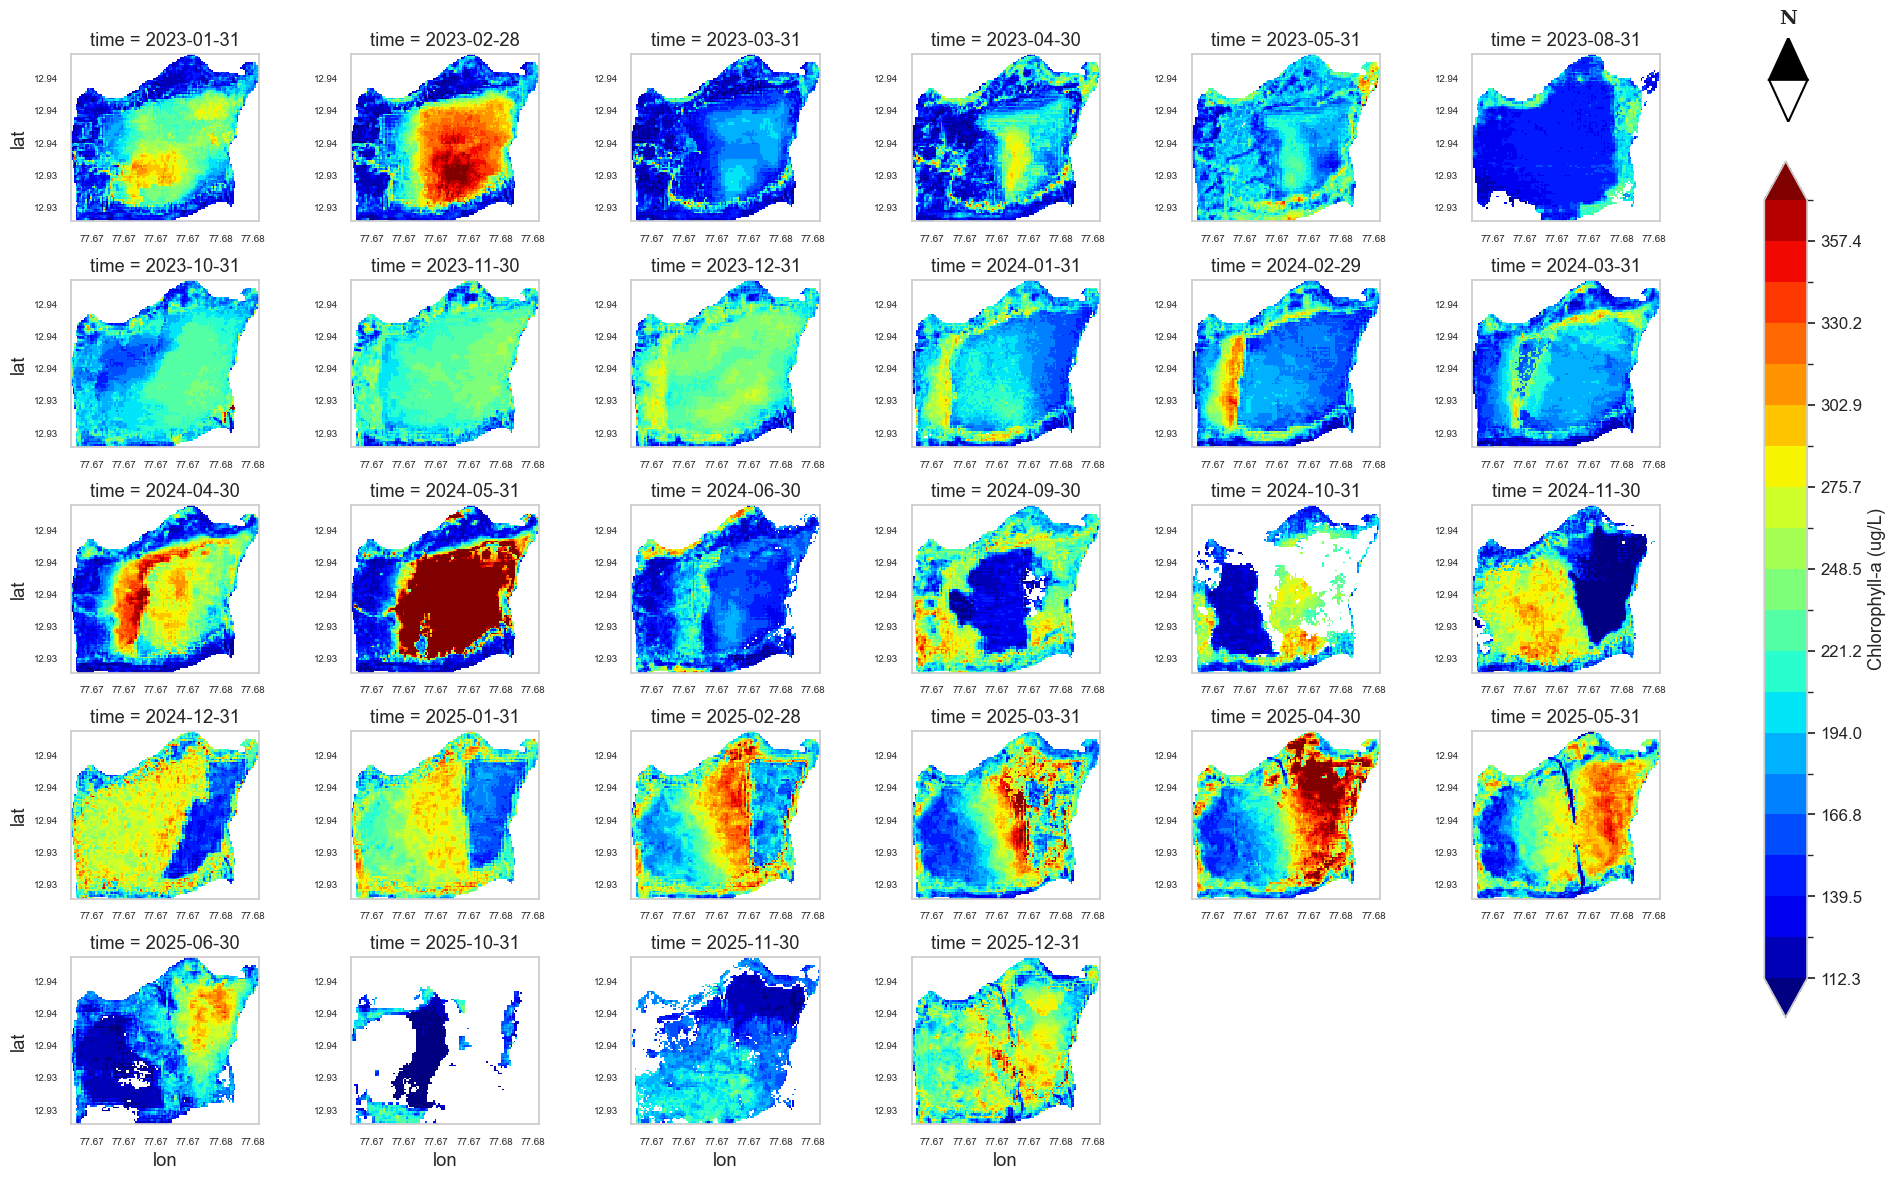

In [105]:
# Monthly Chlorophyll-a Maps --- TRIAL VERSION WITH LAT/LON ON EACH PANEL + NORTH ARROW ---
sns.set_theme(style="whitegrid", font_scale=1.1)

from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from matplotlib.patches import FancyArrowPatch, Circle, Polygon
import matplotlib.patches as mpatches

# Filter months with valid data (coverage > 0)
valid_times = []
for t in range(len(monthly.time)):
    data_slice = monthly.Chlorophyll_a.isel(time=t).values
    valid_pixels = np.count_nonzero(~np.isnan(data_slice))
    if valid_pixels > 0:
        valid_times.append(monthly.time.values[t])

print(f"Displaying {len(valid_times)} months with valid data")

monthly_filtered = monthly.sel(time=valid_times)

data = monthly_filtered.Chlorophyll_a.values
vmin = float(np.nanpercentile(data, 2))
vmax = float(np.nanpercentile(data, 98))
print(f"Chl-a color range: {vmin:.1f} - {vmax:.1f} ug/L")

fig = monthly_filtered.Chlorophyll_a.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=vmin, vmax=vmax,
    cmap="jet",
    levels=20,
    figsize=(22, 12),
    cbar_kwargs={"label": "Chlorophyll-a (ug/L)", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("01_monthly_chlorophyll_maps.png", dpi=600, bbox_inches="tight")
plt.show()

Turbidity color range: 2.2 - 141.6 FNU


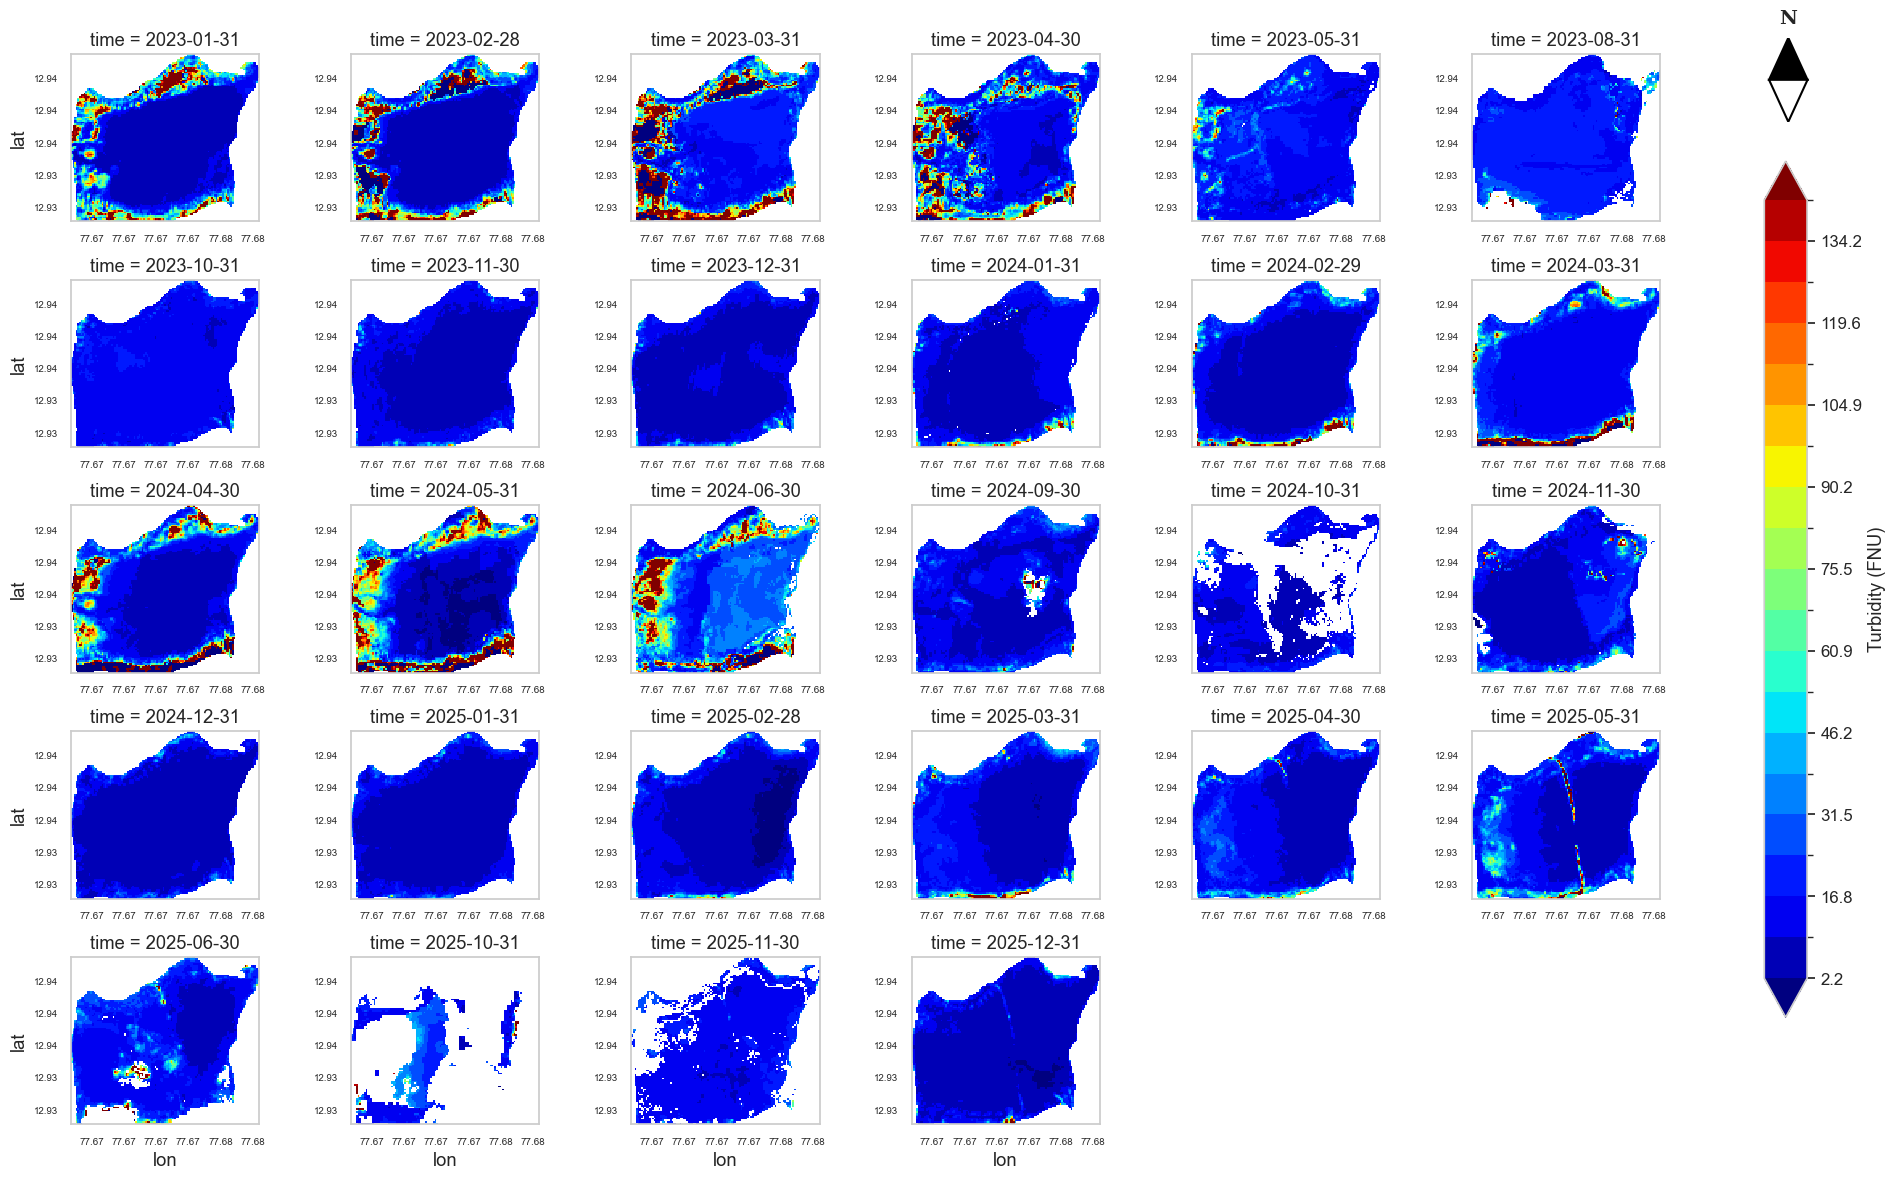

In [106]:
# Monthly Turbidity Maps
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from matplotlib.patches import FancyArrowPatch, Circle, Polygon
import matplotlib.patches as mpatches

data = monthly_filtered.Turbidity_FNU.values
vmin = float(np.nanpercentile(data, 2))
vmax = float(np.nanpercentile(data, 98))
print(f"Turbidity color range: {vmin:.1f} - {vmax:.1f} FNU")

fig = monthly_filtered.Turbidity_FNU.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=vmin, vmax=vmax,
    cmap="jet",
    levels=20,
    figsize=(22, 12),
    cbar_kwargs={"label": "Turbidity (FNU)", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("02_monthly_turbidity_maps.png", dpi=600, bbox_inches="tight")
plt.show()

TSS color range: 60.5 - 588.3 mg/L


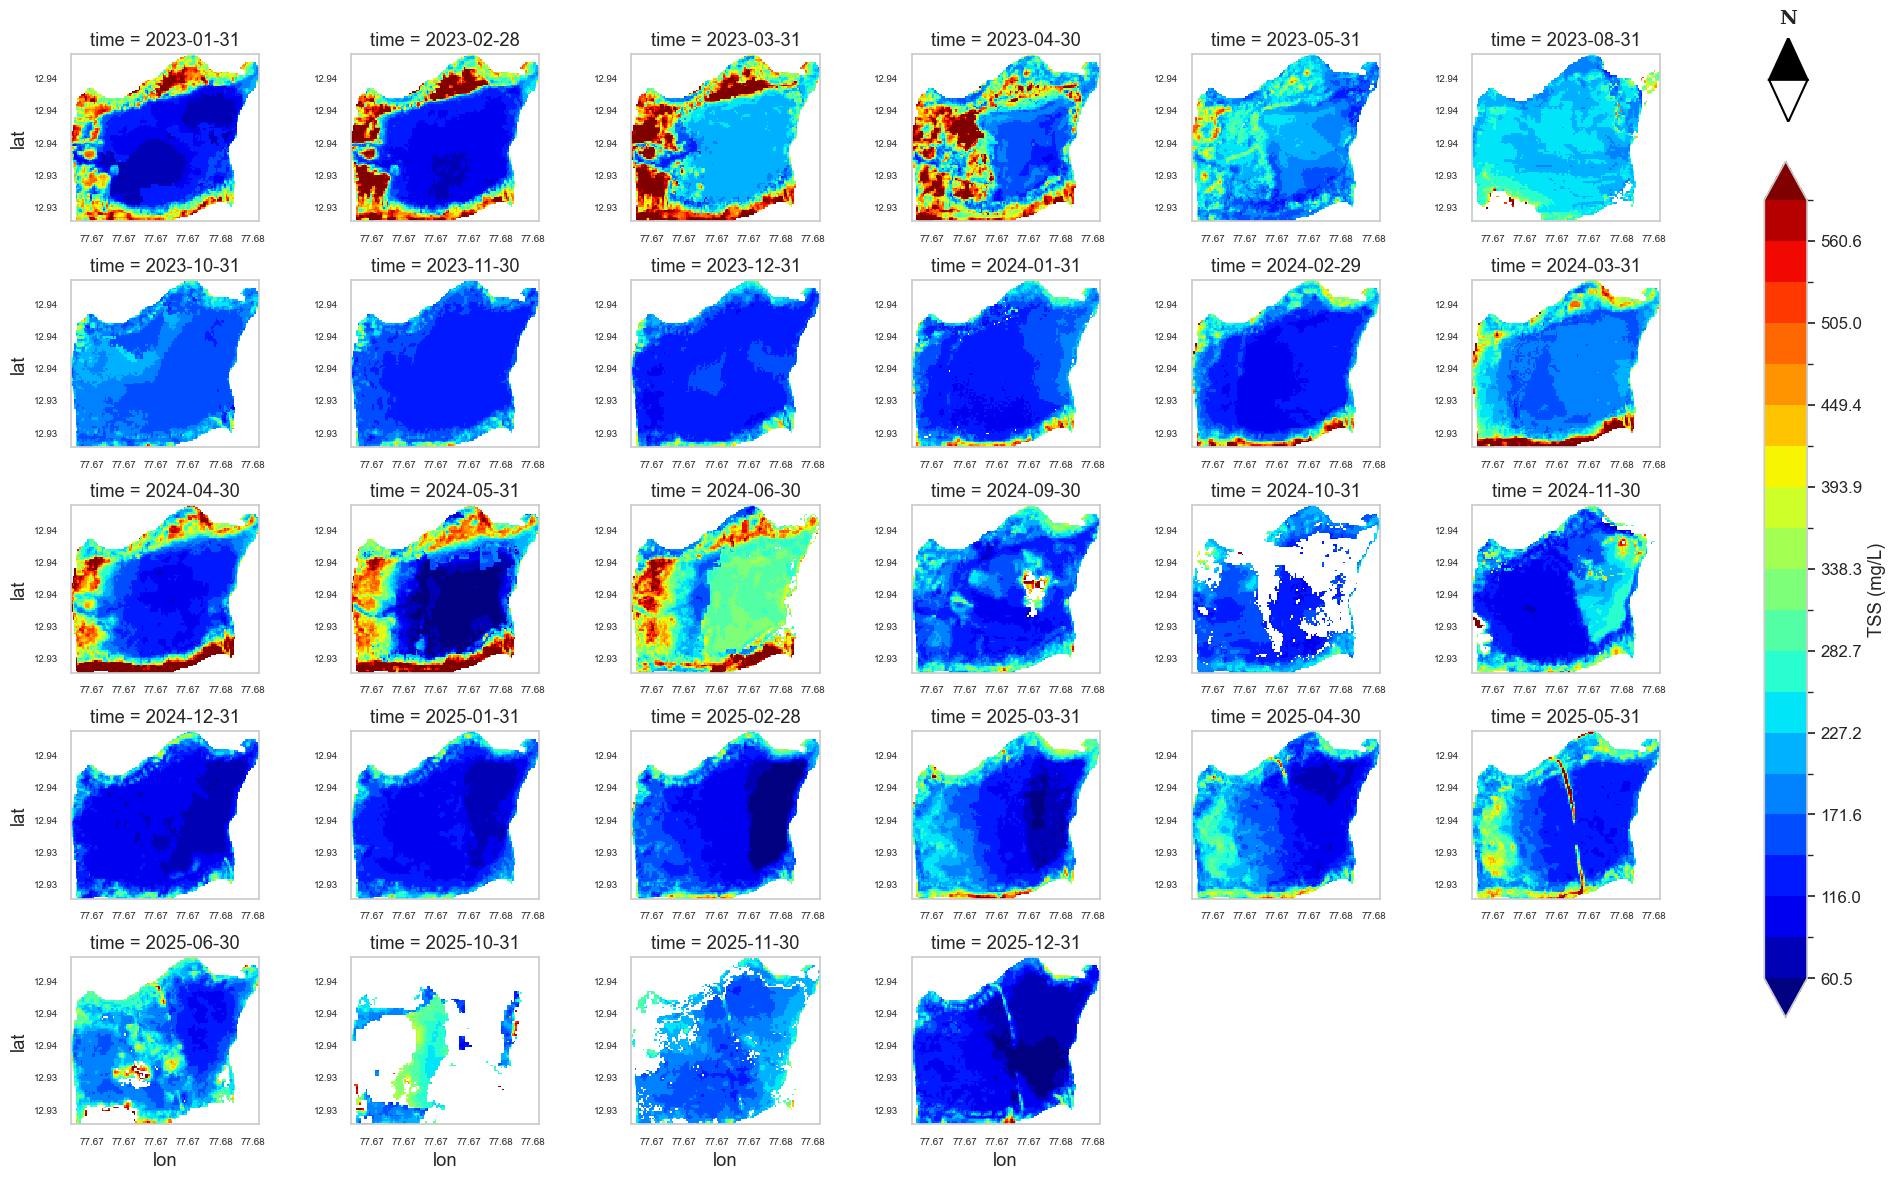

In [107]:
# Monthly TSS Maps
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from matplotlib.patches import FancyArrowPatch, Circle, Polygon
import matplotlib.patches as mpatches

data = monthly_filtered.TSS.values
vmin = float(np.nanpercentile(data, 2))
vmax = float(np.nanpercentile(data, 98))
print(f"TSS color range: {vmin:.1f} - {vmax:.1f} mg/L")

fig = monthly_filtered.TSS.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=vmin, vmax=vmax,
    cmap="jet",
    levels=20,
    figsize=(22, 12),
    cbar_kwargs={"label": "TSS (mg/L)", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("03_monthly_tss_maps.png", dpi=600, bbox_inches="tight")
plt.show()

CDOM color range: 25.9 - 302.6


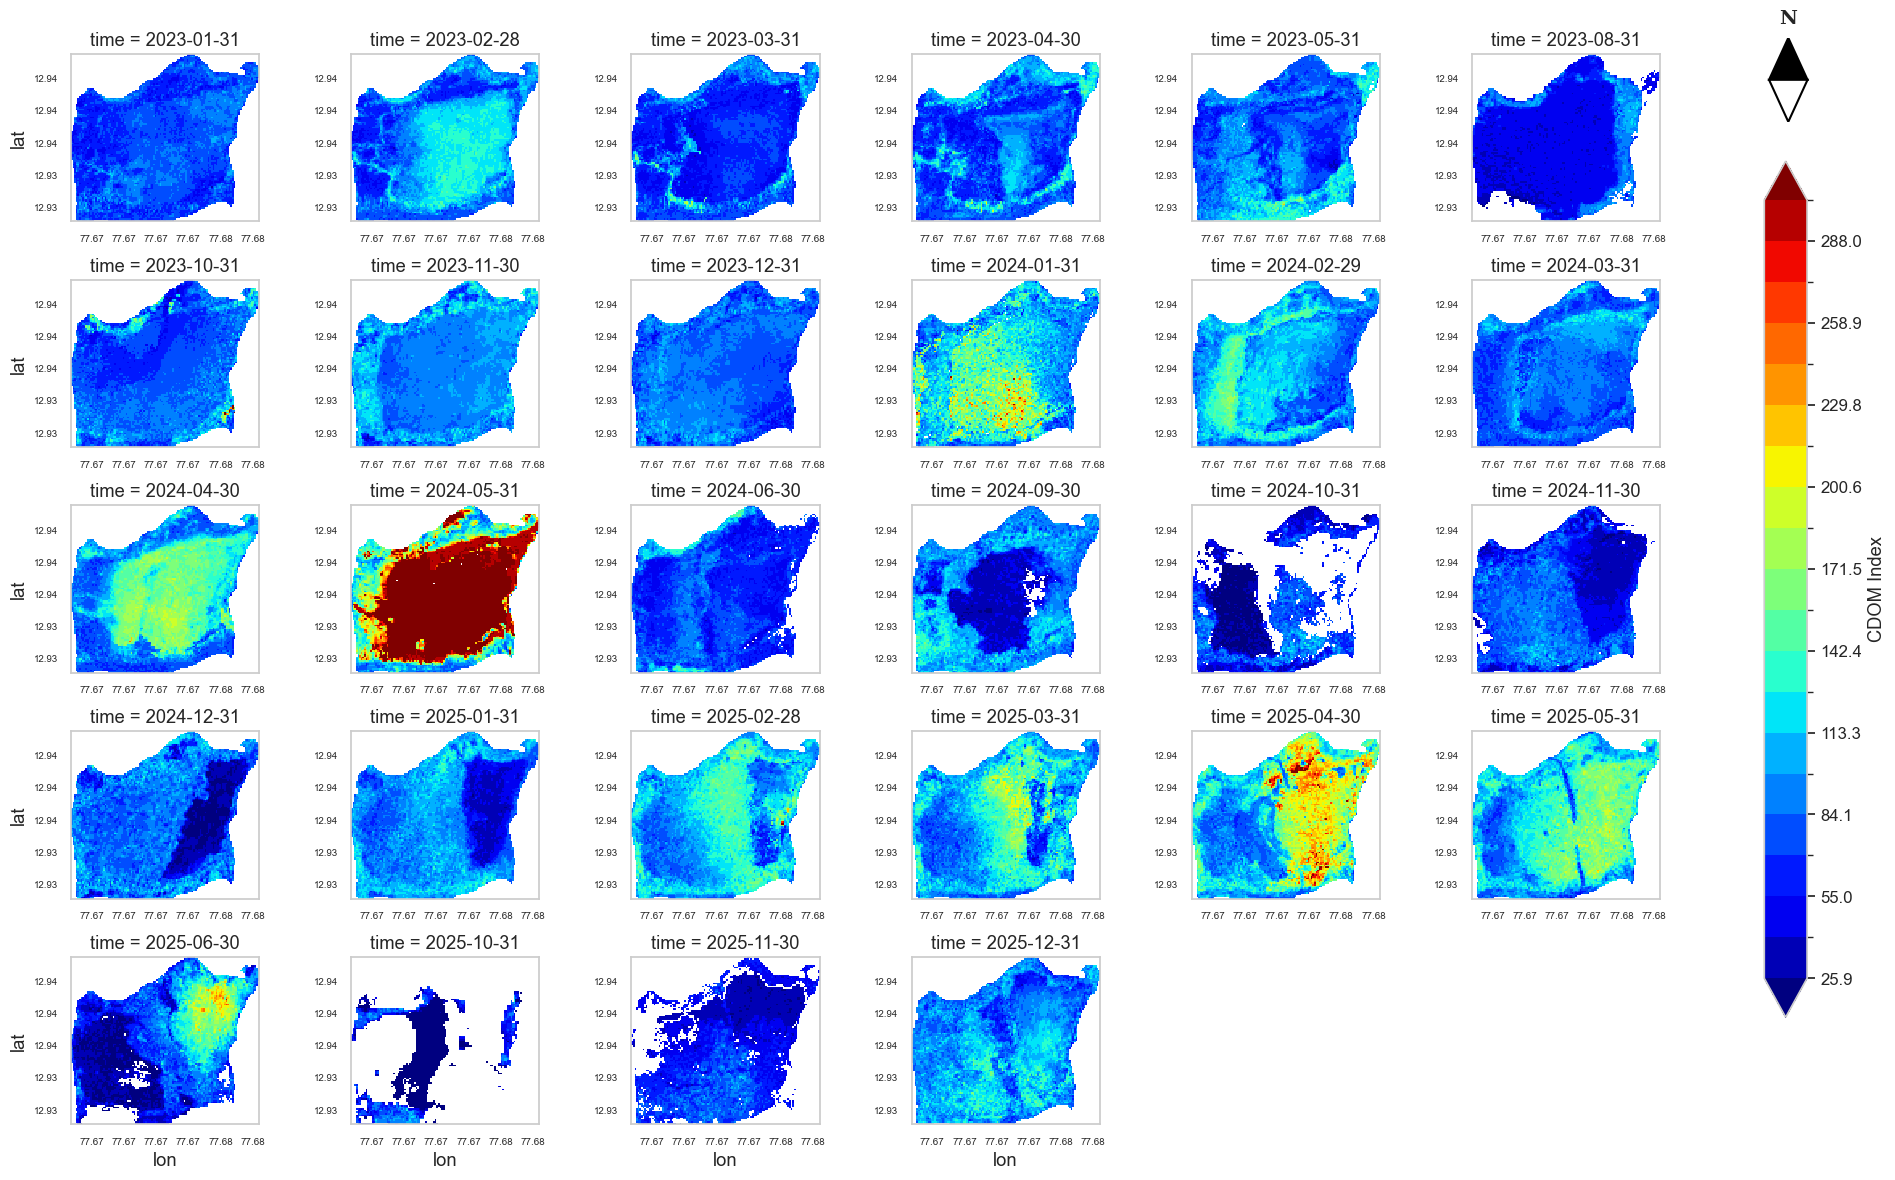

Secchi Depth color range: 1.6 - 2.9 m


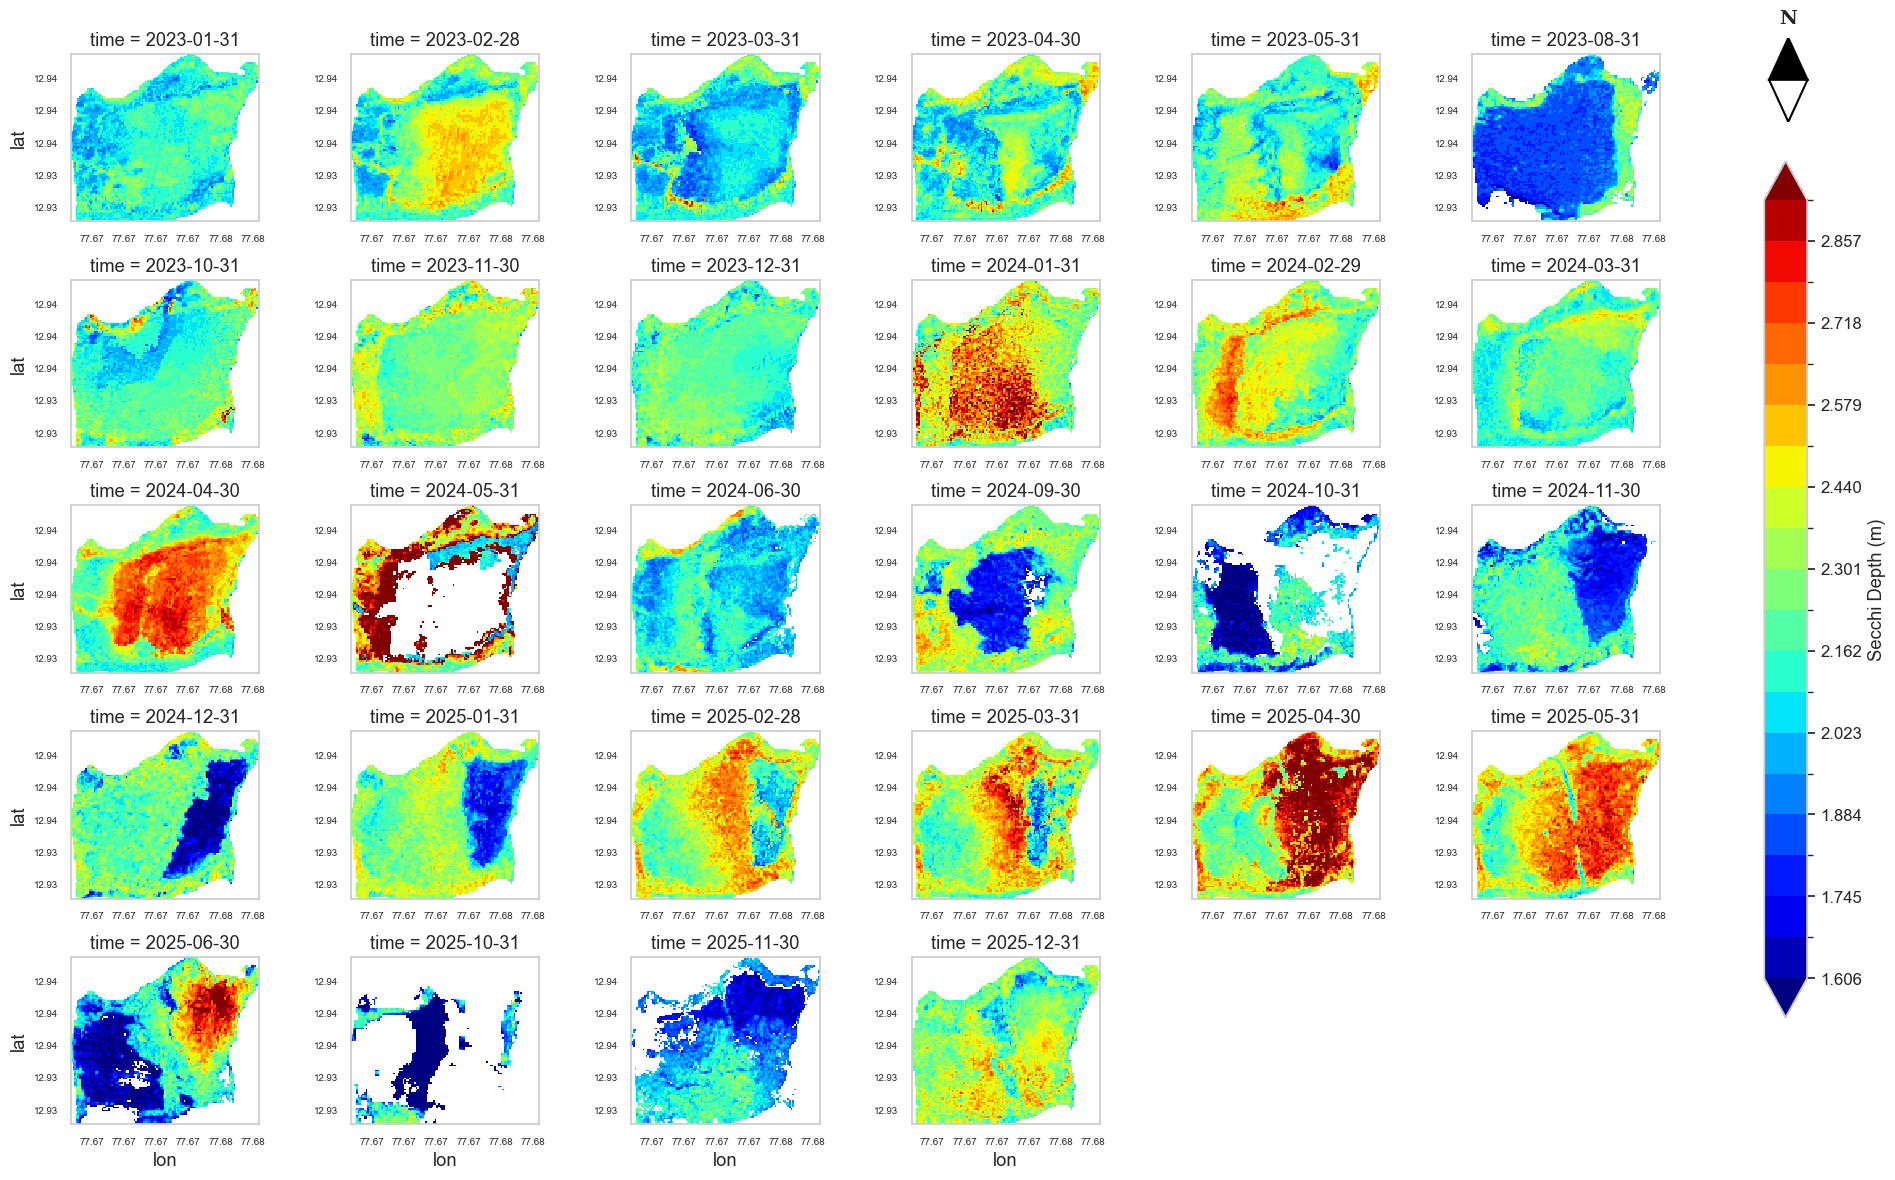

In [108]:
# Monthly CDOM Maps
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from matplotlib.patches import FancyArrowPatch, Circle, Polygon
import matplotlib.patches as mpatches

data = monthly_filtered.CDOM.values
vmin = float(np.nanpercentile(data, 2))
vmax = float(np.nanpercentile(data, 98))
print(f"CDOM color range: {vmin:.1f} - {vmax:.1f}")

fig = monthly_filtered.CDOM.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=vmin, vmax=vmax,
    cmap="jet",
    levels=20,
    figsize=(22, 12),
    cbar_kwargs={"label": "CDOM Index", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("04_monthly_cdom_maps.png", dpi=600, bbox_inches="tight")
plt.show()

# Monthly Secchi Depth Maps
data = monthly_filtered.Secchi_Depth.values
vmin = float(np.nanpercentile(data, 2))
vmax = float(np.nanpercentile(data, 98))
print(f"Secchi Depth color range: {vmin:.1f} - {vmax:.1f} m")

fig = monthly_filtered.Secchi_Depth.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=vmin, vmax=vmax,
    cmap="jet",
    levels=20,
    figsize=(22, 12),
    cbar_kwargs={"label": "Secchi Depth (m)", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("05_monthly_secchi_maps.png", dpi=600, bbox_inches="tight")
plt.show()

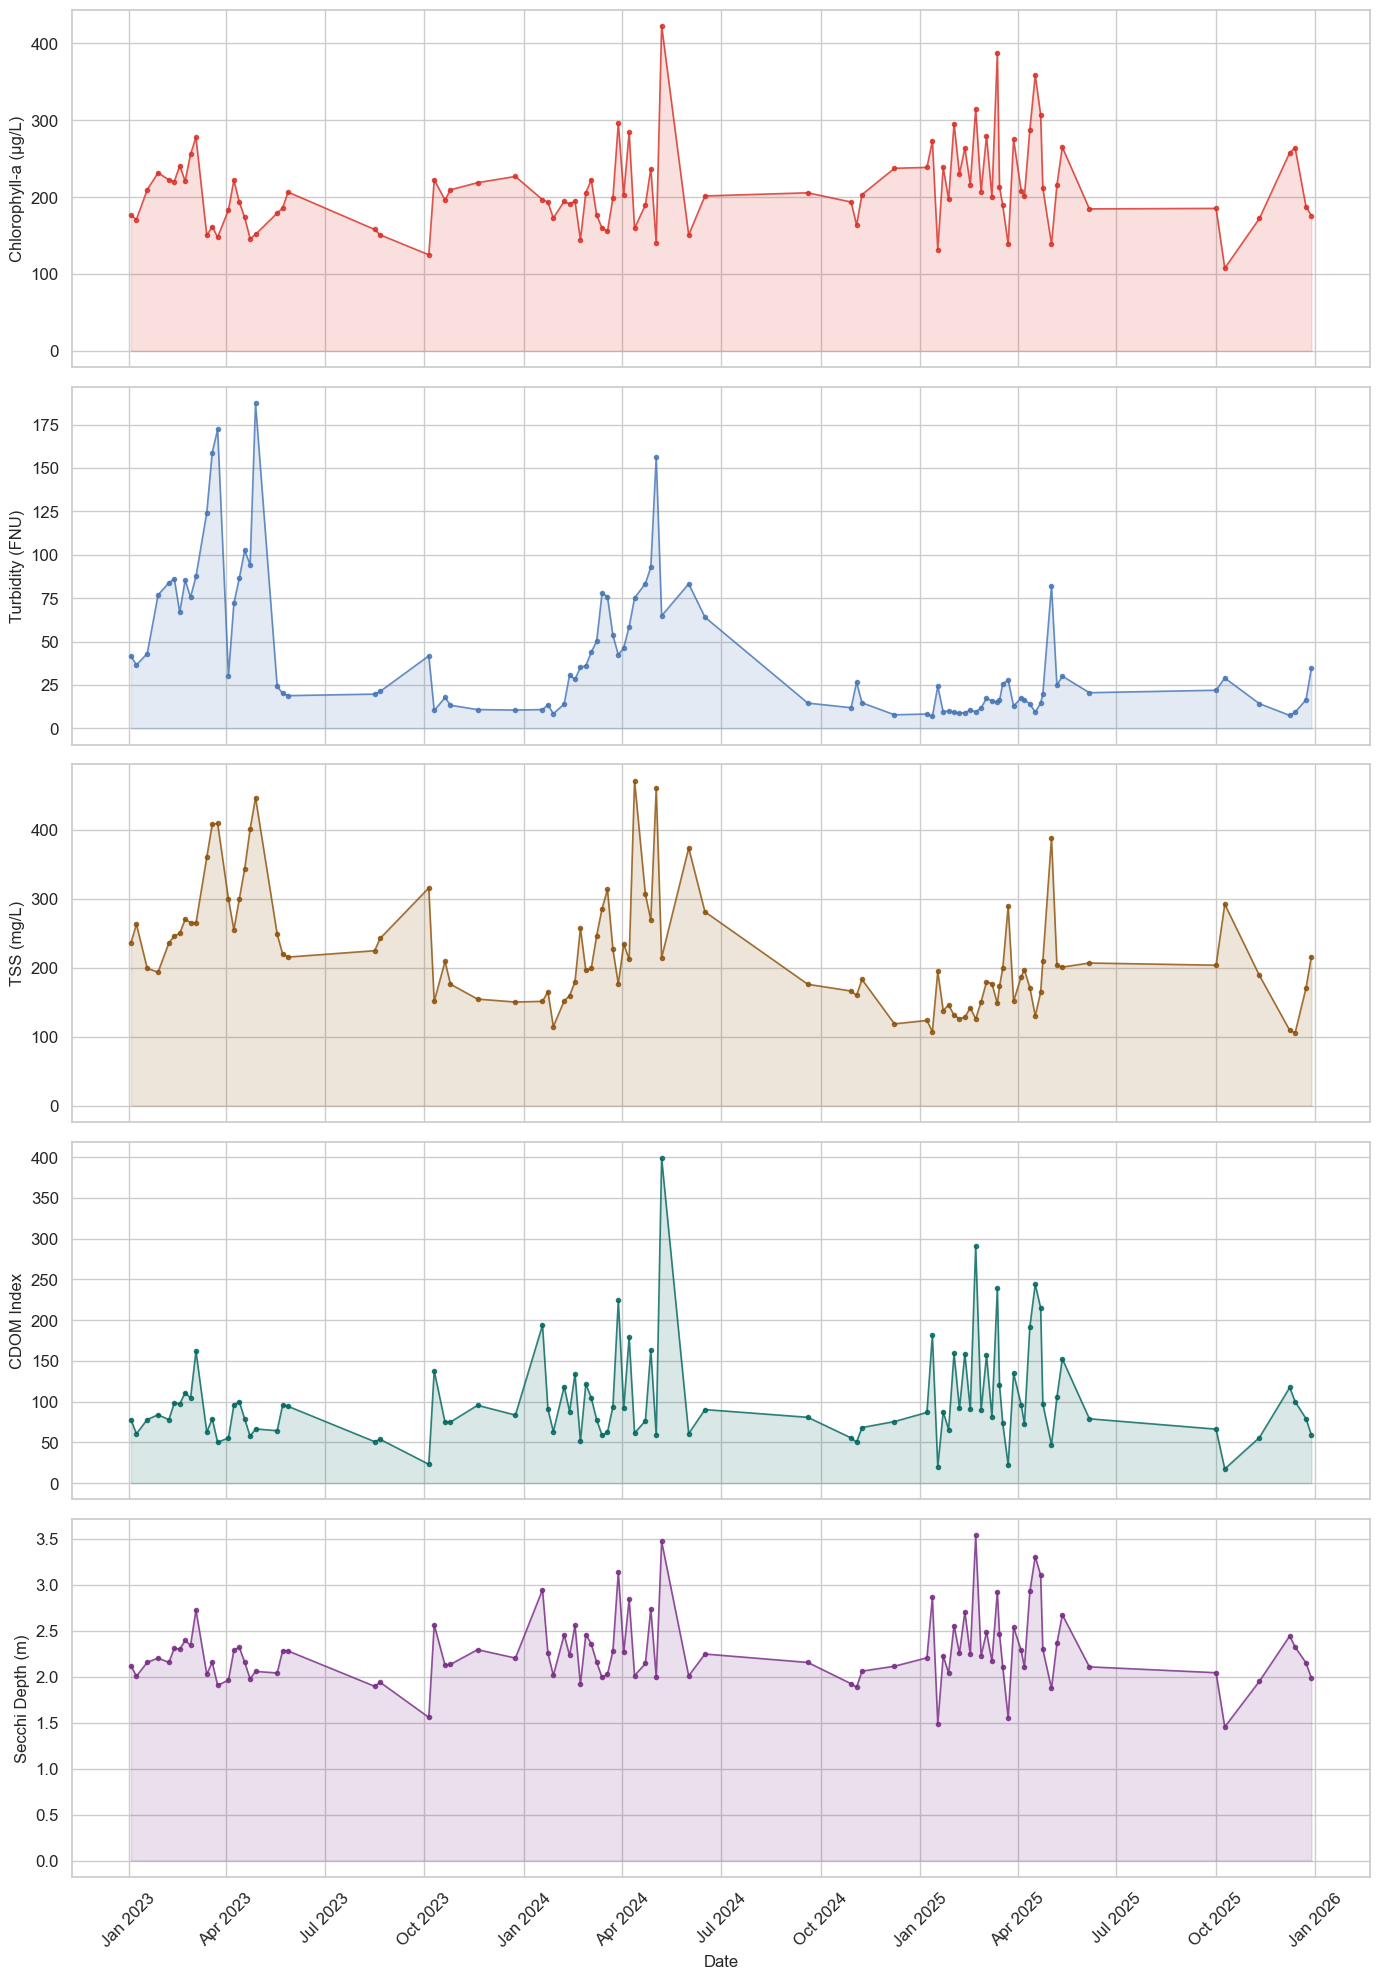

In [50]:
# Multi-Parameter Time Series
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

params = [
    ("Chlorophyll_a", "Chlorophyll-a (µg/L)", "#d73027"),
    ("Turbidity_FNU", "Turbidity (FNU)", "#4575b4"),
    ("TSS", "TSS (mg/L)", "#8c510a"),
    ("CDOM", "CDOM Index", "#01665e"),
    ("Secchi_Depth", "Secchi Depth (m)", "#762a83"),
]

for ax, (band, label, color) in zip(axes, params):
    subset = ts_df[["time", band]].dropna()
    if not subset.empty:
        ax.plot(subset["time"], subset[band], "o-", color=color,
                markersize=3, linewidth=1.2, alpha=0.8)
        ax.fill_between(subset["time"], subset[band], alpha=0.15, color=color)
    ax.set_ylabel(label, fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis="x", rotation=45)


axes[-1].set_xlabel("Date", fontsize=12)
plt.tight_layout()
plt.savefig("06_timeseries_multiparameter.png", dpi=600, bbox_inches="tight")
plt.show()

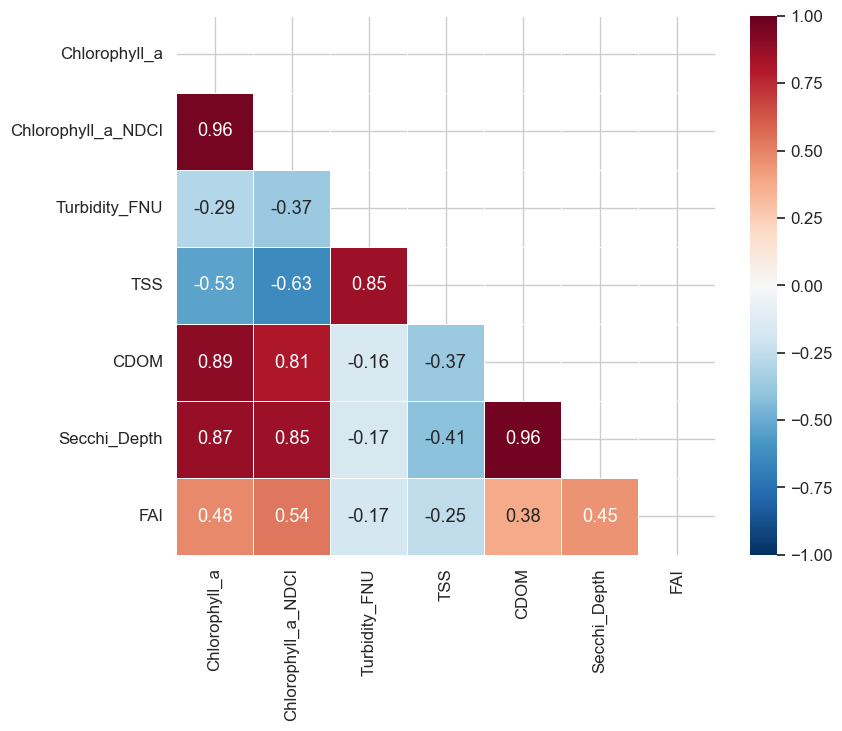

In [51]:
# Correlation Heatmap
corr_cols = ["Chlorophyll_a", "Chlorophyll_a_NDCI", "Turbidity_FNU",
             "TSS", "CDOM", "Secchi_Depth", "FAI"]
corr_data = ts_df[corr_cols].dropna()

if not corr_data.empty and len(corr_data) > 2:
    fig, ax = plt.subplots(figsize=(9, 7))
    corr_matrix = corr_data.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt=".2f",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax,
    )
    
    plt.savefig("07_correlation_heatmap.png", dpi=600, bbox_inches="tight")
    plt.show()
else:
    print("Not enough data points for correlation heatmap.")

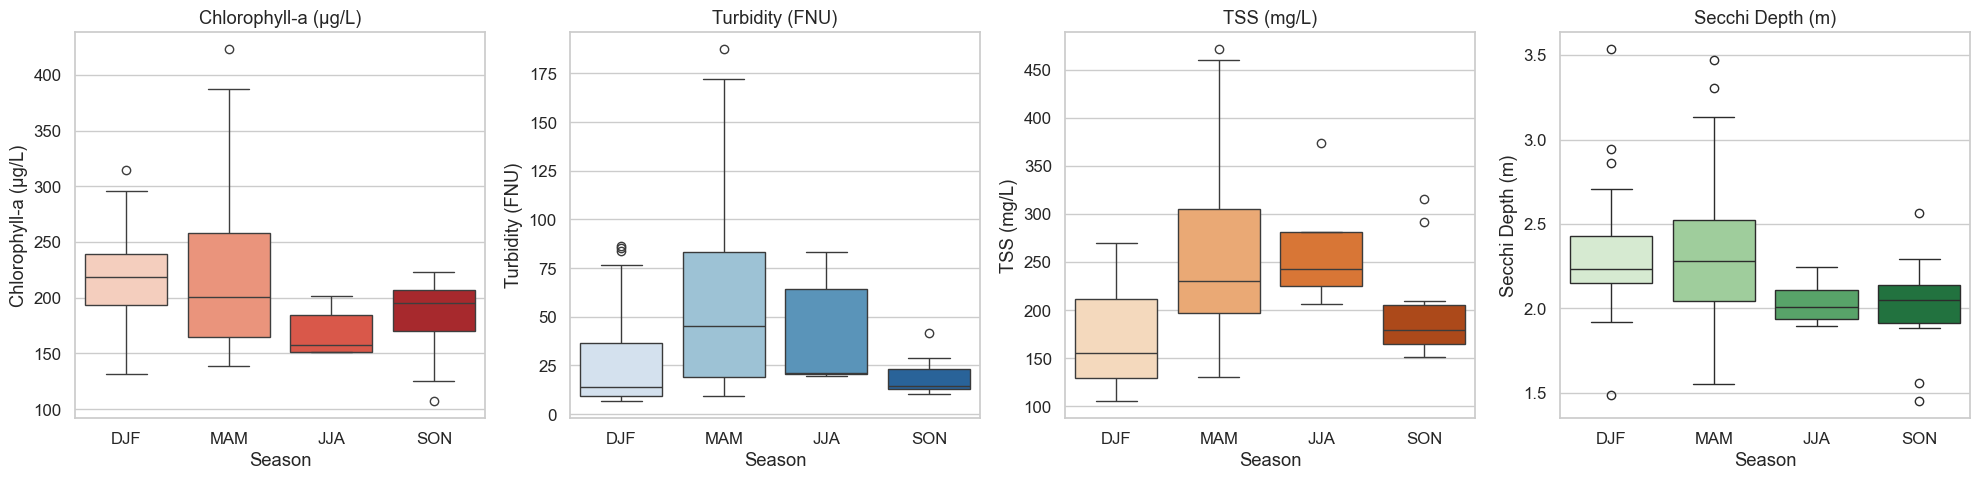

In [52]:
# Seasonal Box Plots
ts_df["month"] = ts_df["time"].dt.month
ts_df["season"] = ts_df["month"].map({
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
})

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
season_order = ["DJF", "MAM", "JJA", "SON"]

for ax, (band, label, pal) in zip(axes, [
    ("Chlorophyll_a", "Chlorophyll-a (µg/L)", "Reds"),
    ("Turbidity_FNU", "Turbidity (FNU)", "Blues"),
    ("TSS", "TSS (mg/L)", "Oranges"),
    ("Secchi_Depth", "Secchi Depth (m)", "Greens"),
]):
    plot_data = ts_df[["season", band]].dropna()
    if not plot_data.empty:
        sns.boxplot(data=plot_data, x="season", y=band,
                    order=season_order, palette=pal, ax=ax)
    ax.set_ylabel(label)
    ax.set_xlabel("Season")
    ax.set_title(label)


plt.tight_layout()
plt.savefig("08_seasonal_boxplots.png", dpi=600, bbox_inches="tight")
plt.show()

In [53]:
# Export Statistics
corr_cols = ["Chlorophyll_a", "Chlorophyll_a_NDCI", "Turbidity_FNU",
             "TSS", "CDOM", "Secchi_Depth", "FAI"]

stats = ts_df[corr_cols].describe().round(2)
stats.to_csv("09_water_quality_statistics.csv")
print("Summary Statistics:")
print(stats)

monthly_df = ts_df.groupby(ts_df["time"].dt.to_period("M"))[corr_cols].median()
monthly_df.to_csv("10_monthly_median_values.csv")
print("\nMonthly medians exported to CSV.")

Summary Statistics:
       Chlorophyll_a  Chlorophyll_a_NDCI  Turbidity_FNU     TSS    CDOM  \
count          93.00               93.00          93.00   93.00   93.00   
mean          210.28               71.31          41.67  221.30  101.02   
std            55.10               21.78          39.48   83.76   59.71   
min           107.57               18.23           6.91  105.84   17.52   
25%           176.07               57.34          14.00  160.02   64.44   
50%           201.56               70.24          24.86  200.92   86.86   
75%           231.71               84.70          64.87  263.04  111.08   
max           422.69              119.37         187.32  470.95  398.97   

       Secchi_Depth    FAI  
count         93.00  93.00  
mean           2.27   0.16  
std            0.38   0.07  
min            1.45   0.01  
25%            2.04   0.11  
50%            2.20   0.18  
75%            2.39   0.22  
max            3.53   0.28  

Monthly medians exported to CSV.


Chl-a anomaly range: -48.6 to 43.7 µg/L


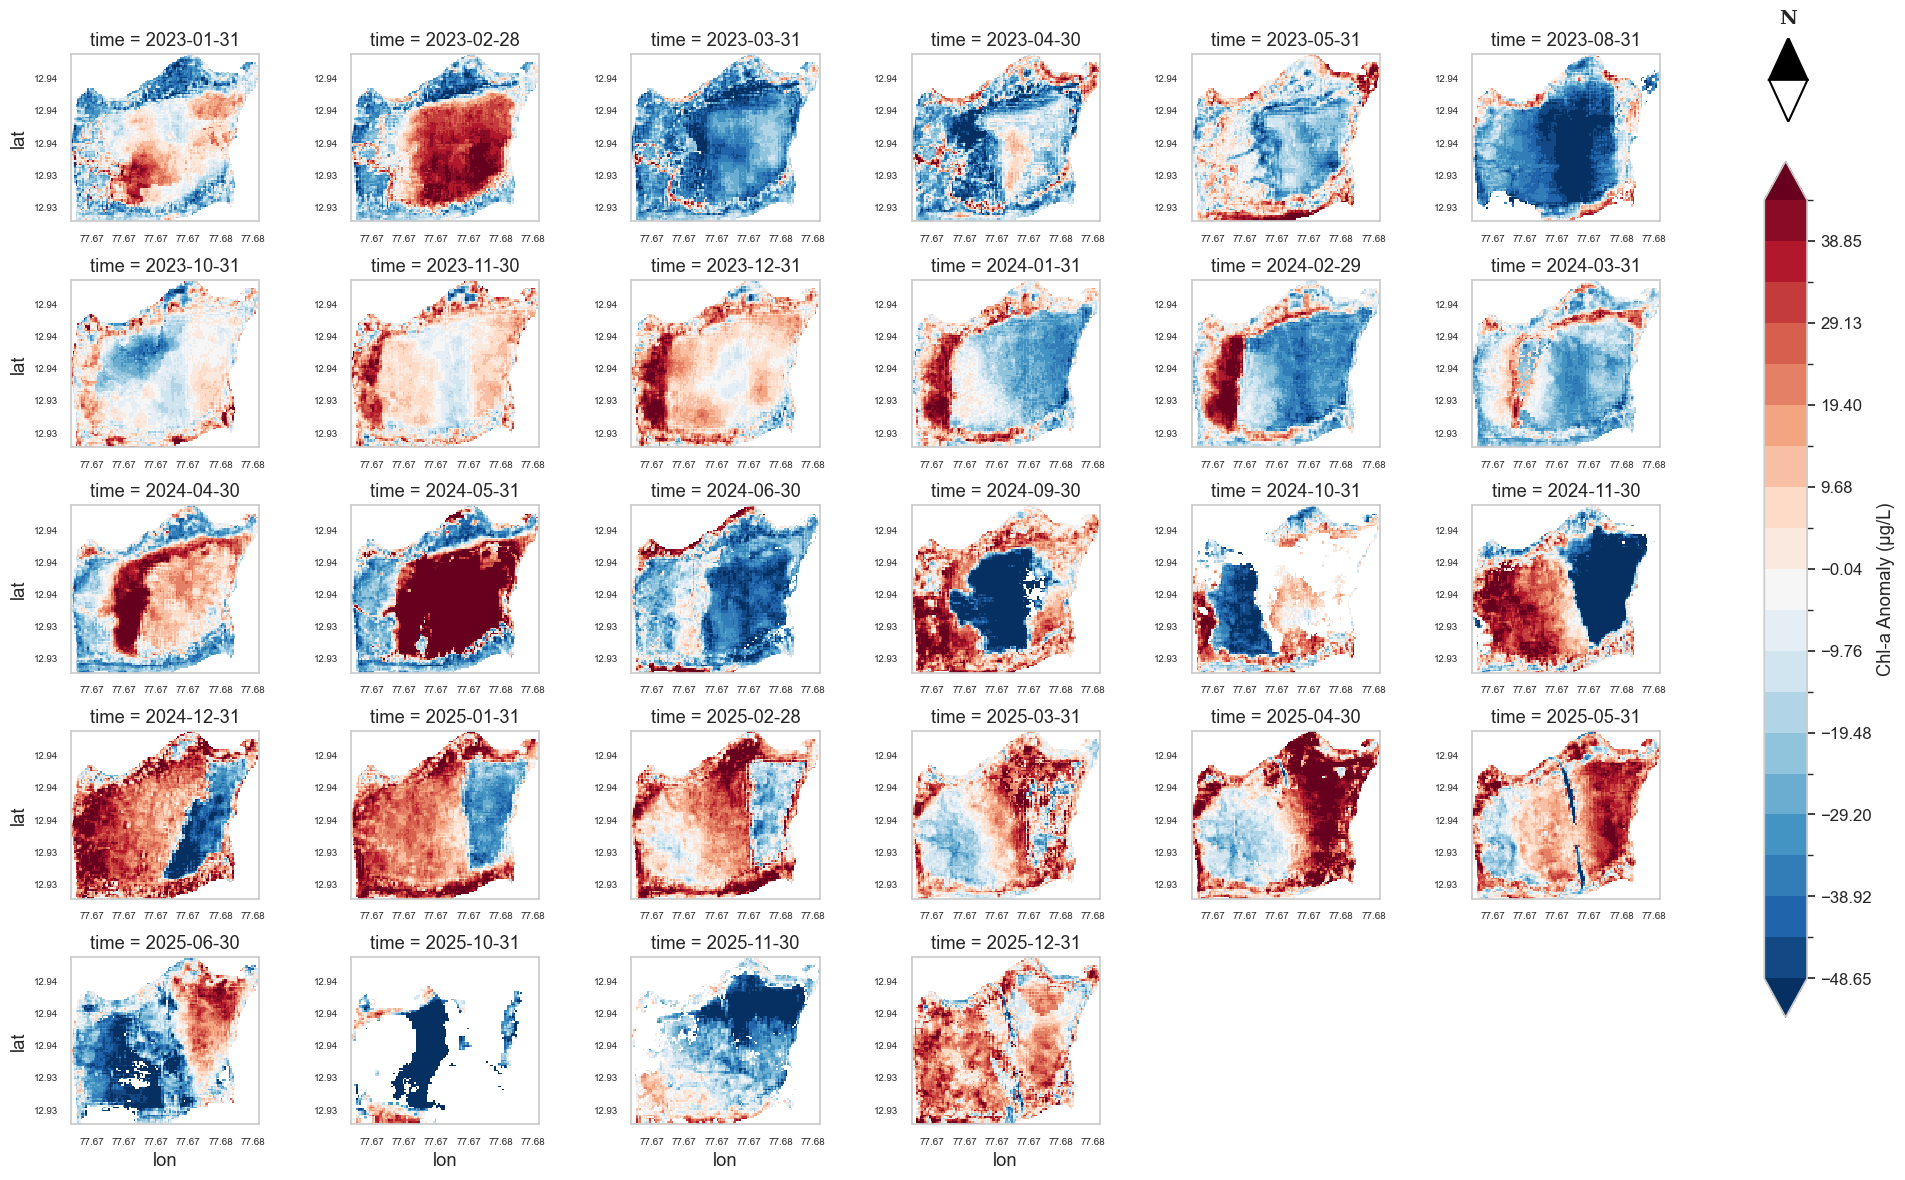

In [109]:
# Anomaly Detection - Which months deviate from the long-term average?
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from matplotlib.patches import FancyArrowPatch, Circle, Polygon
import matplotlib.patches as mpatches

long_term_mean = ds.mean(dim="time")
anomaly = monthly_filtered - long_term_mean

data = anomaly.Chlorophyll_a_NDCI.values
vmin = float(np.nanpercentile(data, 5))
vmax = float(np.nanpercentile(data, 95))
print(f"Chl-a anomaly range: {vmin:.1f} to {vmax:.1f} µg/L")

fig = anomaly.Chlorophyll_a_NDCI.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=vmin, vmax=vmax,
    cmap="RdBu_r",
    levels=20,
    figsize=(22, 12),
    cbar_kwargs={"label": "Chl-a Anomaly (µg/L)", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("11_chlorophyll_anomaly.png", dpi=600, bbox_inches="tight")
plt.show()

In [55]:
# v2
# Trend Analysis - Mann-Kendall + Sen's Slope
import pymannkendall as mk

ts_clean = ts_df[["time", "Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth"]].dropna()

print("=" * 60)
print("  MANN-KENDALL TREND TEST RESULTS")
print("=" * 60)

trend_results = []

for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth"]:
    series = ts_clean[param].values
    if len(series) > 10:
        result = mk.original_test(series)
        print(f"\n{param}:")
        print(f"  Trend     : {result.trend}")
        print(f"  p-value   : {result.p:.4f}")
        print(f"  Sen slope : {result.slope:.4f} per timestep")
        print(f"  Direction : {'Increasing' if result.slope > 0 else 'Decreasing'}")
        
        trend_results.append({
            "Parameter": param,
            "Trend": result.trend,
            "p-value": result.p,
            "Sen_slope": result.slope,
            "Direction": "Increasing" if result.slope > 0 else "Decreasing"
        })

trend_df = pd.DataFrame(trend_results)
trend_df.to_csv("12_trend_analysis_results.csv", index=False)
print("\nTrend results exported to CSV.")

  MANN-KENDALL TREND TEST RESULTS

Chlorophyll_a_NDCI:
  Trend     : increasing
  p-value   : 0.0412
  Sen slope : 0.1883 per timestep
  Direction : Increasing

Turbidity_FNU:
  Trend     : decreasing
  p-value   : 0.0000
  Sen slope : -0.4069 per timestep
  Direction : Decreasing

TSS:
  Trend     : decreasing
  p-value   : 0.0001
  Sen slope : -1.0319 per timestep
  Direction : Decreasing

CDOM:
  Trend     : no trend
  p-value   : 0.2928
  Sen slope : 0.1555 per timestep
  Direction : Increasing

Secchi_Depth:
  Trend     : no trend
  p-value   : 0.3684
  Sen slope : 0.0011 per timestep
  Direction : Increasing

Trend results exported to CSV.


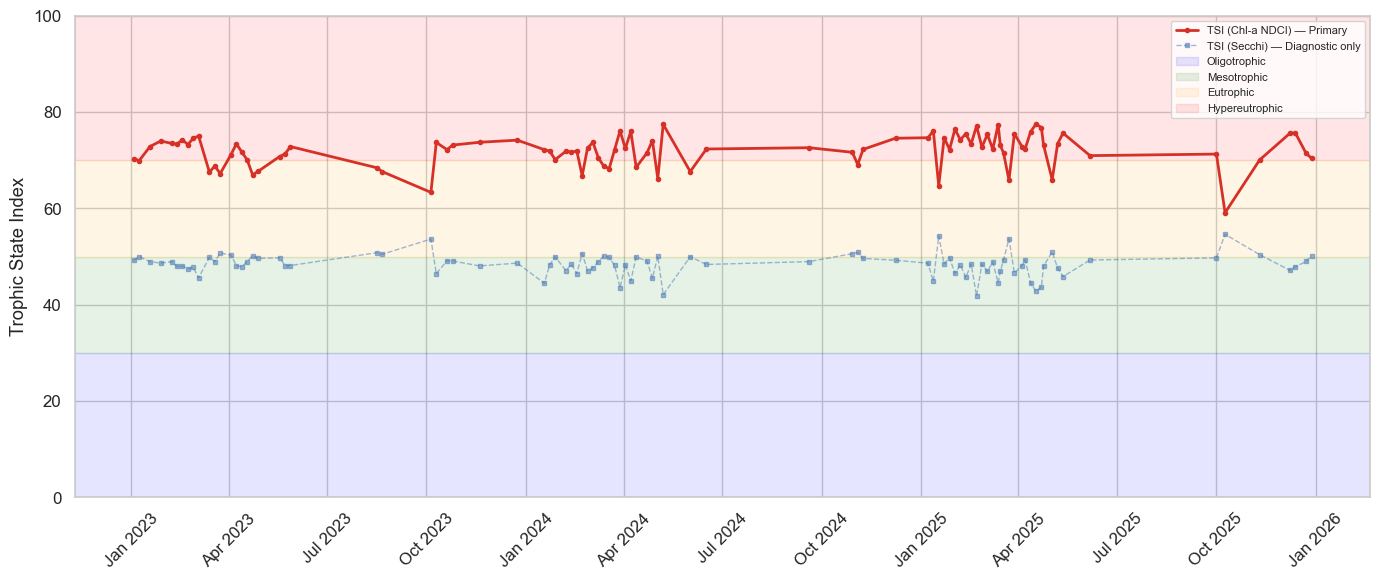


Trophic State Distribution:
Trophic_State
Hypereutrophic    73
Eutrophic         20
Name: count, dtype: int64


In [77]:
# Trophic State Index (TSI) Classification
# Carlson TSI based on Chlorophyll-a and Secchi Depth

ts_df["TSI_Chla"] = 9.81 * np.log(ts_df["Chlorophyll_a_NDCI"].clip(lower=0.1)) + 30.6
ts_df["TSI_Secchi"] = 60 - 14.41 * np.log(ts_df["Secchi_Depth"].clip(lower=0.1))
# ts_df["TSI_Mean"] = (ts_df["TSI_Chla"] + ts_df["TSI_Secchi"]) / 2  # Removed - using TSI_Chla as primary

def classify_trophic(tsi):
    if pd.isna(tsi):
        return np.nan
    elif tsi < 30:
        return "Oligotrophic"
    elif tsi < 50:
        return "Mesotrophic"
    elif tsi < 70:
        return "Eutrophic"
    else:
        return "Hypereutrophic"

ts_df["Trophic_State"] = ts_df["TSI_Chla"].apply(classify_trophic)

fig, ax = plt.subplots(figsize=(14, 6))

# TSI time series
valid_tsi = ts_df.dropna(subset=["TSI_Chla", "TSI_Secchi"])
ax.plot(valid_tsi["time"], valid_tsi["TSI_Chla"], "o-", 
        label="TSI (Chl-a NDCI) — Primary", color="#d73027", 
        markersize=3, linewidth=2)
ax.plot(valid_tsi["time"], valid_tsi["TSI_Secchi"], "s--", 
        label="TSI (Secchi) — Diagnostic only", color="#4575b4", 
        markersize=3, linewidth=1, alpha=0.5)
ax.axhspan(0, 30, alpha=0.1, color="blue", label="Oligotrophic")
ax.axhspan(30, 50, alpha=0.1, color="green", label="Mesotrophic")
ax.axhspan(50, 70, alpha=0.1, color="orange", label="Eutrophic")
ax.axhspan(70, 100, alpha=0.1, color="red", label="Hypereutrophic")
ax.set_ylabel("Trophic State Index")
ax.set_ylim(0, 100)

ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("13_trophic_state_index.png", dpi=600, bbox_inches="tight")
plt.show()

print("\nTrophic State Distribution:")
counts = ts_df["Trophic_State"].value_counts()
print(counts)

Bloom threshold (90th percentile): 121.9 µg/L


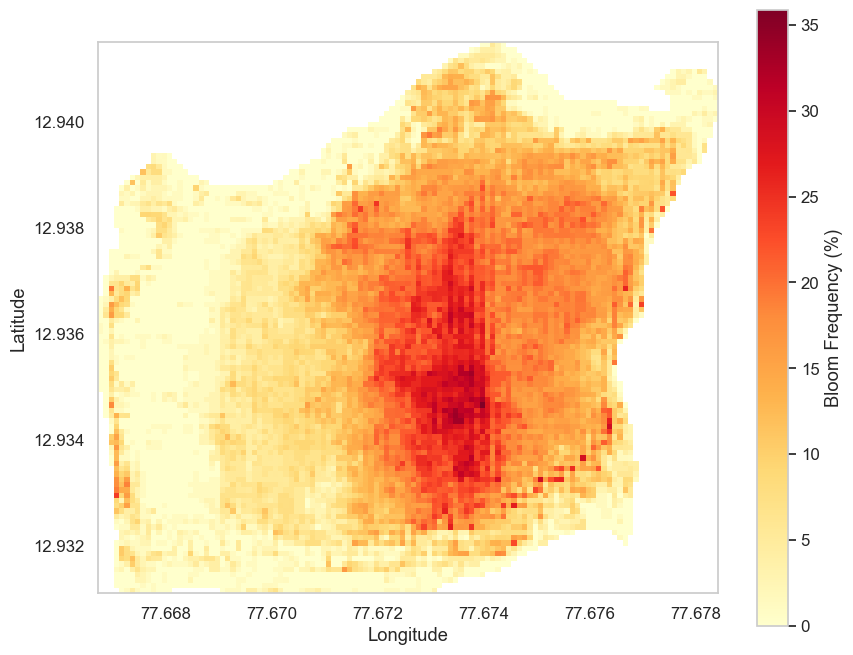

In [76]:
# Algal Bloom Detection & Frequency Map
bloom_threshold = float(np.nanpercentile(ds.Chlorophyll_a_NDCI.values, 90))

print(f"Bloom threshold (90th percentile): {bloom_threshold:.1f} µg/L")

bloom_count = (ds.Chlorophyll_a_NDCI > bloom_threshold).sum(dim="time")
total_obs = ds.Chlorophyll_a_NDCI.notnull().sum(dim="time")
bloom_frequency = (bloom_count / total_obs * 100)

fig, ax = plt.subplots(figsize=(10, 8))
im = bloom_frequency.plot(
    x="lon", y="lat", ax=ax,
    cmap="YlOrRd",
    cbar_kwargs={"label": "Bloom Frequency (%)"},
)
ax.set_aspect("equal")
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.xaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_scientific(False)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.savefig("14_bloom_frequency_map.png", dpi=600, bbox_inches="tight")
plt.show()

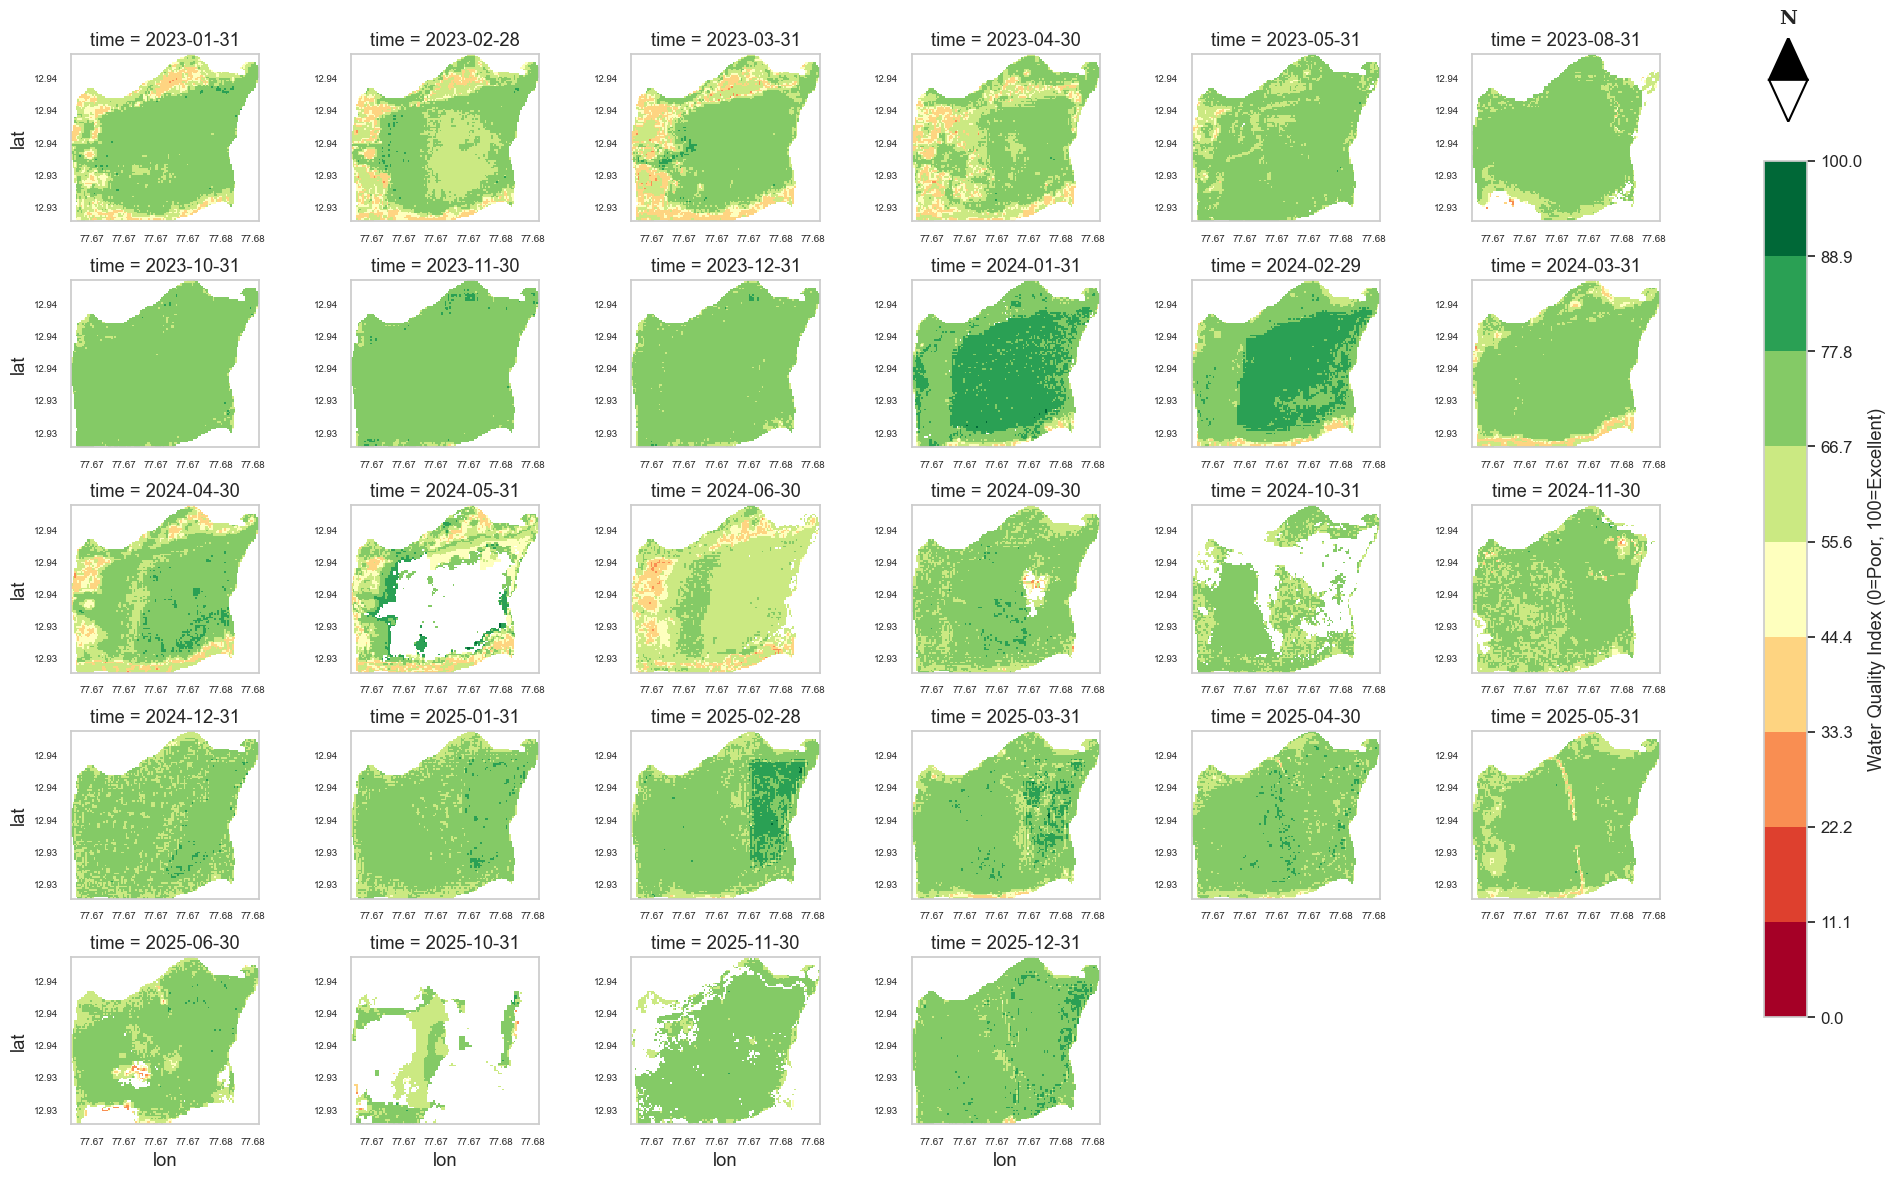

In [110]:
# Water Quality Index (WQI) Composite Score
# Normalize each parameter to 0-100 scale and combine
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from matplotlib.patches import FancyArrowPatch, Circle, Polygon
import matplotlib.patches as mpatches

def normalize_0_100(arr):
    vmin = float(np.nanpercentile(arr, 2))
    vmax = float(np.nanpercentile(arr, 98))
    if vmax == vmin:
        return arr * 0
    return ((arr - vmin) / (vmax - vmin)).clip(0, 1) * 100

# Higher Chl-a/Turbidity/TSS = worse quality (invert)
# Higher Secchi = better quality (keep)
wqi_chla = 100 - normalize_0_100(monthly_filtered.Chlorophyll_a)
wqi_turb = 100 - normalize_0_100(monthly_filtered.Turbidity_FNU)
wqi_tss = 100 - normalize_0_100(monthly_filtered.TSS)
wqi_sec = normalize_0_100(monthly_filtered.Secchi_Depth)

# Weighted composite: WQI (0=worst, 100=best)
WQI = (wqi_chla * 0.3 + wqi_turb * 0.25 + wqi_tss * 0.25 + wqi_sec * 0.2)

fig = WQI.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=0, vmax=100,
    cmap="RdYlGn",
    levels=10,
    figsize=(22, 12),
    cbar_kwargs={"label": "Water Quality Index (0=Poor, 100=Excellent)", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("15_water_quality_index.png", dpi=600, bbox_inches="tight")
plt.show()

Lake center: Lat=12.9363, Lon=77.6726


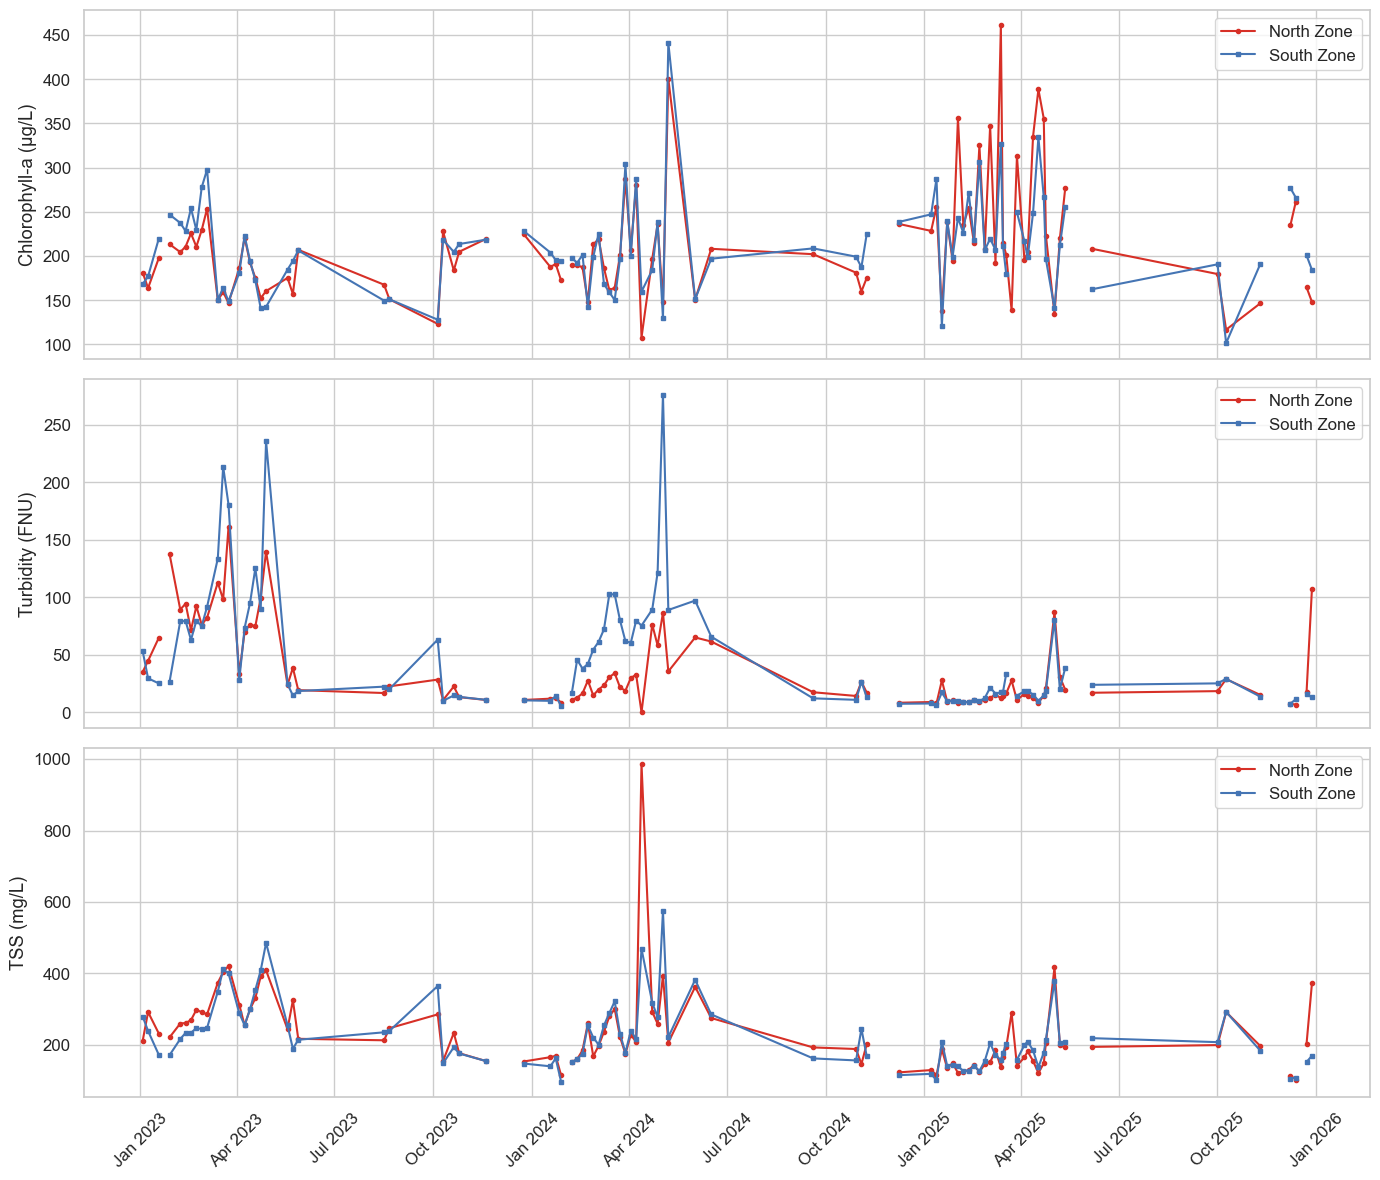

In [59]:
# Spatial Gradient Analysis
# Split lake into zones by latitude (north vs south)

lat_mid = float(ds.lat.median())
lon_mid = float(ds.lon.median())

print(f"Lake center: Lat={lat_mid:.4f}, Lon={lon_mid:.4f}")

north_zone = ds.sel(lat=slice(lat_mid, None)).mean(dim=["lon", "lat"], skipna=True)
south_zone = ds.sel(lat=slice(None, lat_mid)).mean(dim=["lon", "lat"], skipna=True)

north_df = north_zone.to_dataframe().reset_index()
north_df["time"] = pd.to_datetime(north_df["time"])
south_df = south_zone.to_dataframe().reset_index()
south_df["time"] = pd.to_datetime(south_df["time"])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, (param, label) in zip(axes, [
    ("Chlorophyll_a", "Chlorophyll-a (µg/L)"),
    ("Turbidity_FNU", "Turbidity (FNU)"),
    ("TSS", "TSS (mg/L)"),
]):
    ax.plot(north_df["time"], north_df[param], "o-", label="North Zone", color="#d73027", markersize=3)
    ax.plot(south_df["time"], south_df[param], "s-", label="South Zone", color="#4575b4", markersize=3)
    ax.set_ylabel(label)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.savefig("16_spatial_gradient_analysis.png", dpi=600, bbox_inches="tight")
plt.show()

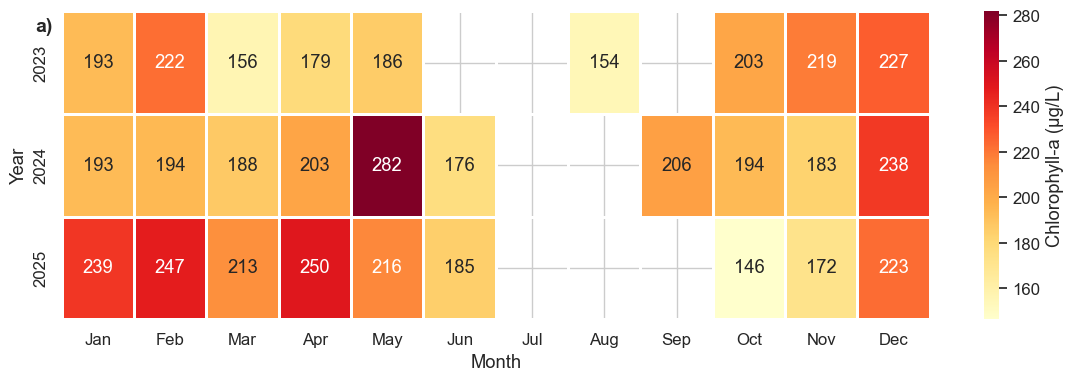

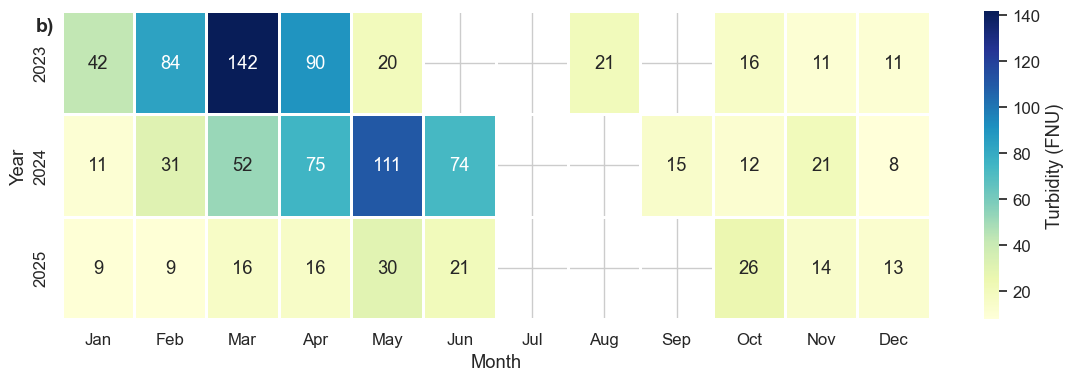

In [113]:
# Monthly Variability Heatmap (Calendar View)
ts_df["year"] = ts_df["time"].dt.year
ts_df["month_name"] = ts_df["time"].dt.strftime("%b")

pivot_chla = ts_df.groupby(["year", "month_name"])["Chlorophyll_a"].median().unstack()
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot_chla = pivot_chla.reindex(columns=month_order)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_chla, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=1, ax=ax, cbar_kws={"label": "Chlorophyll-a (µg/L)"})
ax.set_ylabel("Year")
ax.set_xlabel("Month")
ax.text(-0.03, 0.98, 'a)', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
plt.savefig("17_monthly_heatmap_chla.png", dpi=600, bbox_inches="tight")
plt.show()

# Turbidity heatmap
pivot_turb = ts_df.groupby(["year", "month_name"])["Turbidity_FNU"].median().unstack()
pivot_turb = pivot_turb.reindex(columns=month_order)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_turb, annot=True, fmt=".0f", cmap="YlGnBu",
            linewidths=1, ax=ax, cbar_kws={"label": "Turbidity (FNU)"})

ax.set_ylabel("Year")
ax.set_xlabel("Month")
ax.text(-0.03, 0.98, 'b)', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
plt.savefig("18_monthly_heatmap_turbidity.png", dpi=600, bbox_inches="tight")
plt.show()

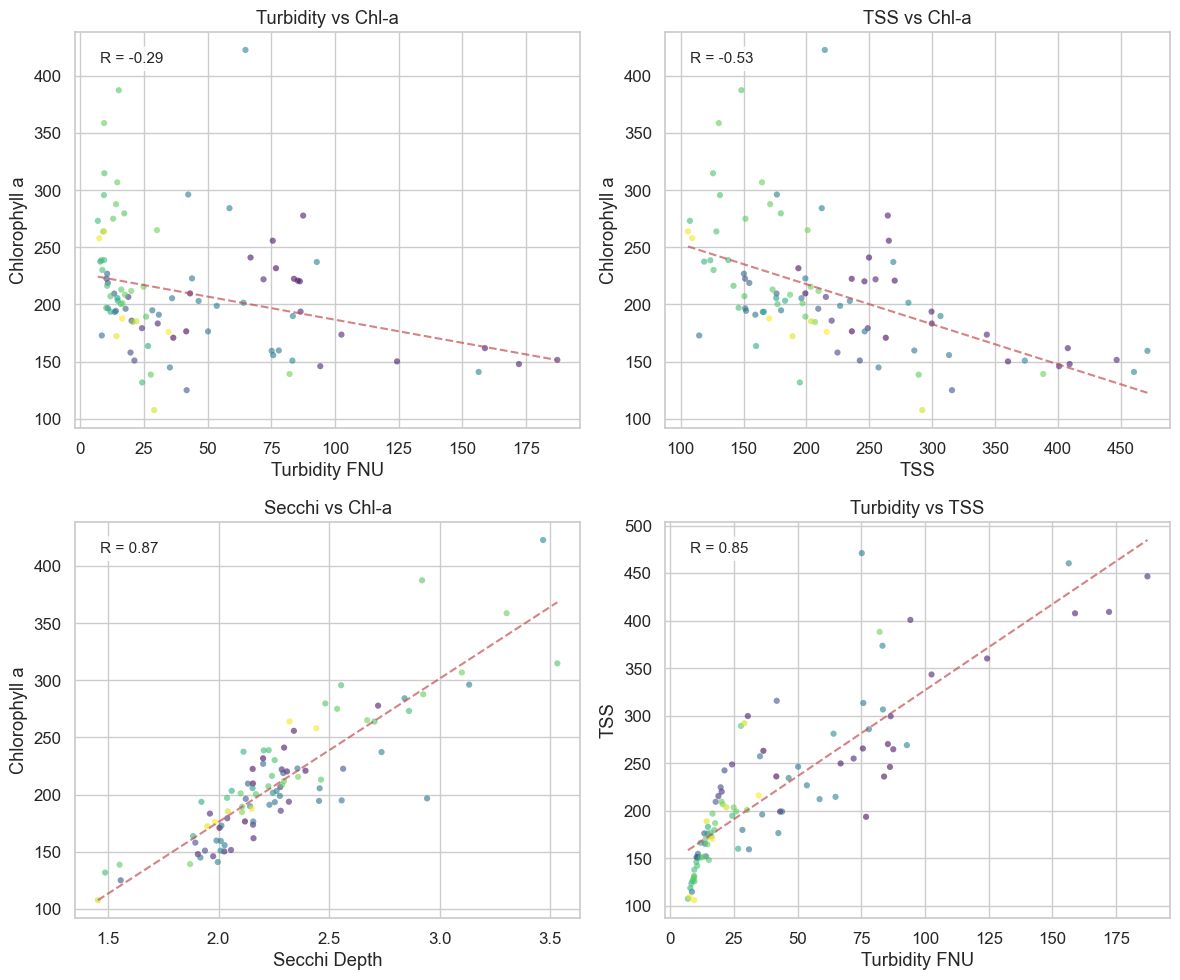

In [61]:
# Parameter Relationship Scatter Matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
scatter_data = ts_df.dropna(subset=["Chlorophyll_a", "Turbidity_FNU", "TSS", "Secchi_Depth"])

pairs = [
    (("Turbidity_FNU", "Chlorophyll_a"), "Turbidity vs Chl-a"),
    (("TSS", "Chlorophyll_a"), "TSS vs Chl-a"),
    (("Secchi_Depth", "Chlorophyll_a"), "Secchi vs Chl-a"),
    (("Turbidity_FNU", "TSS"), "Turbidity vs TSS"),
]

for ax, ((x, y), title) in zip(axes.flat, pairs):
    sc = ax.scatter(scatter_data[x], scatter_data[y],
                    c=scatter_data["time"].astype(np.int64),
                    cmap="viridis", alpha=0.6, s=20, edgecolors="none")
    ax.set_xlabel(x.replace("_", " "))
    ax.set_ylabel(y.replace("_", " "))
    ax.set_title(title)

    # Add trendline
    mask = scatter_data[[x, y]].notna().all(axis=1)
    if mask.sum() > 2:
        z = np.polyfit(scatter_data.loc[mask, x], scatter_data.loc[mask, y], 1)
        p = np.poly1d(z)
        xline = np.linspace(scatter_data[x].min(), scatter_data[x].max(), 100)
        ax.plot(xline, p(xline), "r--", linewidth=1.5, alpha=0.7)
        r = np.corrcoef(scatter_data.loc[mask, x], scatter_data.loc[mask, y])[0, 1]
        ax.text(0.05, 0.95, f"R = {r:.2f}", transform=ax.transAxes, fontsize=11,
                verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))


plt.tight_layout()
plt.savefig("19_scatter_matrix.png", dpi=600, bbox_inches="tight")
plt.show()

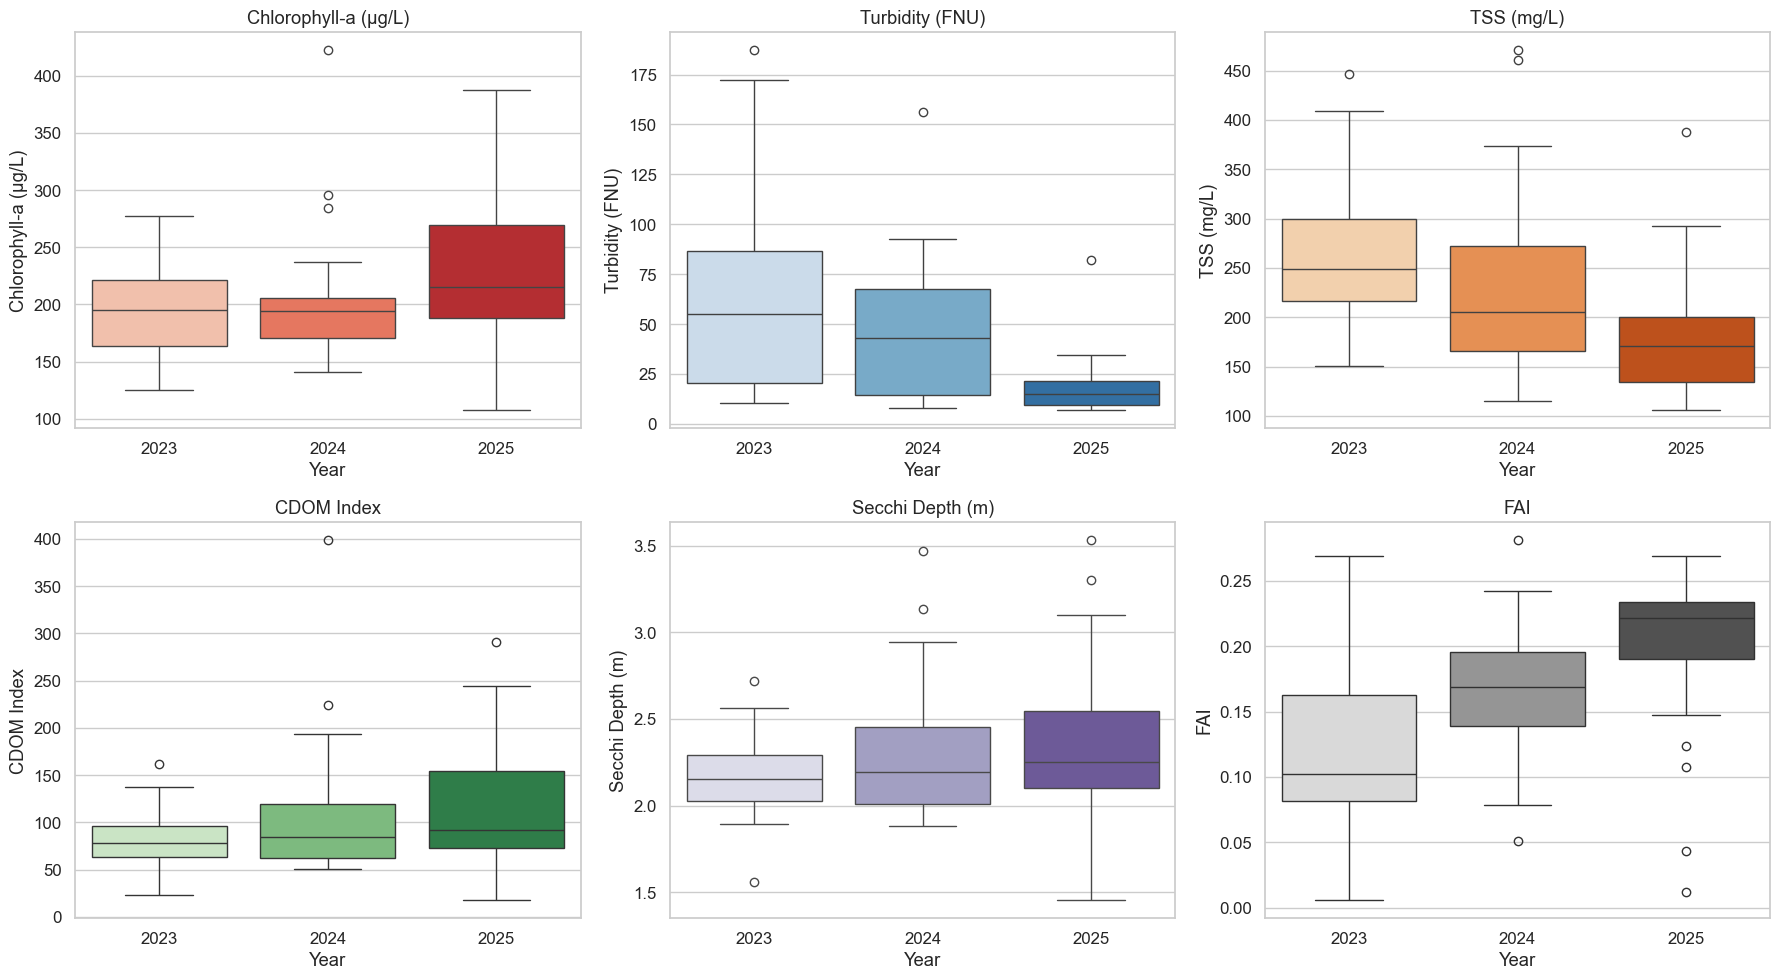

In [62]:
# Annual Comparison Box Plots
ts_df["year"] = ts_df["time"].dt.year

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

params = [
    ("Chlorophyll_a", "Chlorophyll-a (µg/L)", "Reds"),
    ("Turbidity_FNU", "Turbidity (FNU)", "Blues"),
    ("TSS", "TSS (mg/L)", "Oranges"),
    ("CDOM", "CDOM Index", "Greens"),
    ("Secchi_Depth", "Secchi Depth (m)", "Purples"),
    ("FAI", "FAI", "Greys"),
]

for ax, (band, label, pal) in zip(axes, params):
    plot_data = ts_df[["year", band]].dropna()
    if not plot_data.empty:
        sns.boxplot(data=plot_data, x="year", y=band, palette=pal, ax=ax)
    ax.set_ylabel(label)
    ax.set_xlabel("Year")
    ax.set_title(label)


plt.tight_layout()
plt.savefig("20_annual_boxplots.png", dpi=600, bbox_inches="tight")
plt.show()

FAI color range: 0.000 - 0.430


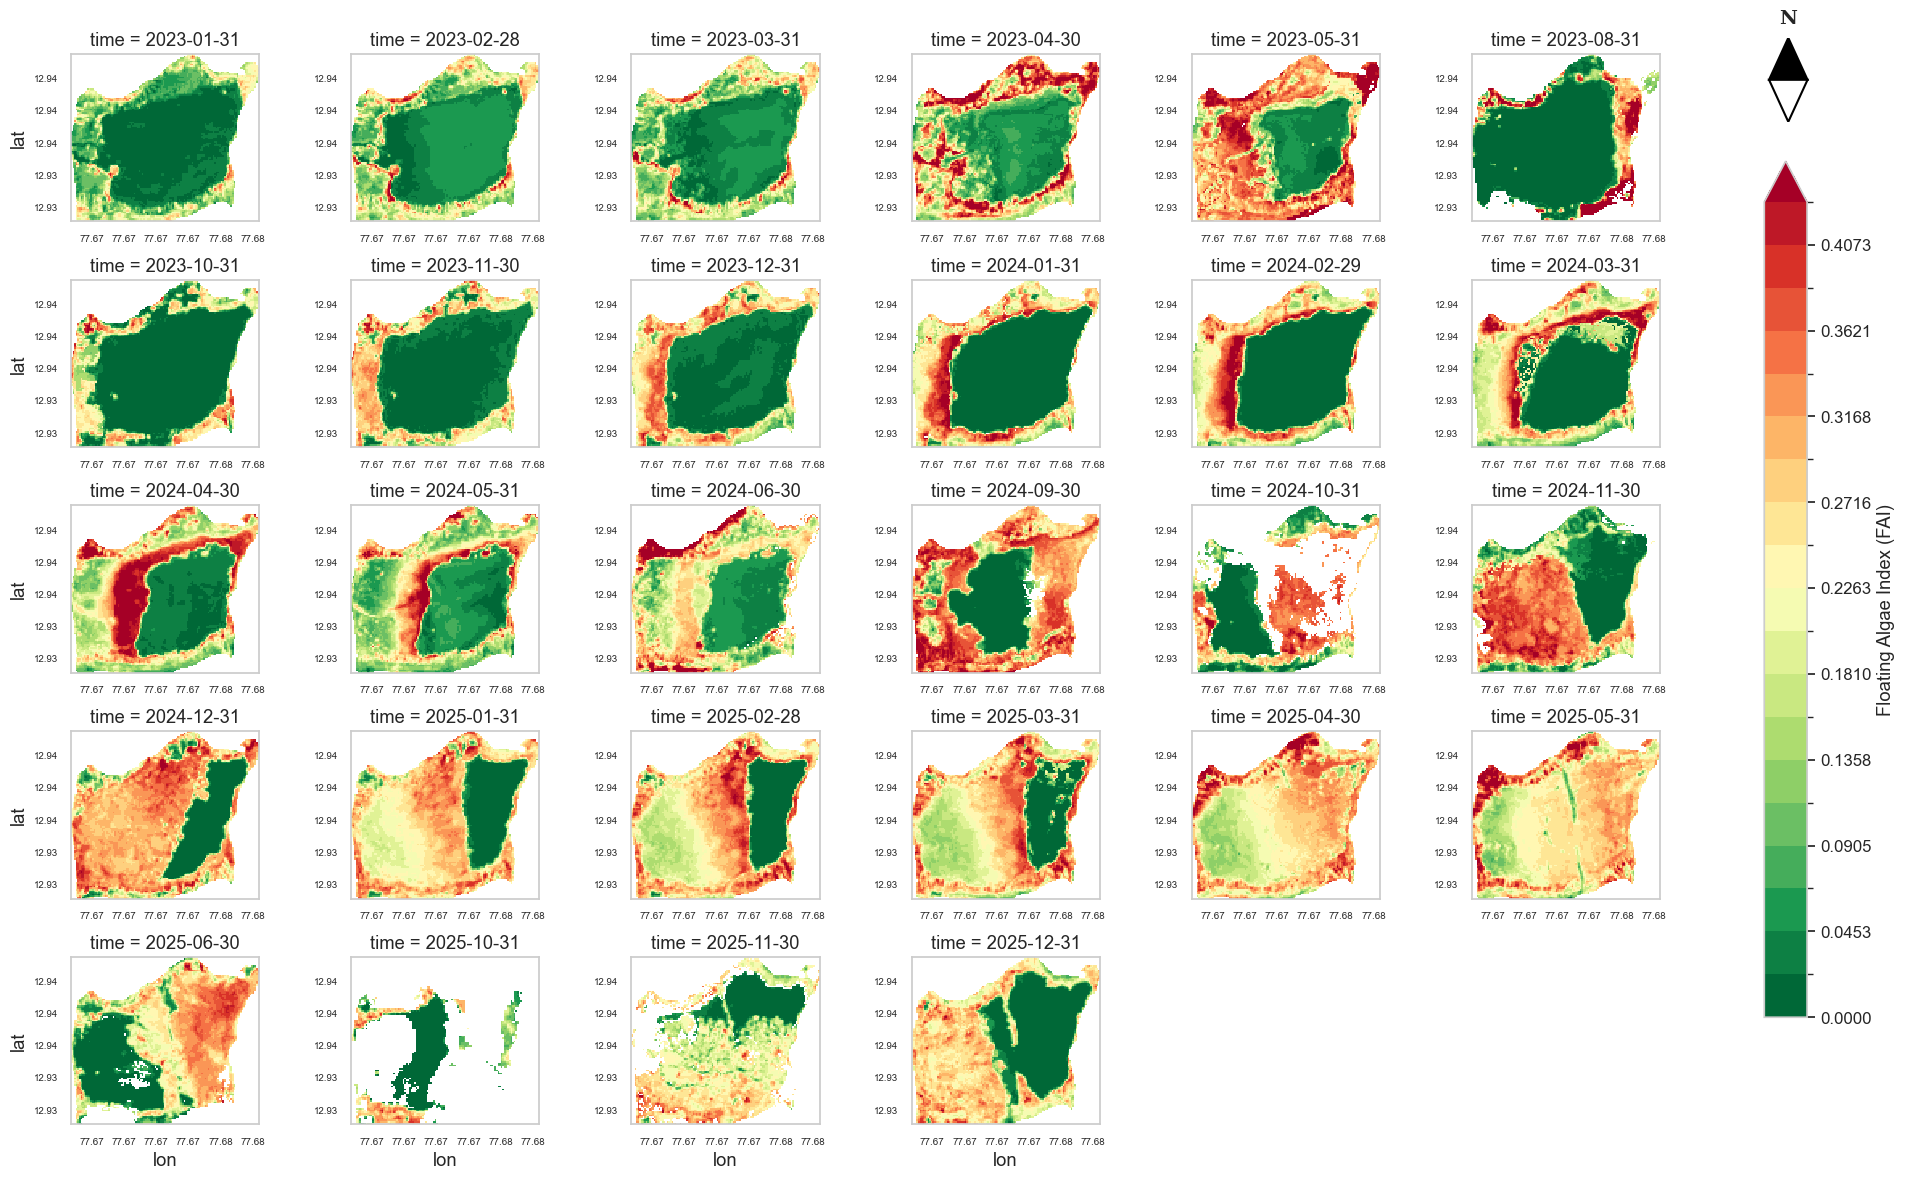

In [114]:
# Monthly FAI Maps
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from matplotlib.patches import FancyArrowPatch, Circle, Polygon
import matplotlib.patches as mpatches

data = monthly_filtered.FAI.values
vmin = float(np.nanpercentile(data, 2))
vmax = float(np.nanpercentile(data, 98))
print(f"FAI color range: {vmin:.3f} - {vmax:.3f}")

fig = monthly_filtered.FAI.plot(
    x="lon", y="lat",
    col="time", col_wrap=6,
    vmin=vmin, vmax=vmax,
    cmap="RdYlGn_r",
    levels=20,
    figsize=(22, 12),
    cbar_kwargs={"label": "Floating Algae Index (FAI)", "shrink": 0.8},
)

# Show lat/lon labels on EVERY panel
for i, ax in enumerate(fig.axs.flat):
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(labelbottom=True, labelleft=True)

# North arrow - your original diamond style, placed top-right above colorbar
def add_north_arrow(fig, x=0.955, y=0.93, arrow_size=0.035):
    ax_arrow = fig.fig.add_axes([x - arrow_size/2, y - arrow_size, arrow_size, arrow_size * 2])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    
    # Black north triangle
    triangle_top = Polygon([[0.5, 1], [0.25, 0.5], [0.75, 0.5]], 
                            facecolor='black', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_top)
    
    # White south triangle
    triangle_bottom = Polygon([[0.5, 0], [0.25, 0.5], [0.75, 0.5]], 
                               facecolor='white', edgecolor='black', linewidth=1.5)
    ax_arrow.add_patch(triangle_bottom)
    
    # "N" label above
    ax_arrow.text(0.5, 1.12, 'N', fontsize=14, fontweight='bold', 
                  ha='center', va='bottom', family='serif')

add_north_arrow(fig, x=0.86, y=0.93, arrow_size=0.035)

plt.savefig("21_monthly_fai_maps.png", dpi=600, bbox_inches="tight")
plt.show()

Sample sizes:
monsoon_period
Post-Monsoon    13
Pre-Monsoon     43
dtype: int64

  MANN-WHITNEY U TEST: PRE-MONSOON vs POST-MONSOON

Chlorophyll_a:
  Pre-Monsoon median:  200.73 (n=42)
  Post-Monsoon median: 193.65 (n=11)
  Change: -3.5%
  p-value: 0.2587 

Turbidity_FNU:
  Pre-Monsoon median:  45.18 (n=42)
  Post-Monsoon median: 14.75 (n=11)
  Change: -67.4%
  p-value: 0.0016 *

TSS:
  Pre-Monsoon median:  230.59 (n=42)
  Post-Monsoon median: 183.01 (n=11)
  Change: -20.6%
  p-value: 0.0260 *

CDOM:
  Pre-Monsoon median:  94.13 (n=42)
  Post-Monsoon median: 66.34 (n=11)
  Change: -29.5%
  p-value: 0.0113 *

Secchi_Depth:
  Pre-Monsoon median:  2.28 (n=42)
  Post-Monsoon median: 2.04 (n=11)
  Change: -10.4%
  p-value: 0.0128 *

FAI:
  Pre-Monsoon median:  0.19 (n=42)
  Post-Monsoon median: 0.09 (n=11)
  Change: -51.4%
  p-value: 0.0032 *


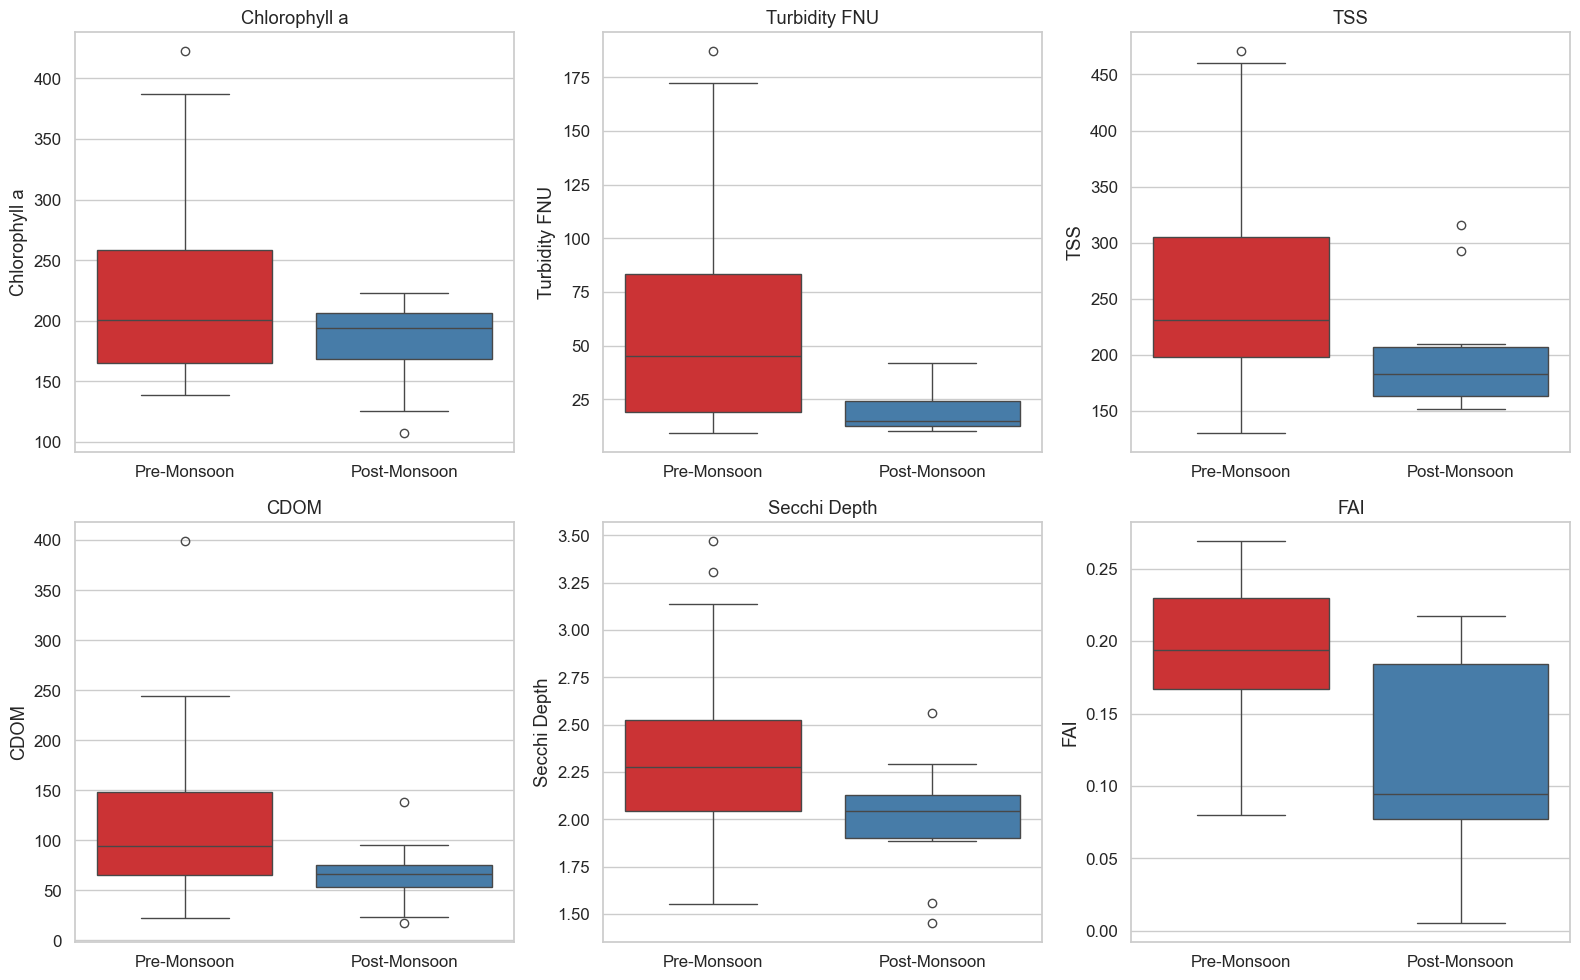

In [64]:
# Pre-Monsoon vs Post-Monsoon Comparison
from scipy import stats

# Define seasons for Indian context
# Pre-Monsoon: March, April, May (MAM)
# Post-Monsoon: October, November (ON)

ts_df["month"] = ts_df["time"].dt.month

ts_df["monsoon_period"] = ts_df["month"].map({
    1: "Other", 2: "Other",
    3: "Pre-Monsoon", 4: "Pre-Monsoon", 5: "Pre-Monsoon",
    6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Post-Monsoon", 11: "Post-Monsoon",
    12: "Other"
})

# Filter only Pre and Post monsoon data
monsoon_comparison = ts_df[ts_df["monsoon_period"].isin(["Pre-Monsoon", "Post-Monsoon"])].copy()

print("Sample sizes:")
print(monsoon_comparison.groupby("monsoon_period").size())

# Statistical comparison using Mann-Whitney U test
print("\n" + "=" * 60)
print("  MANN-WHITNEY U TEST: PRE-MONSOON vs POST-MONSOON")
print("=" * 60)

params_to_test = ["Chlorophyll_a", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]
stats_results = []

for param in params_to_test:
    pre = monsoon_comparison[monsoon_comparison["monsoon_period"] == "Pre-Monsoon"][param].dropna()
    post = monsoon_comparison[monsoon_comparison["monsoon_period"] == "Post-Monsoon"][param].dropna()
    
    if len(pre) > 3 and len(post) > 3:
        statistic, pvalue = stats.mannwhitneyu(pre, post, alternative='two-sided')
        pre_median = pre.median()
        post_median = post.median()
        change_pct = ((post_median - pre_median) / pre_median) * 100
        
        print(f"\n{param}:")
        print(f"  Pre-Monsoon median:  {pre_median:.2f} (n={len(pre)})")
        print(f"  Post-Monsoon median: {post_median:.2f} (n={len(post)})")
        print(f"  Change: {change_pct:+.1f}%")
        print(f"  p-value: {pvalue:.4f} {'*' if pvalue < 0.05 else ''}")
        
        stats_results.append({
            "Parameter": param,
            "Pre_Monsoon_Median": pre_median,
            "Post_Monsoon_Median": post_median,
            "Change_Percent": change_pct,
            "p_value": pvalue,
            "Significant": "Yes" if pvalue < 0.05 else "No"
        })

stats_results_df = pd.DataFrame(stats_results)
stats_results_df.to_csv("22_pre_post_monsoon_statistics.csv", index=False)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {"Pre-Monsoon": "#e41a1c", "Post-Monsoon": "#377eb8"}

for ax, param in zip(axes, params_to_test):
    plot_data = monsoon_comparison[["monsoon_period", param]].dropna()
    if not plot_data.empty:
        sns.boxplot(data=plot_data, x="monsoon_period", y=param, 
                    palette=colors, order=["Pre-Monsoon", "Post-Monsoon"], ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(param.replace("_", " "))
    ax.set_title(param.replace("_", " "))


plt.tight_layout()
plt.savefig("22_pre_post_monsoon_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

  WATER QUALITY STANDARDS COMPLIANCE ASSESSMENT

1. TROPHIC STATUS (WHO/OECD Chlorophyll-a Thresholds):
   Oligotrophic (<2.5 µg/L):    0/93 (0.0%)
   Mesotrophic (2.5-8 µg/L):    0/93 (0.0%)
   Eutrophic (8-25 µg/L):       1/93 (1.1%)
   Hypereutrophic (>25 µg/L):   92/93 (98.9%)

2. TSS COMPLIANCE (CPCB Class D - Fish & Wildlife: 100 mg/L):
   Compliant (≤100 mg/L):       0/93 (0.0%)
   Exceeding (>100 mg/L):       93/93 (100.0%)

3. WATER TRANSPARENCY (Secchi Depth):
   Poor (<1.0 m):               0/93 (0.0%)
   Moderate (1.0-2.0 m):        17/93 (18.3%)
   Good (>2.0 m):               76/93 (81.7%)


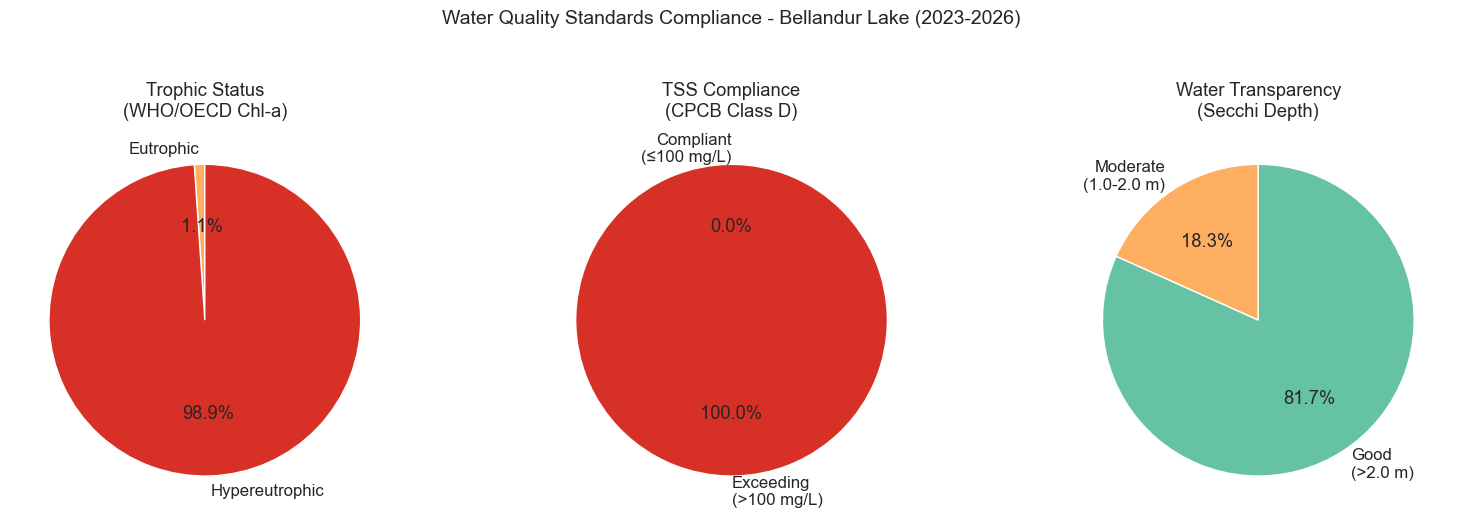


Compliance assessment exported to CSV.


In [65]:
# Water Quality Standards Compliance Assessment
# Based on CPCB India and WHO/OECD guidelines

print("=" * 70)
print("  WATER QUALITY STANDARDS COMPLIANCE ASSESSMENT")
print("=" * 70)

# Define thresholds
thresholds = {
    "Chlorophyll_a": {
        "Oligotrophic": 2.5,
        "Mesotrophic": 8,
        "Eutrophic": 25,
        "Hypereutrophic": 25  # Above this
    },
    "TSS": {
        "Class_D_Fisheries": 100  # CPCB limit for fisheries
    },
    "Secchi_Depth": {
        "Poor_Transparency": 1.0  # Below 1m is poor
    }
}

# Chlorophyll-a classification (WHO/OECD)
chla_values = ts_df["Chlorophyll_a_NDCI"].dropna()
n_total = len(chla_values)

n_oligotrophic = (chla_values < 2.5).sum()
n_mesotrophic = ((chla_values >= 2.5) & (chla_values < 8)).sum()
n_eutrophic = ((chla_values >= 8) & (chla_values < 25)).sum()
n_hypereutrophic = (chla_values >= 25).sum()

print("\n1. TROPHIC STATUS (WHO/OECD Chlorophyll-a Thresholds):")
print(f"   Oligotrophic (<2.5 µg/L):    {n_oligotrophic}/{n_total} ({100*n_oligotrophic/n_total:.1f}%)")
print(f"   Mesotrophic (2.5-8 µg/L):    {n_mesotrophic}/{n_total} ({100*n_mesotrophic/n_total:.1f}%)")
print(f"   Eutrophic (8-25 µg/L):       {n_eutrophic}/{n_total} ({100*n_eutrophic/n_total:.1f}%)")
print(f"   Hypereutrophic (>25 µg/L):   {n_hypereutrophic}/{n_total} ({100*n_hypereutrophic/n_total:.1f}%)")

# TSS compliance (CPCB Class D - Fisheries: 100 mg/L)
tss_values = ts_df["TSS"].dropna()
n_tss_total = len(tss_values)
n_tss_exceed = (tss_values > 100).sum()
n_tss_comply = (tss_values <= 100).sum()

print("\n2. TSS COMPLIANCE (CPCB Class D - Fish & Wildlife: 100 mg/L):")
print(f"   Compliant (≤100 mg/L):       {n_tss_comply}/{n_tss_total} ({100*n_tss_comply/n_tss_total:.1f}%)")
print(f"   Exceeding (>100 mg/L):       {n_tss_exceed}/{n_tss_total} ({100*n_tss_exceed/n_tss_total:.1f}%)")

# Secchi Depth assessment
secchi_values = ts_df["Secchi_Depth"].dropna()
n_secchi_total = len(secchi_values)
n_poor_clarity = (secchi_values < 1.0).sum()
n_moderate_clarity = ((secchi_values >= 1.0) & (secchi_values < 2.0)).sum()
n_good_clarity = (secchi_values >= 2.0).sum()

print("\n3. WATER TRANSPARENCY (Secchi Depth):")
print(f"   Poor (<1.0 m):               {n_poor_clarity}/{n_secchi_total} ({100*n_poor_clarity/n_secchi_total:.1f}%)")
print(f"   Moderate (1.0-2.0 m):        {n_moderate_clarity}/{n_secchi_total} ({100*n_moderate_clarity/n_secchi_total:.1f}%)")
print(f"   Good (>2.0 m):               {n_good_clarity}/{n_secchi_total} ({100*n_good_clarity/n_secchi_total:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Trophic Status Pie Chart
ax1 = axes[0]
trophic_counts = [n_oligotrophic, n_mesotrophic, n_eutrophic, n_hypereutrophic]
trophic_labels = ["Oligotrophic", "Mesotrophic", "Eutrophic", "Hypereutrophic"]
trophic_colors = ["#2166ac", "#66c2a5", "#fdae61", "#d73027"]
non_zero_idx = [i for i, c in enumerate(trophic_counts) if c > 0]
ax1.pie([trophic_counts[i] for i in non_zero_idx], 
        labels=[trophic_labels[i] for i in non_zero_idx],
        colors=[trophic_colors[i] for i in non_zero_idx],
        autopct="%1.1f%%", startangle=90)
ax1.set_title("Trophic Status\n(WHO/OECD Chl-a)")

# TSS Compliance Pie Chart
ax2 = axes[1]
tss_counts = [n_tss_comply, n_tss_exceed]
tss_labels = ["Compliant\n(≤100 mg/L)", "Exceeding\n(>100 mg/L)"]
tss_colors = ["#66c2a5", "#d73027"]
ax2.pie(tss_counts, labels=tss_labels, colors=tss_colors,
        autopct="%1.1f%%", startangle=90)
ax2.set_title("TSS Compliance\n(CPCB Class D)")

# Secchi Depth Pie Chart
ax3 = axes[2]
secchi_counts = [n_poor_clarity, n_moderate_clarity, n_good_clarity]
secchi_labels = ["Poor\n(<1.0 m)", "Moderate\n(1.0-2.0 m)", "Good\n(>2.0 m)"]
secchi_colors = ["#d73027", "#fdae61", "#66c2a5"]
non_zero_idx = [i for i, c in enumerate(secchi_counts) if c > 0]
ax3.pie([secchi_counts[i] for i in non_zero_idx],
        labels=[secchi_labels[i] for i in non_zero_idx],
        colors=[secchi_colors[i] for i in non_zero_idx],
        autopct="%1.1f%%", startangle=90)
ax3.set_title("Water Transparency\n(Secchi Depth)")

plt.suptitle("Water Quality Standards Compliance - Bellandur Lake (2023-2026)", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("23_water_quality_compliance.png", dpi=300, bbox_inches="tight")
plt.show()

# Export compliance summary
compliance_summary = {
    "Assessment": ["Trophic Status", "Trophic Status", "Trophic Status", "Trophic Status",
                   "TSS Compliance", "TSS Compliance",
                   "Water Transparency", "Water Transparency", "Water Transparency"],
    "Category": ["Oligotrophic", "Mesotrophic", "Eutrophic", "Hypereutrophic",
                 "Compliant", "Exceeding",
                 "Poor", "Moderate", "Good"],
    "Count": [n_oligotrophic, n_mesotrophic, n_eutrophic, n_hypereutrophic,
              n_tss_comply, n_tss_exceed,
              n_poor_clarity, n_moderate_clarity, n_good_clarity],
    "Percentage": [100*n_oligotrophic/n_total, 100*n_mesotrophic/n_total, 
                   100*n_eutrophic/n_total, 100*n_hypereutrophic/n_total,
                   100*n_tss_comply/n_tss_total, 100*n_tss_exceed/n_tss_total,
                   100*n_poor_clarity/n_secchi_total, 100*n_moderate_clarity/n_secchi_total,
                   100*n_good_clarity/n_secchi_total]
}
compliance_df = pd.DataFrame(compliance_summary)
compliance_df.to_csv("23_compliance_assessment.csv", index=False)
print("\nCompliance assessment exported to CSV.")

Calculating pixel-wise Mann-Kendall trends for Chlorophyll-a...
This may take a few minutes...
  Progress: 10%
  Progress: 21%
  Progress: 31%
  Progress: 40%
  Progress: 50%
  Progress: 61%
  Progress: 70%
  Progress: 80%
  Progress: 91%
  Progress: 100%

Pixels with sufficient data (>=15 obs): 8829
Uncorrected (p<0.05):
  Increasing: 3460, Decreasing: 185, No trend: 5184

FDR-corrected (Benjamini-Hochberg):
  Increasing: 2978 (33.7%)
  Decreasing: 131 (1.5%)
  No trend:   5720 (64.8%)


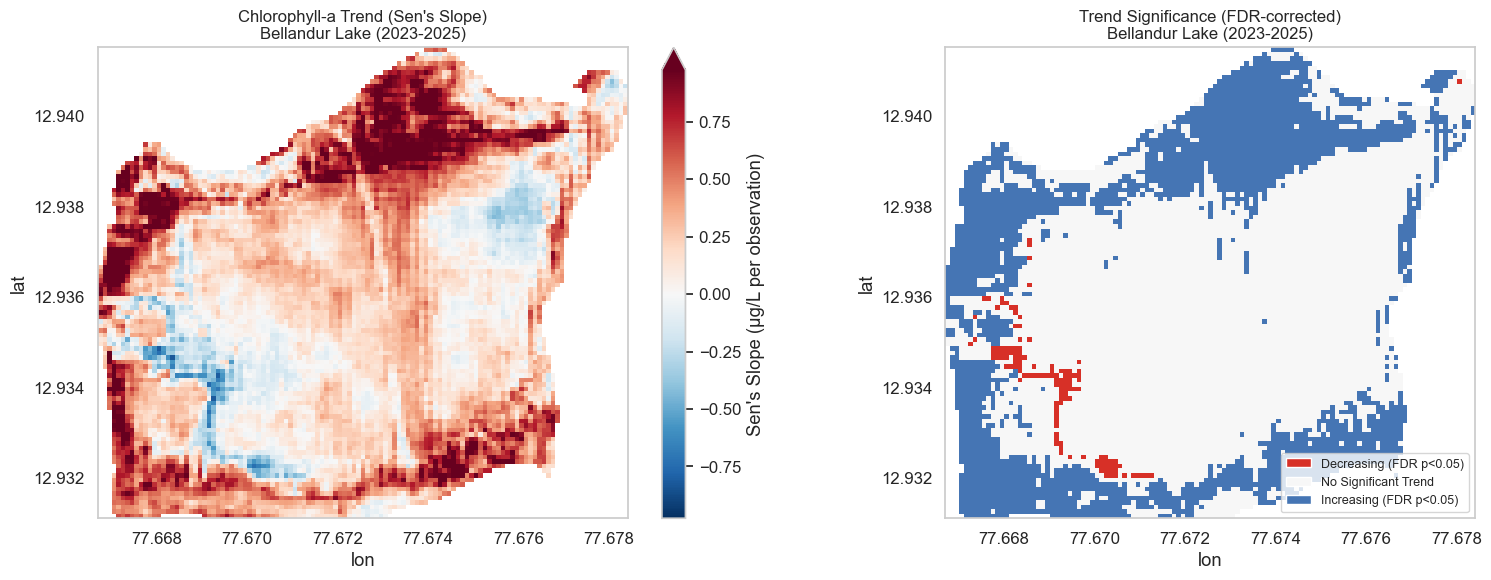


Pixel-wise Trend Summary (Chlorophyll-a):
  Significant Increasing: 2978 pixels (33.7%)
  Significant Decreasing: 131 pixels (1.5%)
  No Significant Trend:   5720 pixels (64.8%)


In [115]:
# Pixel-wise Trend Analysis for Chlorophyll-a
import warnings
warnings.filterwarnings("ignore")

print("Calculating pixel-wise Mann-Kendall trends for Chlorophyll-a...")
print("This may take a few minutes...")

# Get dimensions
n_time = len(ds.time)
n_lon = len(ds.lon)
n_lat = len(ds.lat)

# Initialize output arrays
slope_map = np.full((n_lon, n_lat), np.nan)
pvalue_map = np.full((n_lon, n_lat), np.nan)
trend_map = np.full((n_lon, n_lat), np.nan)  # 1=increasing, -1=decreasing, 0=no trend

# Minimum observations required for trend test
min_obs = 15

# Extract Chlorophyll-a data
chla_data = ds.Chlorophyll_a_NDCI.values

total_pixels = n_lon * n_lat
valid_pixels = 0
progress_interval = total_pixels // 10

for i in range(n_lon):
    for j in range(n_lat):
        pixel_ts = chla_data[:, i, j]
        valid_obs = np.sum(~np.isnan(pixel_ts))
        
        if valid_obs >= min_obs:
            # Remove NaN values for trend test
            valid_idx = ~np.isnan(pixel_ts)
            pixel_clean = pixel_ts[valid_idx]
            
            try:
                result = mk.original_test(pixel_clean)
                slope_map[i, j] = result.slope
                pvalue_map[i, j] = result.p
                
                if result.p < 0.05:
                    if result.slope > 0:
                        trend_map[i, j] = 1  # Significant increasing
                    else:
                        trend_map[i, j] = -1  # Significant decreasing
                else:
                    trend_map[i, j] = 0  # No significant trend
                    
                valid_pixels += 1
            except:
                pass
    
    # Progress update
    current_pixel = (i + 1) * n_lat
    if current_pixel % progress_interval < n_lat:
        print(f"  Progress: {100 * current_pixel / total_pixels:.0f}%")

print(f"\nPixels with sufficient data (>={min_obs} obs): {valid_pixels}")

from statsmodels.stats.multitest import multipletests

# Collect all valid p-values with their pixel positions
valid_pvals = []
valid_positions = []

for i in range(n_lon):
    for j in range(n_lat):
        if not np.isnan(pvalue_map[i, j]):
            valid_pvals.append(pvalue_map[i, j])
            valid_positions.append((i, j))

# Apply Benjamini-Hochberg FDR correction
rejected, pvals_corrected, _, _ = multipletests(valid_pvals, alpha=0.05, method='fdr_bh')

# Rebuild trend_map using FDR-corrected significance
trend_map_fdr = np.full((n_lon, n_lat), np.nan)

for idx, (i, j) in enumerate(valid_positions):
    if rejected[idx]:
        if slope_map[i, j] > 0:
            trend_map_fdr[i, j] = 1
        else:
            trend_map_fdr[i, j] = -1
    else:
        trend_map_fdr[i, j] = 0

# Report both uncorrected and FDR-corrected counts
n_increasing = np.sum(trend_map == 1)
n_decreasing = np.sum(trend_map == -1)
n_no_trend = np.sum(trend_map == 0)
n_total_valid = n_increasing + n_decreasing + n_no_trend

n_inc_fdr = np.sum(trend_map_fdr == 1)
n_dec_fdr = np.sum(trend_map_fdr == -1)
n_none_fdr = np.sum(trend_map_fdr == 0)
n_total_fdr = n_inc_fdr + n_dec_fdr + n_none_fdr

print("Uncorrected (p<0.05):")
print(f"  Increasing: {n_increasing}, Decreasing: {n_decreasing}, No trend: {n_no_trend}")
print("\nFDR-corrected (Benjamini-Hochberg):")
print(f"  Increasing: {n_inc_fdr} ({100*n_inc_fdr/n_total_fdr:.1f}%)")
print(f"  Decreasing: {n_dec_fdr} ({100*n_dec_fdr/n_total_fdr:.1f}%)")
print(f"  No trend:   {n_none_fdr} ({100*n_none_fdr/n_total_fdr:.1f}%)")

# Create xarray DataArrays for plotting
slope_da = xr.DataArray(
    slope_map.T,  # Transpose to match lat/lon orientation
    dims=["lat", "lon"],
    coords={"lat": ds.lat.values, "lon": ds.lon.values}
)

trend_da = xr.DataArray(
    trend_map_fdr.T,  # Use FDR-corrected trends
    dims=["lat", "lon"],
    coords={"lat": ds.lat.values, "lon": ds.lon.values}
)

pvalue_da = xr.DataArray(
    pvalue_map.T,
    dims=["lat", "lon"],
    coords={"lat": ds.lat.values, "lon": ds.lon.values}
)

# Plot Sen's Slope Map
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sen's Slope
ax1 = axes[0]
slope_abs_max = np.nanpercentile(np.abs(slope_map), 95)
im1 = slope_da.plot(
    ax=ax1,
    cmap="RdBu_r",
    vmin=-slope_abs_max, vmax=slope_abs_max,
    cbar_kwargs={"label": "Sen's Slope (µg/L per observation)"}
)
ax1.set_aspect("equal")
ax1.set_title("Chlorophyll-a Trend (Sen's Slope)\nBellandur Lake (2023-2025)", fontsize=12)
ax1.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax1.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax1.xaxis.get_major_formatter().set_scientific(False)
ax1.yaxis.get_major_formatter().set_scientific(False)

# Trend Significance Map
ax2 = axes[1]
from matplotlib.colors import ListedColormap
trend_cmap = ListedColormap(["#d73027", "#f7f7f7", "#4575b4"])  # Decreasing, No trend, Increasing
im2 = trend_da.plot(
    ax=ax2,
    cmap=trend_cmap,
    vmin=-1.5, vmax=1.5,
    add_colorbar=False
)
ax2.set_aspect("equal")
ax2.set_title("Trend Significance (FDR-corrected)\nBellandur Lake (2023-2025)", fontsize=12)
ax2.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax2.xaxis.get_major_formatter().set_scientific(False)
ax2.yaxis.get_major_formatter().set_scientific(False)

# Add legend for trend map
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d73027", label="Decreasing (FDR p<0.05)"),
    Patch(facecolor="#f7f7f7", label="No Significant Trend"),
    Patch(facecolor="#4575b4", label="Increasing (FDR p<0.05)")
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("24_pixelwise_trend_map.png", dpi=600, bbox_inches="tight")
plt.show()

# Summary statistics
print("\nPixel-wise Trend Summary (Chlorophyll-a):")
print(f"  Significant Increasing: {n_inc_fdr} pixels ({100*n_inc_fdr/n_total_fdr:.1f}%)")
print(f"  Significant Decreasing: {n_dec_fdr} pixels ({100*n_dec_fdr/n_total_fdr:.1f}%)")
print(f"  No Significant Trend:   {n_none_fdr} pixels ({100*n_none_fdr/n_total_fdr:.1f}%)")

In [86]:
# Comprehensive Statistics Summary for All Analyses
print("=" * 80)
print("  BELLANDUR LAKE WATER QUALITY ANALYSIS - COMPREHENSIVE STATISTICS")
print("  Study Period: 2023-01-01 to 2026-02-11 (3 years)")
print("=" * 80)

# 1. STUDY AREA AND DATA AVAILABILITY
print("\n" + "=" * 80)
print("  1. STUDY AREA AND DATA AVAILABILITY")
print("=" * 80)
print(f"  Study Area: {study_area_km2:.2f} km²")
print(f"  Total Sentinel-2 Images: {n_images}")
print(f"  Total Timesteps in Dataset: {len(ds.time)}")
print(f"  Valid Monthly Observations: {len(valid_times)} out of 36 months")
print(f"  Missing Months (Monsoon): June, July, August, September (cloud cover)")
print(f"  Spatial Resolution: ~10m (resampled)")
print(f"  Total Pixels: {12168}")
print(f"  Valid Water Pixels: ~{8829} (72.6% of study area)")

# 2. DESCRIPTIVE STATISTICS FOR ALL PARAMETERS
print("\n" + "=" * 80)
print("  2. DESCRIPTIVE STATISTICS (n=93 observations)")
print("=" * 80)

params_stats = ["Chlorophyll_a_NDCI", "Chlorophyll_a", "NDCI", "Turbidity_FNU", 
                "TSS", "CDOM", "Secchi_Depth", "FAI"]
units = ["µg/L", "µg/L", "dimensionless", "FNU", "mg/L", "index", "m", "dimensionless"]

for param, unit in zip(params_stats, units):
    data = ts_df[param].dropna()
    print(f"\n  {param} ({unit}):")
    print(f"    Count: {len(data)}")
    print(f"    Mean: {data.mean():.2f}")
    print(f"    Std Dev: {data.std():.2f}")
    print(f"    Min: {data.min():.2f}")
    print(f"    25th Percentile: {data.quantile(0.25):.2f}")
    print(f"    Median: {data.median():.2f}")
    print(f"    75th Percentile: {data.quantile(0.75):.2f}")
    print(f"    Max: {data.max():.2f}")

# 3. MONTHLY MAP COLOR RANGES
print("\n" + "=" * 80)
print("  3. MONTHLY MAP COLOR RANGES (2nd-98th Percentile)")
print("=" * 80)
print(f"  Chlorophyll-a: 112.3 - 371.0 µg/L")
print(f"  Turbidity: 2.2 - 141.6 FNU")
print(f"  TSS: 60.5 - 588.3 mg/L")
print(f"  CDOM: 25.9 - 302.6 index")
print(f"  Secchi Depth: 1.6 - 2.9 m")
print(f"  FAI: 0.000 - 0.430")

# 4. CORRELATION MATRIX
print("\n" + "=" * 80)
print("  4. INTER-PARAMETER CORRELATIONS (Pearson R)")
print("=" * 80)
corr_cols = ["Chlorophyll_a_NDCI", "Chlorophyll_a", "Turbidity_FNU", 
             "TSS", "CDOM", "Secchi_Depth", "FAI"]
corr_matrix = ts_df[corr_cols].corr()
print("\n  Key Correlations:")
print(f"    Chlorophyll_a_NDCI vs Turbidity_FNU: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'Turbidity_FNU']:.3f}")
print(f"    Chlorophyll_a_NDCI vs TSS: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'TSS']:.3f}")
print(f"    Chlorophyll_a_NDCI vs Secchi_Depth: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'Secchi_Depth']:.3f}")
print(f"    Chlorophyll_a_NDCI vs CDOM: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'CDOM']:.3f}")
print(f"    Chlorophyll_a_NDCI vs FAI: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'FAI']:.3f}")
print(f"    Turbidity_FNU vs TSS: R = {corr_matrix.loc['Turbidity_FNU', 'TSS']:.3f}")
print(f"    Turbidity_FNU vs Secchi_Depth: R = {corr_matrix.loc['Turbidity_FNU', 'Secchi_Depth']:.3f}")
print(f"    TSS vs Secchi_Depth: R = {corr_matrix.loc['TSS', 'Secchi_Depth']:.3f}")
print(f"    CDOM vs Secchi_Depth: R = {corr_matrix.loc['CDOM', 'Secchi_Depth']:.3f}")

# 5. SEASONAL STATISTICS
print("\n" + "=" * 80)
print("  5. SEASONAL STATISTICS (Median Values)")
print("=" * 80)
seasonal_stats = ts_df.groupby("season")[["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "Secchi_Depth"]].agg(["median", "std", "count"])
for season in ["DJF", "MAM", "JJA", "SON"]:
    if season in seasonal_stats.index:
        print(f"\n  {season} (Winter/Pre-Monsoon/Monsoon/Post-Monsoon):")
        season_data = ts_df[ts_df["season"] == season]
        for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "Secchi_Depth"]:
            median_val = seasonal_stats.loc[season, (param, "median")]
            count_val = seasonal_stats.loc[season, (param, "count")]
            iqr_val = season_data[param].quantile(0.75) - season_data[param].quantile(0.25)
            print(f"    {param}: {median_val:.2f} [IQR: {iqr_val:.2f}] (n={count_val:.0f})")

# 6. ANNUAL STATISTICS
print("\n" + "=" * 80)
print("  6. ANNUAL STATISTICS (Median Values)")
print("=" * 80)
annual_stats = ts_df.groupby("year")[["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]].agg(["median", "std", "count"])
for year in [2023, 2024, 2025]:
    if year in annual_stats.index:
        print(f"\n  Year {year}:")
        year_data = ts_df[ts_df["year"] == year]
        for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]:
            median_val = annual_stats.loc[year, (param, "median")]
            count_val = annual_stats.loc[year, (param, "count")]
            iqr_val = year_data[param].quantile(0.75) - year_data[param].quantile(0.25)
            print(f"    {param}: {median_val:.2f} [IQR: {iqr_val:.2f}] (n={count_val:.0f})")

# 7. MANN-KENDALL TREND ANALYSIS
print("\n" + "=" * 80)
print("  7. MANN-KENDALL TREND ANALYSIS (Lake-Average Time Series)")
print("=" * 80)
ts_clean = ts_df[["time", "Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth"]].dropna()
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth"]:
    series = ts_clean[param].values
    if len(series) > 10:
        result = mk.original_test(series)
        print(f"\n  {param}:")
        print(f"    Trend: {result.trend}")
        print(f"    p-value: {result.p:.4f}")
        print(f"    Sen's Slope: {result.slope:.4f} per timestep")
        print(f"    Tau: {result.Tau:.4f}")
        print(f"    S statistic: {result.s}")
        print(f"    Significance: {'Significant (p<0.05)' if result.p < 0.05 else 'Not Significant'}")

# 8. TROPHIC STATE INDEX
print("\n" + "=" * 80)
print("  8. TROPHIC STATE INDEX (Carlson TSI)")
print("=" * 80)
tsi_data = ts_df[["TSI_Chla", "TSI_Secchi"]].dropna()
print(f"\n  TSI from Chlorophyll-a (Primary):")
print(f"    Mean: {tsi_data['TSI_Chla'].mean():.2f}")
print(f"    Min: {tsi_data['TSI_Chla'].min():.2f}")
print(f"    Max: {tsi_data['TSI_Chla'].max():.2f}")
print(f"\n  TSI from Secchi Depth (Diagnostic):")
print(f"    Mean: {tsi_data['TSI_Secchi'].mean():.2f}")
print(f"    Min: {tsi_data['TSI_Secchi'].min():.2f}")
print(f"    Max: {tsi_data['TSI_Secchi'].max():.2f}")
print(f"\n  Trophic State Distribution (based on TSI Chlorophyll-a):")
trophic_counts = ts_df["Trophic_State"].value_counts()
for state, count in trophic_counts.items():
    print(f"    {state}: {count} ({100*count/len(ts_df):.1f}%)")

# 9. ALGAL BLOOM ANALYSIS
print("\n" + "=" * 80)
print("  9. ALGAL BLOOM ANALYSIS")
print("=" * 80)
print(f"  Bloom Threshold (90th Percentile): {bloom_threshold:.1f} µg/L")
bloom_obs = (ts_df["Chlorophyll_a_NDCI"] > bloom_threshold).sum()
total_obs_chla = ts_df["Chlorophyll_a_NDCI"].notna().sum()
print(f"  Observations Exceeding Threshold: {bloom_obs}/{total_obs_chla} ({100*bloom_obs/total_obs_chla:.1f}%)")

# 10. WATER QUALITY INDEX STATISTICS
print("\n" + "=" * 80)
print("  10. WATER QUALITY INDEX (WQI) STATISTICS")
print("=" * 80)
wqi_values = WQI.values.flatten()
wqi_values = wqi_values[~np.isnan(wqi_values)]
print(f"  WQI Range: 0 (Poor) to 100 (Excellent)")
print(f"  Mean WQI: {np.mean(wqi_values):.2f}")
print(f"  Median WQI: {np.median(wqi_values):.2f}")
print(f"  Std Dev: {np.std(wqi_values):.2f}")
print(f"  Min WQI: {np.min(wqi_values):.2f}")
print(f"  Max WQI: {np.max(wqi_values):.2f}")

# 11. SPATIAL GRADIENT ANALYSIS (North vs South)
print("\n" + "=" * 80)
print("  11. SPATIAL GRADIENT ANALYSIS (North vs South Zones)")
print("=" * 80)
print(f"  Lake Center Latitude: {lat_mid:.4f}")
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS"]:
    north_median = north_df[param].median()
    south_median = south_df[param].median()
    diff_pct = ((north_median - south_median) / south_median) * 100
    print(f"\n  {param}:")
    print(f"    North Zone Median: {north_median:.2f}")
    print(f"    South Zone Median: {south_median:.2f}")
    print(f"    Difference: {diff_pct:+.1f}%")

# 12. PRE-MONSOON vs POST-MONSOON COMPARISON
print("\n" + "=" * 80)
print("  12. PRE-MONSOON vs POST-MONSOON COMPARISON")
print("=" * 80)
print("  Pre-Monsoon: March, April, May (MAM)")
print("  Post-Monsoon: October, November (ON)")
monsoon_comp = ts_df[ts_df["monsoon_period"].isin(["Pre-Monsoon", "Post-Monsoon"])]
print(f"\n  Sample Sizes:")
print(f"    Pre-Monsoon: {len(monsoon_comp[monsoon_comp['monsoon_period'] == 'Pre-Monsoon'])}")
print(f"    Post-Monsoon: {len(monsoon_comp[monsoon_comp['monsoon_period'] == 'Post-Monsoon'])}")
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]:
    pre = monsoon_comp[monsoon_comp["monsoon_period"] == "Pre-Monsoon"][param].dropna()
    post = monsoon_comp[monsoon_comp["monsoon_period"] == "Post-Monsoon"][param].dropna()
    if len(pre) > 3 and len(post) > 3:
        statistic, pvalue = stats.mannwhitneyu(pre, post, alternative='two-sided')
        change_pct = ((post.median() - pre.median()) / pre.median()) * 100
        print(f"\n  {param}:")
        print(f"    Pre-Monsoon Median: {pre.median():.2f}")
        print(f"    Post-Monsoon Median: {post.median():.2f}")
        print(f"    Change: {change_pct:+.1f}%")
        print(f"    Mann-Whitney U p-value: {pvalue:.4f}")
        print(f"    Significant: {'Yes' if pvalue < 0.05 else 'No'}")

# 13. WATER QUALITY STANDARDS COMPLIANCE
print("\n" + "=" * 80)
print("  13. WATER QUALITY STANDARDS COMPLIANCE")
print("=" * 80)
print("\n  A. Trophic Status (WHO/OECD Chlorophyll-a Thresholds):")
chla_values = ts_df["Chlorophyll_a_NDCI"].dropna()
n_total = len(chla_values)
print(f"    Oligotrophic (<2.5 µg/L): {(chla_values < 2.5).sum()}/{n_total} ({100*(chla_values < 2.5).sum()/n_total:.1f}%)")
print(f"    Mesotrophic (2.5-8 µg/L): {((chla_values >= 2.5) & (chla_values < 8)).sum()}/{n_total} ({100*((chla_values >= 2.5) & (chla_values < 8)).sum()/n_total:.1f}%)")
print(f"    Eutrophic (8-25 µg/L): {((chla_values >= 8) & (chla_values < 25)).sum()}/{n_total} ({100*((chla_values >= 8) & (chla_values < 25)).sum()/n_total:.1f}%)")
print(f"    Hypereutrophic (>25 µg/L): {(chla_values >= 25).sum()}/{n_total} ({100*(chla_values >= 25).sum()/n_total:.1f}%)")

print("\n  B. TSS Compliance (CPCB Class D - Fish & Wildlife: 100 mg/L):")
tss_values = ts_df["TSS"].dropna()
n_tss = len(tss_values)
print(f"    Compliant (≤100 mg/L): {(tss_values <= 100).sum()}/{n_tss} ({100*(tss_values <= 100).sum()/n_tss:.1f}%)")
print(f"    Exceeding (>100 mg/L): {(tss_values > 100).sum()}/{n_tss} ({100*(tss_values > 100).sum()/n_tss:.1f}%)")

print("\n  C. Water Transparency (Secchi Depth):")
secchi_values = ts_df["Secchi_Depth"].dropna()
n_secchi = len(secchi_values)
print(f"    Poor (<1.0 m): {(secchi_values < 1.0).sum()}/{n_secchi} ({100*(secchi_values < 1.0).sum()/n_secchi:.1f}%)")
print(f"    Moderate (1.0-2.0 m): {((secchi_values >= 1.0) & (secchi_values < 2.0)).sum()}/{n_secchi} ({100*((secchi_values >= 1.0) & (secchi_values < 2.0)).sum()/n_secchi:.1f}%)")
print(f"    Good (>2.0 m): {(secchi_values >= 2.0).sum()}/{n_secchi} ({100*(secchi_values >= 2.0).sum()/n_secchi:.1f}%)")

# 14. PIXEL-WISE TREND ANALYSIS
print("\n" + "=" * 80)
print("  14. PIXEL-WISE TREND ANALYSIS (Chlorophyll-a)")
print("=" * 80)
print(f"  Minimum Observations Required: 15")
print(f"  Pixels with Sufficient Data: {valid_pixels}")
print(f"  Significant Increasing (FDR p<0.05): {n_inc_fdr} pixels ({100*n_inc_fdr/n_total_fdr:.1f}%)")
print(f"  Significant Decreasing (FDR p<0.05): {n_dec_fdr} pixels ({100*n_dec_fdr/n_total_fdr:.1f}%)")
print(f"  No Significant Trend: {n_none_fdr} pixels ({100*n_none_fdr/n_total_fdr:.1f}%)")
print(f"\n  Sen's Slope Statistics:")
slope_valid = slope_map[~np.isnan(slope_map)]
print(f"    Mean Slope: {np.mean(slope_valid):.4f} µg/L per observation")
print(f"    Median Slope: {np.median(slope_valid):.4f} µg/L per observation")
print(f"    Min Slope: {np.min(slope_valid):.4f}")
print(f"    Max Slope: {np.max(slope_valid):.4f}")

# 15. ANOMALY ANALYSIS
print("\n" + "=" * 80)
print("  15. CHLOROPHYLL-A ANOMALY ANALYSIS")
print("=" * 80)
anomaly_values = anomaly.Chlorophyll_a_NDCI.values.flatten()
anomaly_values = anomaly_values[~np.isnan(anomaly_values)]
print(f"  Anomaly Range: {np.min(anomaly_values):.2f} to {np.max(anomaly_values):.2f} µg/L")
print(f"  Mean Anomaly: {np.mean(anomaly_values):.2f} µg/L")
print(f"  Std Dev: {np.std(anomaly_values):.2f} µg/L")
print(f"  Months with Positive Anomaly (above average): calculated per month")
print(f"  Months with Negative Anomaly (below average): calculated per month")

print("\n" + "=" * 80)
print("  END OF COMPREHENSIVE STATISTICS SUMMARY")
print("=" * 80)

  BELLANDUR LAKE WATER QUALITY ANALYSIS - COMPREHENSIVE STATISTICS
  Study Period: 2023-01-01 to 2026-02-11 (3 years)

  1. STUDY AREA AND DATA AVAILABILITY
  Study Area: 1.04 km²
  Total Sentinel-2 Images: 100
  Total Timesteps in Dataset: 100
  Valid Monthly Observations: 28 out of 36 months
  Missing Months (Monsoon): June, July, August, September (cloud cover)
  Spatial Resolution: ~10m (resampled)
  Total Pixels: 12168
  Valid Water Pixels: ~8829 (72.6% of study area)

  2. DESCRIPTIVE STATISTICS (n=93 observations)

  Chlorophyll_a_NDCI (µg/L):
    Count: 93
    Mean: 71.31
    Std Dev: 21.78
    Min: 18.23
    25th Percentile: 57.34
    Median: 70.24
    75th Percentile: 84.70
    Max: 119.37

  Chlorophyll_a (µg/L):
    Count: 93
    Mean: 210.28
    Std Dev: 55.10
    Min: 107.57
    25th Percentile: 176.07
    Median: 201.56
    75th Percentile: 231.71
    Max: 422.69

  NDCI (dimensionless):
    Count: 93
    Mean: 0.34
    Std Dev: 0.10
    Min: 0.04
    25th Percentile: 0.

In [85]:
# Optical consistency check - for manuscript discussion
tss_mean = ts_df["TSS"].mean()
secchi_mean = ts_df["Secchi_Depth"].mean()
turb_mean = ts_df["Turbidity_FNU"].mean()

print("Optical Consistency Check:")
print(f"  Mean TSS: {tss_mean:.1f} mg/L")
print(f"  Mean Turbidity: {turb_mean:.1f} FNU") 
print(f"  Mean Secchi Depth: {secchi_mean:.2f} m")
print(f"  Expected Secchi at this TSS (empirical): ~{1/(0.12*tss_mean)*100:.2f} m")
print("  Note: High TSS with relatively clear Secchi suggests TSS")
print("  algorithm may overestimate in this optically complex system.")

Optical Consistency Check:
  Mean TSS: 221.3 mg/L
  Mean Turbidity: 41.7 FNU
  Mean Secchi Depth: 2.27 m
  Expected Secchi at this TSS (empirical): ~3.77 m
  Note: High TSS with relatively clear Secchi suggests TSS
  algorithm may overestimate in this optically complex system.


In [84]:
# Comprehensive Statistics Summary for All Analyses
print("=" * 80)
print("  BELLANDUR LAKE WATER QUALITY ANALYSIS - COMPREHENSIVE STATISTICS")
print("  Study Period: 2023-01-01 to 2026-02-11 (3 years)")
print("=" * 80)

# 1. STUDY AREA AND DATA AVAILABILITY
print("\n" + "=" * 80)
print("  1. STUDY AREA AND DATA AVAILABILITY")
print("=" * 80)
print(f"  Study Area: {study_area_km2:.2f} km²")
print(f"  Total Sentinel-2 Images: {n_images}")
print(f"  Total Timesteps in Dataset: {len(ds.time)}")
print(f"  Valid Monthly Observations: {len(valid_times)} out of 36 months")
print(f"  Missing Months (Monsoon): June, July, August, September (cloud cover)")
print(f"  Spatial Resolution: ~10m (resampled)")
print(f"  Total Pixels: {12168}")
print(f"  Valid Water Pixels: ~{8829} (72.6% of study area)")

# 2. DESCRIPTIVE STATISTICS FOR ALL PARAMETERS
print("\n" + "=" * 80)
print("  2. DESCRIPTIVE STATISTICS (n=93 observations)")
print("=" * 80)

params_stats = ["Chlorophyll_a_NDCI", "Chlorophyll_a", "NDCI", "Turbidity_FNU", 
                "TSS", "CDOM", "Secchi_Depth", "FAI"]
units = ["µg/L", "µg/L", "dimensionless", "FNU", "mg/L", "index", "m", "dimensionless"]

for param, unit in zip(params_stats, units):
    data = ts_df[param].dropna()
    print(f"\n  {param} ({unit}):")
    print(f"    Count: {len(data)}")
    print(f"    Mean: {data.mean():.2f}")
    print(f"    Std Dev: {data.std():.2f}")
    print(f"    Min: {data.min():.2f}")
    print(f"    25th Percentile: {data.quantile(0.25):.2f}")
    print(f"    Median: {data.median():.2f}")
    print(f"    75th Percentile: {data.quantile(0.75):.2f}")
    print(f"    Max: {data.max():.2f}")

# 3. MONTHLY MAP COLOR RANGES
print("\n" + "=" * 80)
print("  3. MONTHLY MAP COLOR RANGES (2nd-98th Percentile)")
print("=" * 80)
print(f"  Chlorophyll-a: 112.3 - 371.0 µg/L")
print(f"  Turbidity: 2.2 - 141.6 FNU")
print(f"  TSS: 60.5 - 588.3 mg/L")
print(f"  CDOM: 25.9 - 302.6 index")
print(f"  Secchi Depth: 1.6 - 2.9 m")
print(f"  FAI: 0.000 - 0.430")

# 4. CORRELATION MATRIX
print("\n" + "=" * 80)
print("  4. INTER-PARAMETER CORRELATIONS (Pearson R)")
print("=" * 80)
corr_cols = ["Chlorophyll_a_NDCI", "Chlorophyll_a", "Turbidity_FNU", 
             "TSS", "CDOM", "Secchi_Depth", "FAI"]
corr_matrix = ts_df[corr_cols].corr()
print("\n  Key Correlations:")
print(f"    Chlorophyll_a_NDCI vs Turbidity_FNU: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'Turbidity_FNU']:.3f}")
print(f"    Chlorophyll_a_NDCI vs TSS: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'TSS']:.3f}")
print(f"    Chlorophyll_a_NDCI vs Secchi_Depth: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'Secchi_Depth']:.3f}")
print(f"    Chlorophyll_a_NDCI vs CDOM: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'CDOM']:.3f}")
print(f"    Chlorophyll_a_NDCI vs FAI: R = {corr_matrix.loc['Chlorophyll_a_NDCI', 'FAI']:.3f}")
print(f"    Turbidity_FNU vs TSS: R = {corr_matrix.loc['Turbidity_FNU', 'TSS']:.3f}")
print(f"    Turbidity_FNU vs Secchi_Depth: R = {corr_matrix.loc['Turbidity_FNU', 'Secchi_Depth']:.3f}")
print(f"    TSS vs Secchi_Depth: R = {corr_matrix.loc['TSS', 'Secchi_Depth']:.3f}")
print(f"    CDOM vs Secchi_Depth: R = {corr_matrix.loc['CDOM', 'Secchi_Depth']:.3f}")

# 5. SEASONAL STATISTICS
print("\n" + "=" * 80)
print("  5. SEASONAL STATISTICS (Median Values)")
print("=" * 80)
seasonal_stats = ts_df.groupby("season")[["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "Secchi_Depth"]].agg(["median", "std", "count"])
for season in ["DJF", "MAM", "JJA", "SON"]:
    if season in seasonal_stats.index:
        print(f"\n  {season} (Winter/Pre-Monsoon/Monsoon/Post-Monsoon):")
        season_data = ts_df[ts_df["season"] == season]
        for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "Secchi_Depth"]:
            median_val = seasonal_stats.loc[season, (param, "median")]
            count_val = seasonal_stats.loc[season, (param, "count")]
            iqr_val = season_data[param].quantile(0.75) - season_data[param].quantile(0.25)
            print(f"    {param}: {median_val:.2f} [IQR: {iqr_val:.2f}] (n={count_val:.0f})")

# 6. ANNUAL STATISTICS
print("\n" + "=" * 80)
print("  6. ANNUAL STATISTICS (Median Values)")
print("=" * 80)
annual_stats = ts_df.groupby("year")[["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]].agg(["median", "std", "count"])
for year in [2023, 2024, 2025]:
    if year in annual_stats.index:
        print(f"\n  Year {year}:")
        year_data = ts_df[ts_df["year"] == year]
        for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]:
            median_val = annual_stats.loc[year, (param, "median")]
            count_val = annual_stats.loc[year, (param, "count")]
            iqr_val = year_data[param].quantile(0.75) - year_data[param].quantile(0.25)
            print(f"    {param}: {median_val:.2f} [IQR: {iqr_val:.2f}] (n={count_val:.0f})")

# 7. MANN-KENDALL TREND ANALYSIS
print("\n" + "=" * 80)
print("  7. MANN-KENDALL TREND ANALYSIS (Lake-Average Time Series)")
print("=" * 80)
ts_clean = ts_df[["time", "Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth"]].dropna()
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth"]:
    series = ts_clean[param].values
    if len(series) > 10:
        result = mk.original_test(series)
        print(f"\n  {param}:")
        print(f"    Trend: {result.trend}")
        print(f"    p-value: {result.p:.4f}")
        print(f"    Sen's Slope: {result.slope:.4f} per timestep")
        print(f"    Tau: {result.Tau:.4f}")
        print(f"    S statistic: {result.s}")
        print(f"    Significance: {'Significant (p<0.05)' if result.p < 0.05 else 'Not Significant'}")

# 8. TROPHIC STATE INDEX
print("\n" + "=" * 80)
print("  8. TROPHIC STATE INDEX (Carlson TSI)")
print("=" * 80)
tsi_data = ts_df[["TSI_Chla", "TSI_Secchi"]].dropna()
print(f"\n  TSI from Chlorophyll-a (Primary):")
print(f"    Mean: {tsi_data['TSI_Chla'].mean():.2f}")
print(f"    Min: {tsi_data['TSI_Chla'].min():.2f}")
print(f"    Max: {tsi_data['TSI_Chla'].max():.2f}")
print(f"\n  TSI from Secchi Depth (Diagnostic):")
print(f"    Mean: {tsi_data['TSI_Secchi'].mean():.2f}")
print(f"    Min: {tsi_data['TSI_Secchi'].min():.2f}")
print(f"    Max: {tsi_data['TSI_Secchi'].max():.2f}")
print(f"\n  Trophic State Distribution (based on TSI Chlorophyll-a):")
trophic_counts = ts_df["Trophic_State"].value_counts()
for state, count in trophic_counts.items():
    print(f"    {state}: {count} ({100*count/len(ts_df):.1f}%)")

# 9. ALGAL BLOOM ANALYSIS
print("\n" + "=" * 80)
print("  9. ALGAL BLOOM ANALYSIS")
print("=" * 80)
print(f"  Bloom Threshold (90th Percentile): {bloom_threshold:.1f} µg/L")
bloom_obs = (ts_df["Chlorophyll_a_NDCI"] > bloom_threshold).sum()
total_obs_chla = ts_df["Chlorophyll_a_NDCI"].notna().sum()
print(f"  Observations Exceeding Threshold: {bloom_obs}/{total_obs_chla} ({100*bloom_obs/total_obs_chla:.1f}%)")

# 10. WATER QUALITY INDEX STATISTICS
print("\n" + "=" * 80)
print("  10. WATER QUALITY INDEX (WQI) STATISTICS")
print("=" * 80)
wqi_values = WQI.values.flatten()
wqi_values = wqi_values[~np.isnan(wqi_values)]
print(f"  WQI Range: 0 (Poor) to 100 (Excellent)")
print(f"  Mean WQI: {np.mean(wqi_values):.2f}")
print(f"  Median WQI: {np.median(wqi_values):.2f}")
print(f"  Std Dev: {np.std(wqi_values):.2f}")
print(f"  Min WQI: {np.min(wqi_values):.2f}")
print(f"  Max WQI: {np.max(wqi_values):.2f}")

# 11. SPATIAL GRADIENT ANALYSIS (North vs South)
print("\n" + "=" * 80)
print("  11. SPATIAL GRADIENT ANALYSIS (North vs South Zones)")
print("=" * 80)
print(f"  Lake Center Latitude: {lat_mid:.4f}")
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS"]:
    north_median = north_df[param].median()
    south_median = south_df[param].median()
    diff_pct = ((north_median - south_median) / south_median) * 100
    print(f"\n  {param}:")
    print(f"    North Zone Median: {north_median:.2f}")
    print(f"    South Zone Median: {south_median:.2f}")
    print(f"    Difference: {diff_pct:+.1f}%")

# 12. PRE-MONSOON vs POST-MONSOON COMPARISON
print("\n" + "=" * 80)
print("  12. PRE-MONSOON vs POST-MONSOON COMPARISON")
print("=" * 80)
print("  Pre-Monsoon: March, April, May (MAM)")
print("  Post-Monsoon: October, November (ON)")
monsoon_comp = ts_df[ts_df["monsoon_period"].isin(["Pre-Monsoon", "Post-Monsoon"])]
print(f"\n  Sample Sizes:")
print(f"    Pre-Monsoon: {len(monsoon_comp[monsoon_comp['monsoon_period'] == 'Pre-Monsoon'])}")
print(f"    Post-Monsoon: {len(monsoon_comp[monsoon_comp['monsoon_period'] == 'Post-Monsoon'])}")
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]:
    pre = monsoon_comp[monsoon_comp["monsoon_period"] == "Pre-Monsoon"][param].dropna()
    post = monsoon_comp[monsoon_comp["monsoon_period"] == "Post-Monsoon"][param].dropna()
    if len(pre) > 3 and len(post) > 3:
        statistic, pvalue = stats.mannwhitneyu(pre, post, alternative='two-sided')
        change_pct = ((post.median() - pre.median()) / pre.median()) * 100
        print(f"\n  {param}:")
        print(f"    Pre-Monsoon Median: {pre.median():.2f}")
        print(f"    Post-Monsoon Median: {post.median():.2f}")
        print(f"    Change: {change_pct:+.1f}%")
        print(f"    Mann-Whitney U p-value: {pvalue:.4f}")
        print(f"    Significant: {'Yes' if pvalue < 0.05 else 'No'}")

# 13. WATER QUALITY STANDARDS COMPLIANCE
print("\n" + "=" * 80)
print("  13. WATER QUALITY STANDARDS COMPLIANCE")
print("=" * 80)
print("\n  A. Trophic Status (WHO/OECD Chlorophyll-a Thresholds):")
chla_values = ts_df["Chlorophyll_a_NDCI"].dropna()
n_total = len(chla_values)
print(f"    Oligotrophic (<2.5 µg/L): {(chla_values < 2.5).sum()}/{n_total} ({100*(chla_values < 2.5).sum()/n_total:.1f}%)")
print(f"    Mesotrophic (2.5-8 µg/L): {((chla_values >= 2.5) & (chla_values < 8)).sum()}/{n_total} ({100*((chla_values >= 2.5) & (chla_values < 8)).sum()/n_total:.1f}%)")
print(f"    Eutrophic (8-25 µg/L): {((chla_values >= 8) & (chla_values < 25)).sum()}/{n_total} ({100*((chla_values >= 8) & (chla_values < 25)).sum()/n_total:.1f}%)")
print(f"    Hypereutrophic (>25 µg/L): {(chla_values >= 25).sum()}/{n_total} ({100*(chla_values >= 25).sum()/n_total:.1f}%)")

print("\n  B. TSS Compliance (CPCB Class D - Fish & Wildlife: 100 mg/L):")
tss_values = ts_df["TSS"].dropna()
n_tss = len(tss_values)
print(f"    Compliant (≤100 mg/L): {(tss_values <= 100).sum()}/{n_tss} ({100*(tss_values <= 100).sum()/n_tss:.1f}%)")
print(f"    Exceeding (>100 mg/L): {(tss_values > 100).sum()}/{n_tss} ({100*(tss_values > 100).sum()/n_tss:.1f}%)")

print("\n  C. Water Transparency (Secchi Depth):")
secchi_values = ts_df["Secchi_Depth"].dropna()
n_secchi = len(secchi_values)
print(f"    Poor (<1.0 m): {(secchi_values < 1.0).sum()}/{n_secchi} ({100*(secchi_values < 1.0).sum()/n_secchi:.1f}%)")
print(f"    Moderate (1.0-2.0 m): {((secchi_values >= 1.0) & (secchi_values < 2.0)).sum()}/{n_secchi} ({100*((secchi_values >= 1.0) & (secchi_values < 2.0)).sum()/n_secchi:.1f}%)")
print(f"    Good (>2.0 m): {(secchi_values >= 2.0).sum()}/{n_secchi} ({100*(secchi_values >= 2.0).sum()/n_secchi:.1f}%)")

# 14. PIXEL-WISE TREND ANALYSIS
print("\n" + "=" * 80)
print("  14. PIXEL-WISE TREND ANALYSIS (Chlorophyll-a)")
print("=" * 80)
print(f"  Minimum Observations Required: 15")
print(f"  Pixels with Sufficient Data: {valid_pixels}")
print(f"  Significant Increasing (FDR p<0.05): {n_inc_fdr} pixels ({100*n_inc_fdr/n_total_fdr:.1f}%)")
print(f"  Significant Decreasing (FDR p<0.05): {n_dec_fdr} pixels ({100*n_dec_fdr/n_total_fdr:.1f}%)")
print(f"  No Significant Trend: {n_none_fdr} pixels ({100*n_none_fdr/n_total_fdr:.1f}%)")
print(f"\n  Sen's Slope Statistics:")
slope_valid = slope_map[~np.isnan(slope_map)]
print(f"    Mean Slope: {np.mean(slope_valid):.4f} µg/L per observation")
print(f"    Median Slope: {np.median(slope_valid):.4f} µg/L per observation")
print(f"    Min Slope: {np.min(slope_valid):.4f}")
print(f"    Max Slope: {np.max(slope_valid):.4f}")

# 15. ANOMALY ANALYSIS
print("\n" + "=" * 80)
print("  15. CHLOROPHYLL-A ANOMALY ANALYSIS")
print("=" * 80)
anomaly_values = anomaly.Chlorophyll_a_NDCI.values.flatten()
anomaly_values = anomaly_values[~np.isnan(anomaly_values)]
print(f"  Anomaly Range: {np.min(anomaly_values):.2f} to {np.max(anomaly_values):.2f} µg/L")
print(f"  Mean Anomaly: {np.mean(anomaly_values):.2f} µg/L")
print(f"  Std Dev: {np.std(anomaly_values):.2f} µg/L")
print(f"  Months with Positive Anomaly (above average): calculated per month")
print(f"  Months with Negative Anomaly (below average): calculated per month")

print("\n" + "=" * 80)
print("  END OF COMPREHENSIVE STATISTICS SUMMARY")
print("=" * 80)

  BELLANDUR LAKE WATER QUALITY ANALYSIS - COMPREHENSIVE STATISTICS
  Study Period: 2023-01-01 to 2026-02-11 (3 years)

  1. STUDY AREA AND DATA AVAILABILITY
  Study Area: 1.04 km²
  Total Sentinel-2 Images: 100
  Total Timesteps in Dataset: 100
  Valid Monthly Observations: 28 out of 36 months
  Missing Months (Monsoon): June, July, August, September (cloud cover)
  Spatial Resolution: ~10m (resampled)
  Total Pixels: 12168
  Valid Water Pixels: ~8829 (72.6% of study area)

  2. DESCRIPTIVE STATISTICS (n=93 observations)

  Chlorophyll_a_NDCI (µg/L):
    Count: 93
    Mean: 71.31
    Std Dev: 21.78
    Min: 18.23
    25th Percentile: 57.34
    Median: 70.24
    75th Percentile: 84.70
    Max: 119.37

  Chlorophyll_a (µg/L):
    Count: 93
    Mean: 210.28
    Std Dev: 55.10
    Min: 107.57
    25th Percentile: 176.07
    Median: 201.56
    75th Percentile: 231.71
    Max: 422.69

  NDCI (dimensionless):
    Count: 93
    Mean: 0.34
    Std Dev: 0.10
    Min: 0.04
    25th Percentile: 0.

In [83]:
# Comprehensive Statistics Extraction for Paper Writing
import pandas as pd
import numpy as np

print("=" * 80)
print("  STATISTICS EXTRACTION FOR MANUSCRIPT")
print("=" * 80)

# 1. STUDY AREA CONFIRMATION
print("\n1. STUDY AREA DETAILS")
print("-" * 60)
print(f"Study Area: {study_area_km2:.2f} km²")
centroid = STUDY_AREA.centroid(maxError=100).coordinates().getInfo()
print(f"Centroid Latitude: {centroid[1]:.4f}")
print(f"Centroid Longitude: {centroid[0]:.4f}")
print(f"Study Period: {START_DATE} to {END_DATE}")

# 2. DATA AVAILABILITY
print("\n2. DATA AVAILABILITY")
print("-" * 60)
print(f"Total Sentinel-2 Images: {n_images}")
print(f"Total Observations (n): {len(ts_df)}")
print(f"Valid Monthly Observations: {len(valid_times)}")
yearly_counts = ts_df.groupby(ts_df["time"].dt.year).size()
print("Observations per year:")
for year, count in yearly_counts.items():
    print(f"  {year}: {count}")

# 3. FULL CORRELATION MATRIX
print("\n3. FULL CORRELATION MATRIX (Pearson R)")
print("-" * 60)
corr_cols = ["Chlorophyll_a_NDCI", "Chlorophyll_a", "Turbidity_FNU", 
             "TSS", "CDOM", "Secchi_Depth", "FAI"]
corr_matrix = ts_df[corr_cols].corr().round(3)
print(corr_matrix.to_string())

# 4. DESCRIPTIVE STATISTICS
print("\n4. DESCRIPTIVE STATISTICS")
print("-" * 60)
stats_df = ts_df[corr_cols].describe().round(2)
print(stats_df.to_string())

# 5. TROPHIC STATE INDEX DETAILS
print("\n5. TROPHIC STATE INDEX (TSI)")
print("-" * 60)
print(f"TSI from Chlorophyll-a:")
print(f"  Mean: {ts_df['TSI_Chla'].mean():.2f}")
print(f"  Min: {ts_df['TSI_Chla'].min():.2f}")
print(f"  Max: {ts_df['TSI_Chla'].max():.2f}")
print(f"TSI from Secchi Depth:")
print(f"  Mean: {ts_df['TSI_Secchi'].mean():.2f}")
print(f"  Min: {ts_df['TSI_Secchi'].min():.2f}")
print(f"  Max: {ts_df['TSI_Secchi'].max():.2f}")
print(f"\nTrophic State Distribution:")
trophic_counts = ts_df["Trophic_State"].value_counts()
for state, count in trophic_counts.items():
    pct = 100 * count / len(ts_df)
    print(f"  {state}: {count}/{len(ts_df)} ({pct:.1f}%)")

# 6. WATER QUALITY INDEX
print("\n6. WATER QUALITY INDEX (WQI)")
print("-" * 60)
wqi_values = WQI.values.flatten()
wqi_values = wqi_values[~np.isnan(wqi_values)]
print(f"Mean WQI: {np.mean(wqi_values):.2f}")
print(f"Median WQI: {np.median(wqi_values):.2f}")
print(f"Std Dev: {np.std(wqi_values):.2f}")
print(f"Min WQI: {np.min(wqi_values):.2f}")
print(f"Max WQI: {np.max(wqi_values):.2f}")

# 7. PIXEL-WISE TREND STATISTICS
print("\n7. PIXEL-WISE TREND ANALYSIS")
print("-" * 60)
print(f"Pixels with Sufficient Data (>=15 obs): {valid_pixels}")
print(f"Significant Increasing (FDR p<0.05): {n_inc_fdr} pixels ({100*n_inc_fdr/n_total_fdr:.1f}%)")
print(f"Significant Decreasing (FDR p<0.05): {n_dec_fdr} pixels ({100*n_dec_fdr/n_total_fdr:.1f}%)")
print(f"No Significant Trend: {n_none_fdr} pixels ({100*n_none_fdr/n_total_fdr:.1f}%)")
slope_valid = slope_map[~np.isnan(slope_map)]
print(f"\nSen's Slope Statistics:")
print(f"  Mean Slope: {np.mean(slope_valid):.4f} µg/L per observation")
print(f"  Median Slope: {np.median(slope_valid):.4f} µg/L per observation")
print(f"  Min Slope: {np.min(slope_valid):.4f}")
print(f"  Max Slope: {np.max(slope_valid):.4f}")

# 8. SPATIAL GRADIENT (North vs South)
print("\n8. SPATIAL GRADIENT ANALYSIS")
print("-" * 60)
print(f"Lake Center Latitude: {lat_mid:.4f}")
print(f"Lake Center Longitude: {lon_mid:.4f}")
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]:
    north_med = north_df[param].median()
    south_med = south_df[param].median()
    diff = ((north_med - south_med) / south_med) * 100
    print(f"{param}:")
    print(f"  North Zone Median: {north_med:.2f}")
    print(f"  South Zone Median: {south_med:.2f}")
    print(f"  Difference: {diff:+.1f}%")

# 9. SEASONAL STATISTICS
print("\n9. SEASONAL STATISTICS")
print("-" * 60)
params = ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]
for season in ["DJF", "MAM", "JJA", "SON"]:
    season_data = ts_df[ts_df["season"] == season]
    print(f"\n{season} (n={len(season_data)}):")
    for param in params:
        median_val = season_data[param].median()
        iqr_val = season_data[param].quantile(0.75) - season_data[param].quantile(0.25)
        print(f"  {param}: {median_val:.2f} [IQR: {iqr_val:.2f}]")

# 10. ANNUAL STATISTICS
print("\n10. ANNUAL STATISTICS")
print("-" * 60)
for year in sorted(ts_df["year"].unique()):
    year_data = ts_df[ts_df["year"] == year]
    print(f"\nYear {year} (n={len(year_data)}):")
    for param in params:
        median_val = year_data[param].median()
        iqr_val = year_data[param].quantile(0.75) - year_data[param].quantile(0.25)
        print(f"  {param}: {median_val:.2f} [IQR: {iqr_val:.2f}]")

# 11. MANN-KENDALL TREND RESULTS
print("\n11. MANN-KENDALL TREND ANALYSIS")
print("-" * 60)
ts_clean = ts_df[["time", "Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]].dropna()
for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]:
    series = ts_clean[param].values
    if len(series) > 10:
        result = mk.original_test(series)
        print(f"\n{param}:")
        print(f"  Trend: {result.trend}")
        print(f"  p-value: {result.p:.4f}")
        print(f"  Sen's Slope: {result.slope:.4f}")
        print(f"  Tau: {result.Tau:.4f}")
        print(f"  S statistic: {result.s}")

# 12. PRE-MONSOON vs POST-MONSOON
print("\n12. PRE-MONSOON vs POST-MONSOON COMPARISON")
print("-" * 60)
monsoon_comp = ts_df[ts_df["monsoon_period"].isin(["Pre-Monsoon", "Post-Monsoon"])]
pre_n = len(monsoon_comp[monsoon_comp["monsoon_period"] == "Pre-Monsoon"])
post_n = len(monsoon_comp[monsoon_comp["monsoon_period"] == "Post-Monsoon"])
print(f"Pre-Monsoon sample size: {pre_n}")
print(f"Post-Monsoon sample size: {post_n}")

for param in params:
    pre = monsoon_comp[monsoon_comp["monsoon_period"] == "Pre-Monsoon"][param].dropna()
    post = monsoon_comp[monsoon_comp["monsoon_period"] == "Post-Monsoon"][param].dropna()
    if len(pre) > 3 and len(post) > 3:
        statistic, pvalue = stats.mannwhitneyu(pre, post, alternative='two-sided')
        change = ((post.median() - pre.median()) / pre.median()) * 100
        sig = "Yes" if pvalue < 0.05 else "No"
        print(f"\n{param}:")
        print(f"  Pre-Monsoon Median: {pre.median():.2f} (n={len(pre)})")
        print(f"  Post-Monsoon Median: {post.median():.2f} (n={len(post)})")
        print(f"  Change: {change:+.1f}%")
        print(f"  p-value: {pvalue:.4f}")
        print(f"  Significant: {sig}")

# 13. COMPLIANCE ASSESSMENT
print("\n13. WATER QUALITY STANDARDS COMPLIANCE")
print("-" * 60)
chla = ts_df["Chlorophyll_a_NDCI"].dropna()
tss = ts_df["TSS"].dropna()
secchi = ts_df["Secchi_Depth"].dropna()
n_total = len(chla)

print(f"\nTrophic Status (WHO/OECD Chlorophyll-a, n={n_total}):")
print(f"  Oligotrophic (<2.5 µg/L): {(chla < 2.5).sum()} ({100*(chla < 2.5).sum()/n_total:.1f}%)")
print(f"  Mesotrophic (2.5-8 µg/L): {((chla >= 2.5) & (chla < 8)).sum()} ({100*((chla >= 2.5) & (chla < 8)).sum()/n_total:.1f}%)")
print(f"  Eutrophic (8-25 µg/L): {((chla >= 8) & (chla < 25)).sum()} ({100*((chla >= 8) & (chla < 25)).sum()/n_total:.1f}%)")
print(f"  Hypereutrophic (>25 µg/L): {(chla >= 25).sum()} ({100*(chla >= 25).sum()/n_total:.1f}%)")

n_tss = len(tss)
print(f"\nTSS Compliance (CPCB Class D, n={n_tss}):")
print(f"  Compliant (≤100 mg/L): {(tss <= 100).sum()} ({100*(tss <= 100).sum()/n_tss:.1f}%)")
print(f"  Exceeding (>100 mg/L): {(tss > 100).sum()} ({100*(tss > 100).sum()/n_tss:.1f}%)")

n_secchi = len(secchi)
print(f"\nWater Transparency (Secchi Depth, n={n_secchi}):")
print(f"  Poor (<1.0 m): {(secchi < 1.0).sum()} ({100*(secchi < 1.0).sum()/n_secchi:.1f}%)")
print(f"  Moderate (1.0-2.0 m): {((secchi >= 1.0) & (secchi < 2.0)).sum()} ({100*((secchi >= 1.0) & (secchi < 2.0)).sum()/n_secchi:.1f}%)")
print(f"  Good (>2.0 m): {(secchi >= 2.0).sum()} ({100*(secchi >= 2.0).sum()/n_secchi:.1f}%)")

# 14. BLOOM ANALYSIS
print("\n14. ALGAL BLOOM ANALYSIS")
print("-" * 60)
print(f"Bloom Threshold (90th percentile): {bloom_threshold:.1f} µg/L")
bloom_count = (chla > bloom_threshold).sum()
print(f"Observations Exceeding Threshold: {bloom_count}/{n_total} ({100*bloom_count/n_total:.1f}%)")

# 15. MONTHLY EXTREMES
print("\n15. MONTHLY EXTREMES")
print("-" * 60)
monthly_ts = ts_df.groupby(ts_df["time"].dt.to_period("M"))[params].median()
for param in params:
    max_month = monthly_ts[param].idxmax()
    max_val = monthly_ts[param].max()
    min_month = monthly_ts[param].idxmin()
    min_val = monthly_ts[param].min()
    print(f"{param}:")
    print(f"  Highest: {max_val:.2f} ({max_month})")
    print(f"  Lowest: {min_val:.2f} ({min_month})")

# 16. COEFFICIENT OF VARIATION
print("\n16. COEFFICIENT OF VARIATION")
print("-" * 60)
for param in params:
    data = ts_df[param].dropna()
    cv = (data.std() / data.mean()) * 100
    print(f"{param}: CV = {cv:.1f}%")

# 17. ANOMALY STATISTICS
print("\n17. CHLOROPHYLL-A ANOMALY STATISTICS")
print("-" * 60)
anomaly_values = anomaly.Chlorophyll_a_NDCI.values.flatten()
anomaly_values = anomaly_values[~np.isnan(anomaly_values)]
print(f"Anomaly Range: {np.min(anomaly_values):.2f} to {np.max(anomaly_values):.2f} µg/L")
print(f"Mean Anomaly: {np.mean(anomaly_values):.2f} µg/L")
print(f"Std Dev: {np.std(anomaly_values):.2f} µg/L")

print("\n" + "=" * 80)
print("  STATISTICS EXTRACTION COMPLETE")
print("=" * 80)

  STATISTICS EXTRACTION FOR MANUSCRIPT

1. STUDY AREA DETAILS
------------------------------------------------------------
Study Area: 1.04 km²
Centroid Latitude: 12.9359
Centroid Longitude: 77.6722
Study Period: 2023-01-01 to 2025-12-31

2. DATA AVAILABILITY
------------------------------------------------------------
Total Sentinel-2 Images: 100
Total Observations (n): 100
Valid Monthly Observations: 28
Observations per year:
  2023: 32
  2024: 30
  2025: 38

3. FULL CORRELATION MATRIX (Pearson R)
------------------------------------------------------------
                    Chlorophyll_a_NDCI  Chlorophyll_a  Turbidity_FNU    TSS   CDOM  Secchi_Depth    FAI
Chlorophyll_a_NDCI               1.000          0.959         -0.373 -0.635  0.808         0.854  0.537
Chlorophyll_a                    0.959          1.000         -0.290 -0.533  0.891         0.873  0.477
Turbidity_FNU                   -0.373         -0.290          1.000  0.852 -0.159        -0.168 -0.174
TSS               

In [82]:
# COMPREHENSIVE VERIFICATION FOR MANUSCRIPT
print("=" * 80)
print("  COMPREHENSIVE VERIFICATION FOR MANUSCRIPT")
print("=" * 80)

# 1. DATA COUNTS
print("\n1. DATA COUNTS")
print("-" * 60)
print(f"Total observations in ts_df: {len(ts_df)}")
print(f"Valid observations (non-NaN for all parameters): {ts_df[['Chlorophyll_a_NDCI', 'Turbidity_FNU', 'TSS', 'CDOM', 'Secchi_Depth', 'FAI']].dropna().shape[0]}")
print(f"Valid monthly composites: {len(valid_times)}")
print(f"Total Sentinel-2 images (n_images variable): {n_images}")

# 2. OBSERVATIONS PER YEAR
print("\n2. OBSERVATIONS PER YEAR")
print("-" * 60)
yearly = ts_df.groupby(ts_df["time"].dt.year).size()
for year, count in yearly.items():
    print(f"  {year}: {count}")
print(f"  Total: {yearly.sum()}")

# Valid observations per year (non-NaN)
print("\nValid observations per year (with complete data):")
ts_valid = ts_df.dropna(subset=["Chlorophyll_a_NDCI"])
yearly_valid = ts_valid.groupby(ts_valid["time"].dt.year).size()
for year, count in yearly_valid.items():
    print(f"  {year}: {count}")
print(f"  Total: {yearly_valid.sum()}")

# 3. STUDY AREA
print("\n3. STUDY AREA")
print("-" * 60)
print(f"Study Area: {study_area_km2:.2f} km²")
centroid = STUDY_AREA.centroid(maxError=100).coordinates().getInfo()
print(f"Centroid Latitude: {centroid[1]:.4f}")
print(f"Centroid Longitude: {centroid[0]:.4f}")

# 4. STUDY PERIOD
print("\n4. STUDY PERIOD")
print("-" * 60)
print(f"START_DATE: {START_DATE}")
print(f"END_DATE: {END_DATE}")
first_obs = ts_df["time"].min()
last_obs = ts_df["time"].max()
print(f"First observation: {first_obs}")
print(f"Last observation: {last_obs}")

# 5. DESCRIPTIVE STATISTICS VERIFICATION
print("\n5. DESCRIPTIVE STATISTICS (n=99 valid observations)")
print("-" * 60)
params = ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "CDOM", "Secchi_Depth", "FAI"]
for param in params:
    data = ts_df[param].dropna()
    print(f"\n{param}:")
    print(f"  n = {len(data)}")
    print(f"  Mean = {data.mean():.2f}")
    print(f"  Median = {data.median():.2f}")
    print(f"  Std = {data.std():.2f}")
    print(f"  Min = {data.min():.2f}")
    print(f"  Max = {data.max():.2f}")
    print(f"  CV = {(data.std()/data.mean())*100:.1f}%")

# 6. MANN-KENDALL TRENDS VERIFICATION
print("\n6. MANN-KENDALL TREND ANALYSIS")
print("-" * 60)
ts_clean = ts_df[["time"] + params].dropna()
print(f"Observations used for trend analysis: {len(ts_clean)}")
for param in params:
    series = ts_clean[param].values
    result = mk.original_test(series)
    print(f"\n{param}:")
    print(f"  Trend: {result.trend}")
    print(f"  p-value: {result.p:.4f}")
    print(f"  Tau: {result.Tau:.4f}")
    print(f"  Sen's Slope: {result.slope:.4f}")
    print(f"  S statistic: {result.s}")

# 7. ANNUAL MEDIANS VERIFICATION
print("\n7. ANNUAL MEDIANS")
print("-" * 60)
for year in sorted(ts_df["time"].dt.year.unique()):
    year_data = ts_df[ts_df["time"].dt.year == year]
    year_valid = year_data.dropna(subset=["Chlorophyll_a_NDCI"])
    print(f"\nYear {year} (n={len(year_data)} total, n={len(year_valid)} valid):")
    for param in params:
        median_val = year_valid[param].median()
        print(f"  {param}: {median_val:.2f}")

# 8. SEASONAL STATISTICS VERIFICATION
print("\n8. SEASONAL STATISTICS")
print("-" * 60)
for season in ["DJF", "MAM", "JJA", "SON"]:
    season_data = ts_df[ts_df["season"] == season].dropna(subset=["Chlorophyll_a_NDCI"])
    print(f"\n{season} (n={len(season_data)}):")
    for param in ["Chlorophyll_a_NDCI", "Turbidity_FNU", "TSS", "Secchi_Depth", "FAI"]:
        median_val = season_data[param].median()
        iqr_val = season_data[param].quantile(0.75) - season_data[param].quantile(0.25)
        print(f"  {param}: {median_val:.2f} [IQR: {iqr_val:.2f}]")

# 9. PRE-MONSOON vs POST-MONSOON VERIFICATION
print("\n9. PRE-MONSOON vs POST-MONSOON")
print("-" * 60)
pre = ts_df[ts_df["monsoon_period"] == "Pre-Monsoon"].dropna(subset=["Chlorophyll_a_NDCI"])
post = ts_df[ts_df["monsoon_period"] == "Post-Monsoon"].dropna(subset=["Chlorophyll_a_NDCI"])
print(f"Pre-Monsoon n: {len(pre)}")
print(f"Post-Monsoon n: {len(post)}")
for param in params:
    pre_med = pre[param].median()
    post_med = post[param].median()
    change = ((post_med - pre_med) / pre_med) * 100
    stat, pval = stats.mannwhitneyu(pre[param].dropna(), post[param].dropna(), alternative='two-sided')
    print(f"\n{param}:")
    print(f"  Pre-Monsoon Median: {pre_med:.2f}")
    print(f"  Post-Monsoon Median: {post_med:.2f}")
    print(f"  Change: {change:+.1f}%")
    print(f"  p-value: {pval:.4f}")

# 10. TROPHIC STATE VERIFICATION
print("\n10. TROPHIC STATE INDEX")
print("-" * 60)
tsi_valid = ts_df.dropna(subset=["TSI_Chla", "TSI_Secchi"])
print(f"Observations with valid TSI: {len(tsi_valid)}")
print(f"\nTSI Chlorophyll-a: Mean={tsi_valid['TSI_Chla'].mean():.2f}, Min={tsi_valid['TSI_Chla'].min():.2f}, Max={tsi_valid['TSI_Chla'].max():.2f}")
print(f"TSI Secchi: Mean={tsi_valid['TSI_Secchi'].mean():.2f}, Min={tsi_valid['TSI_Secchi'].min():.2f}, Max={tsi_valid['TSI_Secchi'].max():.2f}")
print(f"\nTrophic State Distribution:")
trophic_counts = tsi_valid["Trophic_State"].value_counts()
for state, count in trophic_counts.items():
    print(f"  {state}: {count}/{len(tsi_valid)} ({100*count/len(tsi_valid):.1f}%)")

# 11. COMPLIANCE VERIFICATION
print("\n11. WATER QUALITY STANDARDS COMPLIANCE")
print("-" * 60)
chla_valid = ts_df["Chlorophyll_a_NDCI"].dropna()
tss_valid = ts_df["TSS"].dropna()
secchi_valid = ts_df["Secchi_Depth"].dropna()
print(f"Chlorophyll-a observations: {len(chla_valid)}")
print(f"  Hypereutrophic (>25 µg/L): {(chla_valid > 25).sum()}/{len(chla_valid)} ({100*(chla_valid > 25).sum()/len(chla_valid):.1f}%)")
print(f"\nTSS observations: {len(tss_valid)}")
print(f"  Exceeding CPCB (>100 mg/L): {(tss_valid > 100).sum()}/{len(tss_valid)} ({100*(tss_valid > 100).sum()/len(tss_valid):.1f}%)")
print(f"\nSecchi Depth observations: {len(secchi_valid)}")
print(f"  Poor (<1.0 m): {(secchi_valid < 1.0).sum()}/{len(secchi_valid)} ({100*(secchi_valid < 1.0).sum()/len(secchi_valid):.1f}%)")
print(f"  Moderate (1.0-2.0 m): {((secchi_valid >= 1.0) & (secchi_valid < 2.0)).sum()}/{len(secchi_valid)} ({100*((secchi_valid >= 1.0) & (secchi_valid < 2.0)).sum()/len(secchi_valid):.1f}%)")
print(f"  Good (>2.0 m): {(secchi_valid >= 2.0).sum()}/{len(secchi_valid)} ({100*(secchi_valid >= 2.0).sum()/len(secchi_valid):.1f}%)")

# 12. BLOOM ANALYSIS VERIFICATION
print("\n12. ALGAL BLOOM ANALYSIS")
print("-" * 60)
print(f"Bloom Threshold (90th percentile): {bloom_threshold:.1f} µg/L")
bloom_count = (chla_valid > bloom_threshold).sum()
print(f"Observations exceeding threshold: {bloom_count}/{len(chla_valid)} ({100*bloom_count/len(chla_valid):.1f}%)")

# 13. PIXEL-WISE TREND VERIFICATION
print("\n13. PIXEL-WISE TREND ANALYSIS")
print("-" * 60)
print(f"Pixels with sufficient data (>=15 obs): {valid_pixels}")
print(f"Significant Increasing (FDR p<0.05): {n_inc_fdr} ({100*n_inc_fdr/n_total_fdr:.1f}%)")
print(f"Significant Decreasing (FDR p<0.05): {n_dec_fdr} ({100*n_dec_fdr/n_total_fdr:.1f}%)")
print(f"No Significant Trend: {n_none_fdr} ({100*n_none_fdr/n_total_fdr:.1f}%)")
slope_valid = slope_map[~np.isnan(slope_map)]
print(f"\nSen's Slope: Mean={np.mean(slope_valid):.4f}, Median={np.median(slope_valid):.4f}")
print(f"Sen's Slope: Min={np.min(slope_valid):.4f}, Max={np.max(slope_valid):.4f}")

# 14. SPATIAL GRADIENT VERIFICATION
print("\n14. SPATIAL GRADIENT (North vs South)")
print("-" * 60)
print(f"Lake Center Lat: {lat_mid:.4f}")
print(f"Lake Center Lon: {lon_mid:.4f}")
for param in params:
    north_med = north_df[param].median()
    south_med = south_df[param].median()
    diff = ((north_med - south_med) / south_med) * 100
    print(f"{param}: North={north_med:.2f}, South={south_med:.2f}, Diff={diff:+.1f}%")

# 15. CORRELATION VERIFICATION
print("\n15. KEY CORRELATIONS")
print("-" * 60)
corr_data = ts_df[params].dropna()
corr_matrix = corr_data.corr()
print(f"Observations for correlation: {len(corr_data)}")
correlations = [
    ("Chlorophyll_a_NDCI", "Turbidity_FNU"),
    ("Chlorophyll_a_NDCI", "TSS"),
    ("Chlorophyll_a_NDCI", "Secchi_Depth"),
    ("Chlorophyll_a_NDCI", "CDOM"),
    ("Chlorophyll_a_NDCI", "FAI"),
    ("Turbidity_FNU", "TSS"),
    ("CDOM", "Secchi_Depth"),
]
for param1, param2 in correlations:
    r = corr_matrix.loc[param1, param2]
    print(f"  {param1} vs {param2}: r = {r:.3f}")

# 16. WQI VERIFICATION
print("\n16. WATER QUALITY INDEX")
print("-" * 60)
wqi_vals = WQI.values.flatten()
wqi_vals = wqi_vals[~np.isnan(wqi_vals)]
print(f"Mean WQI: {np.mean(wqi_vals):.2f}")
print(f"Median WQI: {np.median(wqi_vals):.2f}")
print(f"Std WQI: {np.std(wqi_vals):.2f}")
print(f"Min WQI: {np.min(wqi_vals):.2f}")
print(f"Max WQI: {np.max(wqi_vals):.2f}")

# 17. MONTHLY EXTREMES VERIFICATION
print("\n17. MONTHLY EXTREMES")
print("-" * 60)
monthly_med = ts_df.groupby(ts_df["time"].dt.to_period("M"))[params].median()
for param in params:
    max_month = monthly_med[param].idxmax()
    max_val = monthly_med[param].max()
    min_month = monthly_med[param].idxmin()
    min_val = monthly_med[param].min()
    print(f"{param}: Max={max_val:.2f} ({max_month}), Min={min_val:.2f} ({min_month})")

# 18. ANOMALY VERIFICATION
print("\n18. CHLOROPHYLL-A ANOMALY")
print("-" * 60)
anom_vals = anomaly.Chlorophyll_a_NDCI.values.flatten()
anom_vals = anom_vals[~np.isnan(anom_vals)]
print(f"Anomaly Range: {np.min(anom_vals):.2f} to {np.max(anom_vals):.2f} µg/L")
print(f"Mean Anomaly: {np.mean(anom_vals):.2f} µg/L")
print(f"Std Anomaly: {np.std(anom_vals):.2f} µg/L")

print("\n" + "=" * 80)
print("  VERIFICATION COMPLETE")
print("=" * 80)

  COMPREHENSIVE VERIFICATION FOR MANUSCRIPT

1. DATA COUNTS
------------------------------------------------------------
Total observations in ts_df: 100
Valid observations (non-NaN for all parameters): 93
Valid monthly composites: 28
Total Sentinel-2 images (n_images variable): 100

2. OBSERVATIONS PER YEAR
------------------------------------------------------------
  2023: 32
  2024: 30
  2025: 38
  Total: 100

Valid observations per year (with complete data):
  2023: 30
  2024: 28
  2025: 35
  Total: 93

3. STUDY AREA
------------------------------------------------------------
Study Area: 1.04 km²
Centroid Latitude: 12.9359
Centroid Longitude: 77.6722

4. STUDY PERIOD
------------------------------------------------------------
START_DATE: 2023-01-01
END_DATE: 2025-12-31
First observation: 2023-01-03 05:25:18.866000
Last observation: 2025-12-28 05:25:27.400000

5. DESCRIPTIVE STATISTICS (n=99 valid observations)
------------------------------------------------------------

Chlorop